In [1]:
# Import necessary modules
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.circuit.library import CXGate
# from qiskit_ibm_provider import IBMProvider
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler import CouplingMap
from qiskit.circuit.library import C4XGate
from qiskit_aer import AerSimulator
# from qiskit.providers.fake_provider import FakeCambridge
QiskitRuntimeService.delete_account()

import time
import os
# QiskitRuntimeService.save_account(token="IYxMCq8Fhs5NzG80K3br2EhvbU5WziWlfypyuyr3SELB",channel="ibm_quantum",overwrite=True )
# Set the API key as an environment variable

# Initialize the Qiskit Runtime Service
your_api_key = "V_5F6RZPUb9GB37hSH3CQrQpdFX7WpfP2kek91zjo0Ml"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e194ca79679454da57a2ad2d3e49a9d:749f65fa-d77a-44f6-913a-5a77858ae7aa::"


QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/5e194ca79679454da57a2ad2d3e49a9d:749f65fa-d77a-44f6-913a-5a77858ae7aa::",
    overwrite=True
)
service = QiskitRuntimeService()
# Specify the backend
backend_name = 'ibm_brisbane'
backend = service.backend(backend_name)

sim =AerSimulator()
# Example quantum circuit
qreg_q = QuantumRegister(5, 'q')
cal_qc = QuantumCircuit(qreg_q)
from qiskit import QuantumCircuit
import numpy as np


# compiled_qft = transpile(qft_circuit, backend, seed_transpiler=42)


def qft_dagger(n):
    """Creates the inverse QFT on n qubits."""
    qc = QuantumCircuit(n)
    # Apply Hadamard gate to each qubit
    for qubit in range(n-1, -1, -1):
        qc.h(qubit)
        for j in range(qubit):
            qc.cp(-np.pi/2**(qubit-j), j, qubit)
    return qc
# linear_coupling_map = CouplingMap([(0, 1), (1, 2), (2, 3), (3, 4)])
n_qubits = 10
qft_circuit = qft_dagger(n_qubits)
qft_circuit.draw('mpl')
t_10 = CouplingMap([(7,8),(8,9),(9,10),(10,11),(11,12),(12,13),(13,14),(14,15),(15,18)])
# compiled_qft_new = transpile(qft_circuit, backend, seed_transpiler=42)
# Adding CX gates to the circuit
# cal_qc.cx(qreg_q[1], qreg_q[2])
# cal_qc.cx(qreg_q[1], qreg_q[4])
# cal_qc.cx(qreg_q[2], qreg_q[3])
# cal_qc.cx(qreg_q[5], qreg_q[4])
# cal_qc.cx(qreg_q[5], qreg_q[0])
# cal_qc.cx(qreg_q[6], qreg_q[0])
cal_qc.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[3])
cal_qc.ccx(qreg_q[0], qreg_q[1], qreg_q[3])
cal_qc.x(qreg_q[1])
cal_qc.x(qreg_q[2])
cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.x(qreg_q[0])
cal_qc.cx(qreg_q[0], qreg_q[4])

# combo_cal_qc = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_cal_qc.append(cal_qc, combo_cal_qc.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_cal_qc.append(qft_circuit, combo_cal_qc.qubits[5:])
# Transpile the circuit for the chosen backend
compiled_cal_qc_combo = transpile(cal_qc, backend=backend, seed_transpiler=42)

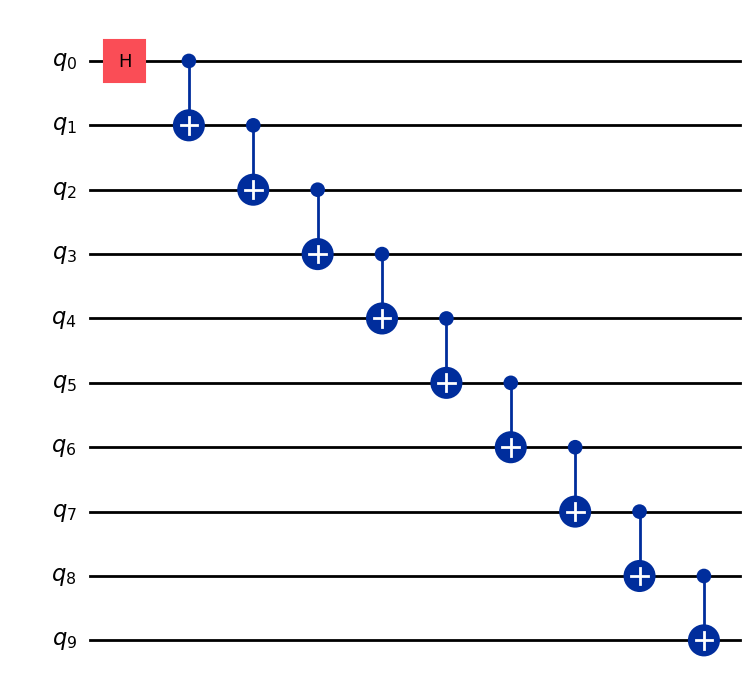

In [48]:
n_qubits = 10
ghz_circuit_new = QuantumCircuit(n_qubits)
ghz_circuit_new.h(0)  # Apply Hadamard on the first qubit
for qubit in range(n_qubits-1):
    ghz_circuit_new.cx(qubit, qubit + 1) 

ghz_circuit_new.draw(output='mpl')

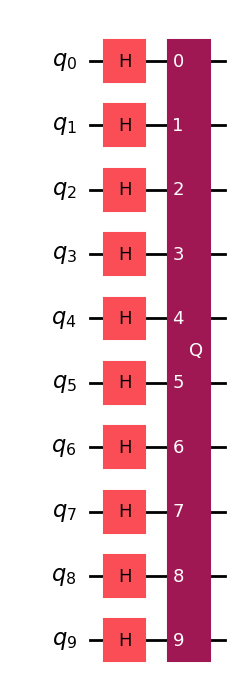

In [49]:
from qiskit.circuit.library import GroverOperator
oracle = QuantumCircuit(n_qubits)
oracle.cz(0, 1)  # Define an oracle for example purposes
grover = GroverOperator(oracle)

grover_circuit = QuantumCircuit(n_qubits)
grover_circuit.h(range(n_qubits))  # Apply Hadamard
grover_circuit.append(grover, range(n_qubits))
grover_circuit.draw(output='mpl')

In [50]:
n_qubits = 5
qft_circuit_s = qft_dagger(n_qubits)
qft_circuit_s.draw('mpl')
t_10 = CouplingMap([(14,15),(15,18),(18,27),(27,26)])

# combo_qft_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_qft_circuit.append(qft_circuit_s, combo_qft_circuit.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_qft_circuit.append(qft_circuit, combo_qft_circuit.qubits[5:])
# Transpile the circuit for the chosen backend
combo_qft_circuit = transpile(qft_circuit_s, backend=backend, seed_transpiler=42)
print(combo_qft_circuit)

global phase: 4.6633
           ┌─────────┐                     ┌──────┐                »
q_0 -> 35 ─┤ Rz(π/2) ├─────────────────────┤0     ├────────────────»
          ┌┴─────────┴┐                    │      │                »
q_2 -> 45 ┤ Rz(-5π/8) ├────────────────────┤      ├────────────────»
          └┬─────────┬┘┌────┐  ┌────────┐  │  Ecr │                »
q_3 -> 46 ─┤ Rz(π/2) ├─┤ √X ├──┤ Rz(-π) ├──┤      ├────────────────»
           ├─────────┴┐├────┤┌─┴────────┴─┐│      │┌────────┐┌────┐»
q_4 -> 47 ─┤ Rz(-π/2) ├┤ √X ├┤ Rz(2.2467) ├┤1     ├┤ Rz(-π) ├┤ √X ├»
           ├──────────┤└────┘└────────────┘└──────┘└────────┘└────┘»
q_1 -> 48 ─┤ Rz(-π/2) ├────────────────────────────────────────────»
           └──────────┘                                            »
«                              ┌──────┐┌─────────────┐                         »
«q_0 -> 35 ────────────────────┤0     ├┤ Rz(-1.8653) ├─────────────────────────»
«                              │      │└─────────────┘    

In [51]:
mod5_4 = QuantumCircuit(qreg_q)
t_coupling_map = CouplingMap([(11, 17), (10,11), (11, 12),(23,17)])

mod5_4.cx(qreg_q[0], qreg_q[2])
mod5_4.cx(qreg_q[1], qreg_q[3])
mod5_4.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
mod5_4.cx(qreg_q[2], qreg_q[3])
mod5_4.cx(qreg_q[3], qreg_q[4])
# combo_mod5_4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5_4.append(mod5_4, combo_mod5_4.qubits[2:7])

# # Add the second circuit to the next 10 qubits
# combo_mod5_4.append(grover_circuit, [combo_mod5_4.qubits[i] for i in [0,1,7,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_mod5_4 = transpile(mod5_4, backend=backend, seed_transpiler=42)

# Compile the original circuit
# compiled_mod5_4 = transpile(mod5_4, backend, seed_transpiler=42)


In [52]:
from qiskit.circuit.library import GroverOperator

n_qubits = 5
oracle = QuantumCircuit(n_qubits)
oracle.cz(0, 1)  # Define an oracle for example purposes
grover = GroverOperator(oracle)

grover_circuit_s = QuantumCircuit(n_qubits)
grover_circuit_s.h(range(n_qubits))  # Apply Hadamard
grover_circuit_s.append(grover, range(n_qubits))  # Apply Grover iteration

grover_circuit_s.draw('mpl')
grover_cm = CouplingMap([(8,7),(16,7),(19,16),(20,19)])

# combo_grover_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_grover_circuit.append(grover_circuit_s, combo_grover_circuit.qubits[3:8])

# # Add the second circuit to the next 10 qubits
# combo_grover_circuit.append(qft_circuit, [combo_grover_circuit.qubits[i] for i in [0,1,2,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_grover_circuit = transpile(grover_circuit_s, backend=backend, seed_transpiler=42)
# compiled_grover = transpile(grover, backend=backend, seed_transpiler=42)


In [53]:
n_qubits = 5
ghz_circuit = QuantumCircuit(n_qubits)
ghz_circuit.h(0)  # Apply Hadamard on the first qubit
for qubit in range(n_qubits-1):
    ghz_circuit.cx(qubit, qubit + 1)  # Create entanglement

# ghz_circuit.measure_all()

ghz_circuit.draw('mpl')

ghz_cm= CouplingMap([(17,23),(23,24),(24,25),(25,26)])

# combo_ghz_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_ghz_circuit.append(ghz_circuit, combo_ghz_circuit.qubits[4:9])

# # Add the second circuit to the next 10 qubits
# combo_ghz_circuit.append(ghz_circuit_new, [combo_ghz_circuit.qubits[i] for i in [0,1,2,3,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_ghz_circuit = transpile(ghz_circuit, backend=backend, seed_transpiler=42)
# compiled_ghz = transpile(ghz_circuit, backend=backend, seed_transpiler=42)


In [54]:
qreg_q = QuantumRegister(5, 'q')
one23 = QuantumCircuit(qreg_q)

one23.cx(qreg_q[3], qreg_q[1])
one23.cx(qreg_q[2], qreg_q[0])
one23.ccx(qreg_q[3], qreg_q[4], qreg_q[2])
one23.ccx(qreg_q[2], qreg_q[0], qreg_q[4])
one23.cx(qreg_q[4], qreg_q[3])
one23.ccx(qreg_q[1], qreg_q[3], qreg_q[4])
one23.cx(qreg_q[3], qreg_q[2])
one23.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
one23_cm= CouplingMap([(13,14),(14,15),(15,18),(18,27)])
# combo_one23 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_one23.append(one23, combo_one23.qubits[5:10])

# # Add the second circuit to the next 10 qubits
# combo_one23.append(grover_circuit, [combo_one23.qubits[i] for i in [0,1,2,3,4,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_one23 = transpile(one23, backend=backend, seed_transpiler=42)
# compiled_one23 = transpile(one23, backend=backend, seed_transpiler=42)


In [55]:
qreg_q = QuantumRegister(5, 'q')
fourgt4 = QuantumCircuit(qreg_q)
#backend = Aer.get_backend('qasm_simulator')
from qiskit.circuit.library import C3XGate, C4XGate

fourgt4.cx(qreg_q[4], qreg_q[1])
fourgt4.ccx(qreg_q[2], qreg_q[4], qreg_q[0])
fourgt4.x(qreg_q[0])

fourgt4.cx(qreg_q[1],qreg_q[2])
fourgt4.x(qreg_q[0])

fourgt4.append(C3XGate(), [qreg_q[0], qreg_q[2], qreg_q[3], qreg_q[4]])

fourgt4.x(qreg_q[0])
fourgt4.cx(qreg_q[1],qreg_q[2])

fourgt4.ccx(qreg_q[0], qreg_q[1], qreg_q[4])
fourgt4.append(C4XGate(), [qreg_q[1], qreg_q[0], qreg_q[2], qreg_q[3], qreg_q[4]])
fourgt4_cm= CouplingMap([(4,6),(6,13),(12,13),(14,13)])

# combo_4gt4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt4.append(fourgt4, combo_4gt4.qubits[6:11])

# # Add the second circuit to the next 10 qubits
# combo_4gt4.append(grover_circuit, [combo_4gt4.qubits[i] for i in [0,1,2,3,4,5,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4gt4 = transpile(fourgt4, backend=backend, seed_transpiler=42)
# compiled_4gt4=transpile(fourgt4, backend=backend, seed_transpiler=42)


In [56]:
qreg_q = QuantumRegister(5, 'q')
fourmod7 = QuantumCircuit(qreg_q)

fourmod7.x(qreg_q[0])
fourmod7.ccx(qreg_q[4], qreg_q[1], qreg_q[0])
fourmod7.cx(qreg_q[1], qreg_q[4])
fourmod7.cx(qreg_q[1], qreg_q[4])
fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[4], qreg_q[2], qreg_q[0]])
fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[0], qreg_q[2], qreg_q[4]])
fourmod7.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
fourmod7_cm= CouplingMap([(0,5),(5,9),(8,9),(9,10)])
# combo_4mod7 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4mod7.append(fourmod7, combo_4mod7.qubits[7:12])

# # Add the second circuit to the next 10 qubits
# combo_4mod7.append(ghz_circuit_new, [combo_4mod7.qubits[i] for i in [0,1,2,3,4,5,6,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4mod7 = transpile(fourmod7, backend=backend, seed_transpiler=42)
# compiled_4mod7=transpile(fourmod7, backend=backend, seed_transpiler=42)

In [57]:
fourgt11 = QuantumCircuit(qreg_q)

fourgt11.cx(qreg_q[2], qreg_q[1])
fourgt11.cx(qreg_q[1], qreg_q[2])
fourgt11.cx(qreg_q[3], qreg_q[2])
fourgt11.cx(qreg_q[2], qreg_q[3])
fourgt11.cx(qreg_q[4], qreg_q[3])
fourgt11.cx(qreg_q[3], qreg_q[4])
fourgt11.ccx(qreg_q[1], qreg_q[4], qreg_q[0])
fourgt11.cx(qreg_q[4], qreg_q[3])
fourgt11.cx(qreg_q[4], qreg_q[2])
fourgt11.cx(qreg_q[4], qreg_q[1])
fourgt11.cx(qreg_q[0], qreg_q[4])
fourgt11.cx(qreg_q[4], qreg_q[0])
# combo_4gt11 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt11.append(fourgt11, combo_4gt11.qubits[8:13])

# # Add the second circuit to the next 10 qubits
# combo_4gt11.append(grover_circuit, [combo_4gt11.qubits[i] for i in [0,1,2,3,4,5,6,7,13,14]])
# Transpile the circuit for the chosen backend
combo_4gt11 = transpile(fourgt11, backend=backend, seed_transpiler=42)
# compiled_4gt11=transpile(fourmod7, backend=backend,seed_transpiler=42)

In [58]:
mod5mils = QuantumCircuit(qreg_q)

mod5mils.x(qreg_q[3])
mod5mils.cx(qreg_q[1], qreg_q[3])
mod5mils.ccx(qreg_q[3], qreg_q[2], qreg_q[4])
mod5mils.ccx(qreg_q[3], qreg_q[0], qreg_q[4])
mod5mils.cx(qreg_q[3], qreg_q[4])
mod5mils_cm=CouplingMap([(21,22),(17,23),(23,22),(20,21)])
# combo_mod5mils = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5mils.append(mod5mils, combo_mod5mils.qubits[9:14])

# # Add the second circuit to the next 10 qubits
# combo_mod5mils.append(ghz_circuit_new, [combo_mod5mils.qubits[i] for i in [0,1,2,3,4,5,6,7,8,14]])
# Transpile the circuit for the chosen backend
combo_mod5mils = transpile(mod5mils, backend=backend, seed_transpiler=42)


In [59]:
fourgt12 = QuantumCircuit(qreg_q)

fourgt12.ccx(qreg_q[1], qreg_q[2], qreg_q[3])
fourgt12.ccx(qreg_q[2], qreg_q[1], qreg_q[0])
fourgt12.cx(qreg_q[4], qreg_q[0])
fourgt12.cx(qreg_q[0], qreg_q[4])
fourgt12.append(C4XGate(), [qreg_q[3], qreg_q[2], qreg_q[0], qreg_q[1], qreg_q[4]])
fourgt12_cm=CouplingMap([(15,18),(18,27),(27,26),(26,25)])
# combo_4gt12= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt12.append(fourgt12, combo_4gt12.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_4gt12.append(qft_circuit, combo_4gt12.qubits[5:])
# Transpile the circuit for the chosen backend
combo_4gt12= transpile(fourgt12, backend=backend, seed_transpiler=42)

In [60]:
fourgt13 = QuantumCircuit(qreg_q)

fourgt13.cx(qreg_q[4], qreg_q[0])
fourgt13.append(C3XGate(), [qreg_q[3], qreg_q[2], qreg_q[1], qreg_q[0]])
fourgt13.cx(qreg_q[0], qreg_q[4])
fourgt13.draw(output='mpl')
fourgt13_cm=CouplingMap([(0,5),(5,9),(9,10),(10,11)])

combo_4gt13= transpile(fourgt13, backend=backend, seed_transpiler=42)

In [61]:
from qiskit.circuit.random import random_circuit

# Generate a random 10-qubit quantum circuit with 20 layers of gates
random_circ = random_circuit(num_qubits=5, depth=3, max_operands=2)
# combo_rc_s= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s.append(ghz_circuit_new, combo_rc_s.qubits[1:11])

# # Add the second circuit to the next 10 qubits
# combo_rc_s.append(random_circ, [combo_rc_s.qubits[i] for i in [0,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_rc_s= transpile(random_circ, backend=backend, seed_transpiler=42)
# combo_rc_s_2= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s_2.append(qft_circuit, combo_rc_s_2.qubits[2:12])

# # Add the second circuit to the next 10 qubits
# combo_rc_s_2.append(random_circ, [combo_rc_s_2.qubits[i] for i in [0,1,12,13,14]])

# combo_rc_s_2= transpile(combo_rc_s_2, backend=backend, seed_transpiler=40)

# combo_rc_s_3= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s_3.append(grover_circuit, combo_rc_s_3.qubits[3:13])

# # Add the second circuit to the next 10 qubits
# combo_rc_s_3.append(random_circ, [combo_rc_s_3.qubits[i] for i in [0,1,2,13,14]])
# combo_rc_s_3= transpile(combo_rc_s_3, backend=backend, seed_transpiler=47)

# combo_rc_s_4= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s_4.append(grover_circuit, combo_rc_s_4.qubits[3:13])

# # Add the second circuit to the next 10 qubits
# combo_rc_s_4.append(random_circ, [combo_rc_s_4.qubits[i] for i in [0,1,2,13,14]])
# combo_rc_s_4= transpile(combo_rc_s_4, backend=backend, seed_transpiler=48)

# combo_rc_s_5= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s_5.append(ghz_circuit_new, combo_rc_s_5.qubits[3:13])

# # Add the second circuit to the next 10 qubits
# combo_rc_s_5.append(random_circ, [combo_rc_s_5.qubits[i] for i in [0,1,2,13,14]])
# combo_rc_s_5= transpile(combo_rc_s_5, backend=backend, seed_transpiler=49)

# combo_rc_s_6= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_rc_s_6.append(grover_circuit, combo_rc_s_6.qubits[3:13])

# # Add the second circuit to the next 10 qubits
# combo_rc_s_6.append(random_circ, [combo_rc_s_6.qubits[i] for i in [0,1,2,13,14]])
# combo_rc_s_6= transpile(combo_rc_s_6, backend=backend, seed_transpiler=47)

In [3]:
from collections import Counter
import numpy as np
from qiskit.circuit.library import SwapGate, CXGate, RZZGate, RXXGate, RYYGate, iSwapGate
from qiskit.quantum_info import Operator
def is_swap_gate(instruction_tuple):
    """Check if the given instruction represents a SWAP gate or equivalent sequence."""
    instruction = instruction_tuple[0]  # Unpack the instruction from the tuple

    # Direct SWAP gate
    if isinstance(instruction, SwapGate):
        return True
    
    # Named SWAP gate
    if instruction.name.lower() == 'swap':
        return True
    
    # Check for equivalent operations using matrix comparison
    if instruction.num_qubits == 2:
        swap_op = Operator(SwapGate())
        instr_op = Operator(instruction)
        if np.allclose(instr_op.data, swap_op.data, atol=1e-10):
            return True
    
    # Check for common SWAP implementations
    if isinstance(instruction, CXGate):
        # CNOT-based SWAP (3 CNOTs)
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                cx1, cx2, cx3 = data[0][0], data[1][0], data[2][0]
                if (isinstance(cx1, CXGate) and isinstance(cx2, CXGate) and isinstance(cx3, CXGate) and
                    cx1.qargs[0] == cx2.qargs[1] and cx1.qargs[1] == cx3.qargs[1] and
                    cx2.qargs[0] == cx3.qargs[0]):
                    return True
    
    # iSWAP-based SWAP
    if isinstance(instruction, iSwapGate):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 2:
                iswap, s = data[0][0], data[1][0]
                if isinstance(iswap, iSwapGate) and s.name == 's' and s.qargs == iswap.qargs:
                    return True
    
    # RZZ, RXX, RYY-based SWAP
    if isinstance(instruction, (RZZGate, RXXGate, RYYGate)):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                rzz, rxx, ryy = data[0][0], data[1][0], data[2][0]
                if (isinstance(rzz, RZZGate) and isinstance(rxx, RXXGate) and isinstance(ryy, RYYGate) and
                    rzz.params[0] == rxx.params[0] == ryy.params[0] == np.pi/2 and
                    rzz.qargs == rxx.qargs == ryy.qargs):
                    return True
    
    return False

from qiskit import QuantumCircuit
from qiskit.circuit.library.standard_gates import SwapGate
# Updated function to derive coupling map
# Updated function to derive coupling map
# Updated function to derive coupling map
def derive_coupling_map_from_circuit(transpiled_circuit):
    derived_coupling_map = set()  # Use a set to avoid duplicate entries

    # Initialize the swap history for each qubit in the circuit
    qubit_swap_history = {qubit: False for qubit in transpiled_circuit.qubits}

    for instruction in transpiled_circuit.data:
        if instruction[0].name == 'swap':
            # If the instruction is a SWAP gate, mark the qubits as involved in a swap
            for qarg in instruction[1]:
                qubit_swap_history[qarg] = True
            continue  # Move to the next instruction

        if len(instruction[1]) == 2:
            # Directly use the qubit objects
            qubits = [qarg for qarg in instruction[1]]

            # Check if any of the qubits were involved in a SWAP
            if not any(qubit_swap_history[qubit] for qubit in qubits):
                # If neither qubit has been swapped, add the connection
                qubit_indices = [transpiled_circuit.find_bit(qarg).index for qarg in qubits]
                derived_coupling_map.add(tuple(sorted(qubit_indices)))

    return derived_coupling_map

# Use the updated function to derive the coupling map
import matplotlib.pyplot as plt
import networkx as nx

def plot_coupling_map(coupling_map):
    # Create a graph from the coupling map
    G = nx.Graph()
    G.add_edges_from(coupling_map)
    
    # Draw the graph using networkx
    pos = nx.spring_layout(G)  # Position nodes using a layout algorithm
    nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=15, font_weight='bold')
    plt.title("Derived Coupling Map")
    plt.show()

# Assuming derived_map is the derived coupling map from your code

# Plot the derived coupling map


{(121, 122), (122, 123), (120, 121), (123, 124)}


C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\1553622732.py:78: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]


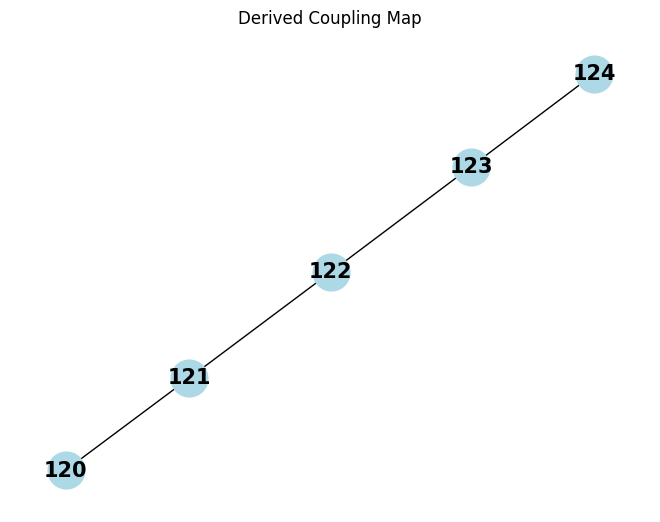

0.10523819923400879
{(121, 122), (111, 122), (120, 121), (104, 111)}


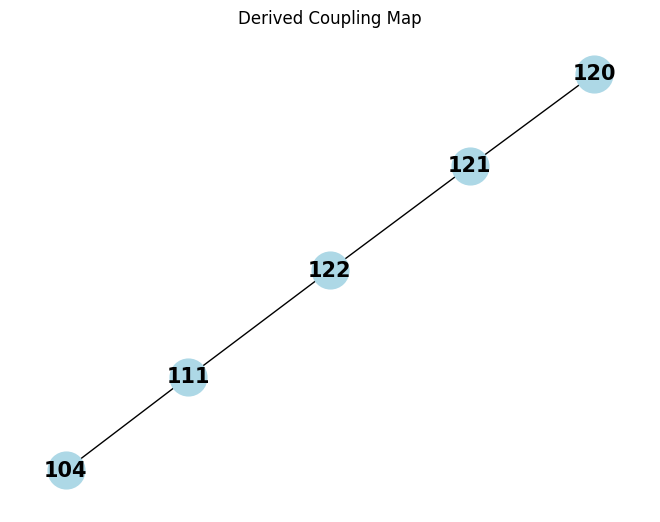

0.09475517272949219
{(35, 47), (46, 47), (45, 46), (47, 48)}


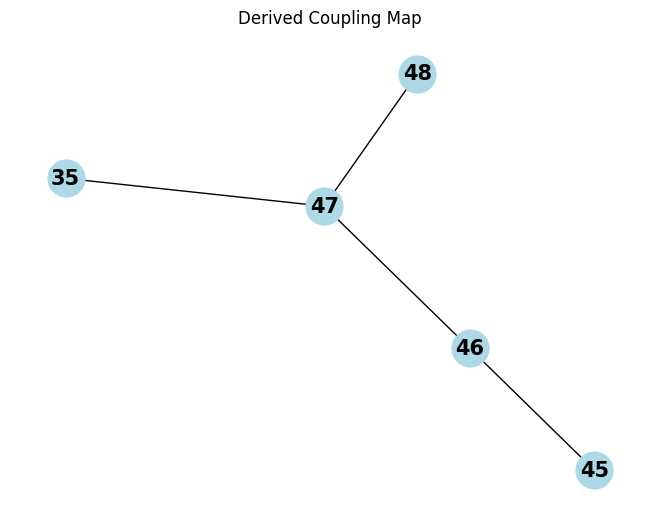

{(35, 47), (46, 47), (47, 48), (48, 49)}


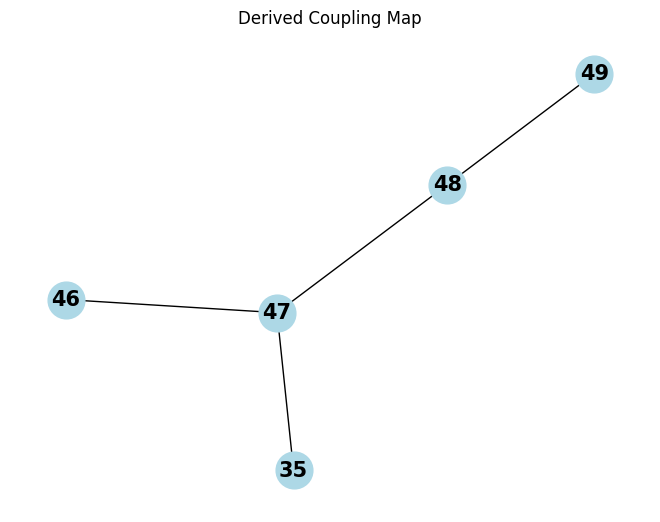

{(121, 122), (111, 122), (122, 123), (104, 111)}


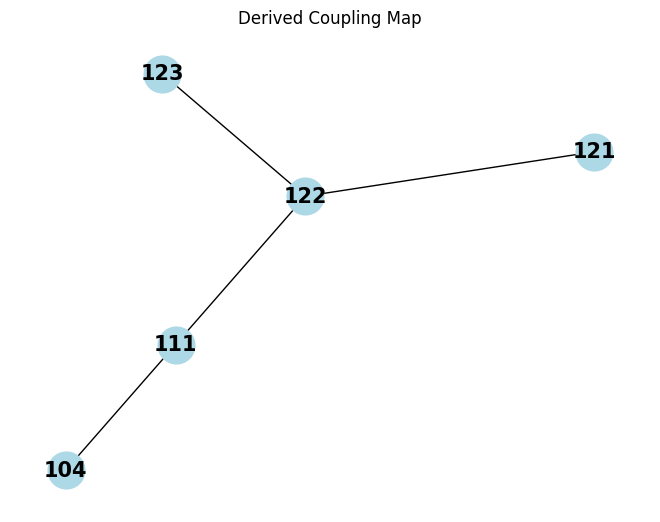

{(41, 53), (60, 61), (61, 62), (53, 60)}


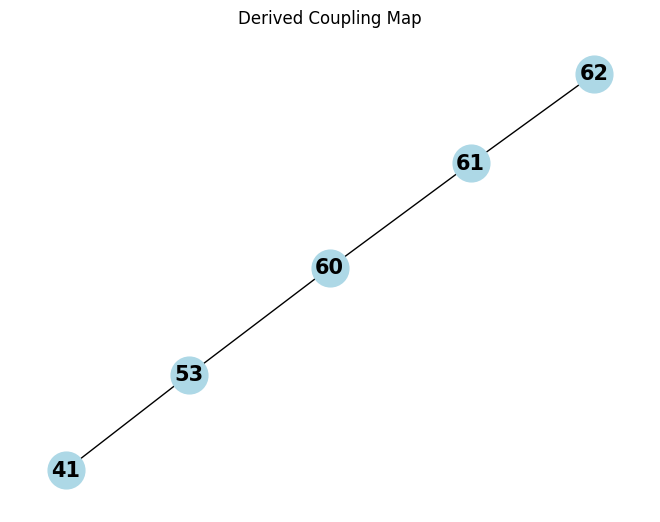

{(35, 47), (48, 49), (46, 47), (47, 48)}


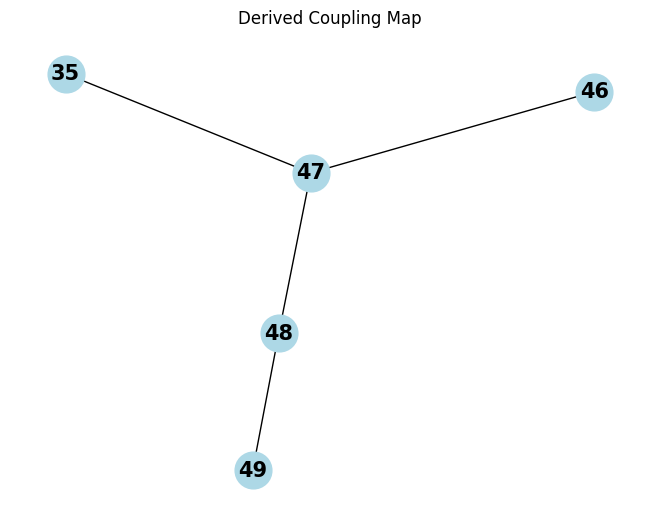

{(35, 47), (48, 49), (46, 47), (47, 48)}


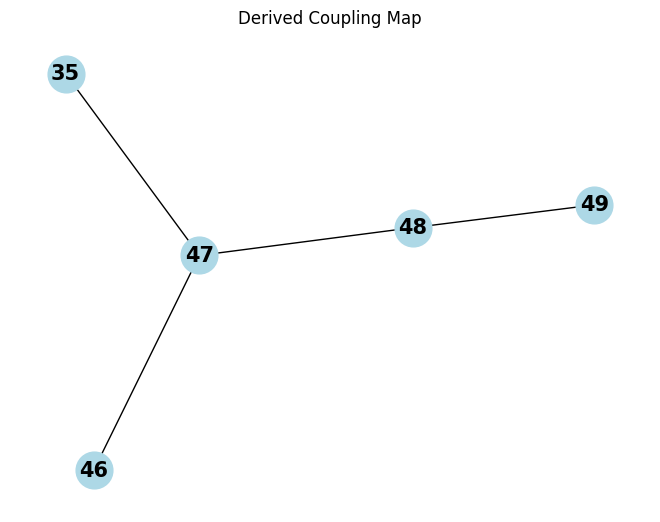

{(35, 47), (46, 47), (47, 48), (48, 49)}


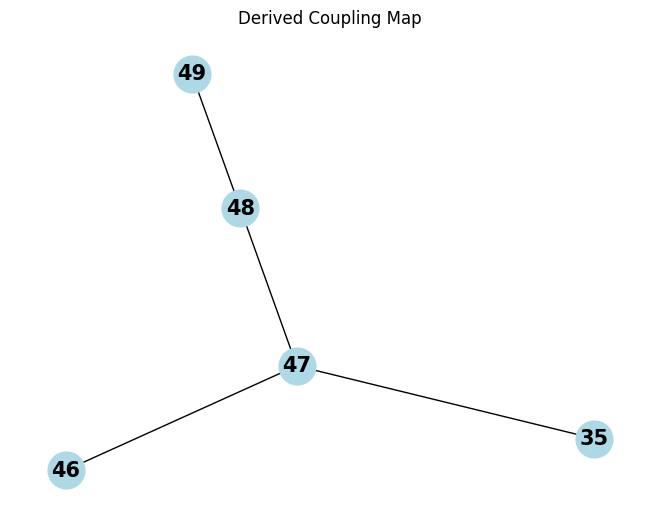

{(121, 122), (122, 123), (120, 121), (111, 122)}


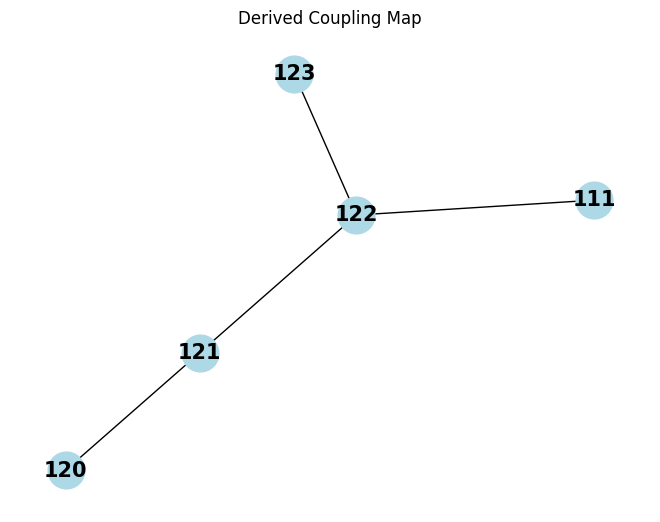

{(35, 47), (46, 47), (47, 48), (48, 49)}


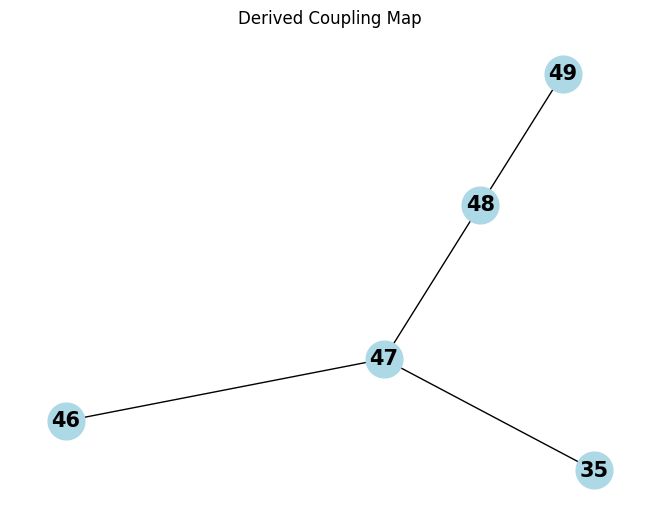

{(99, 100), (110, 118), (100, 110), (100, 101)}


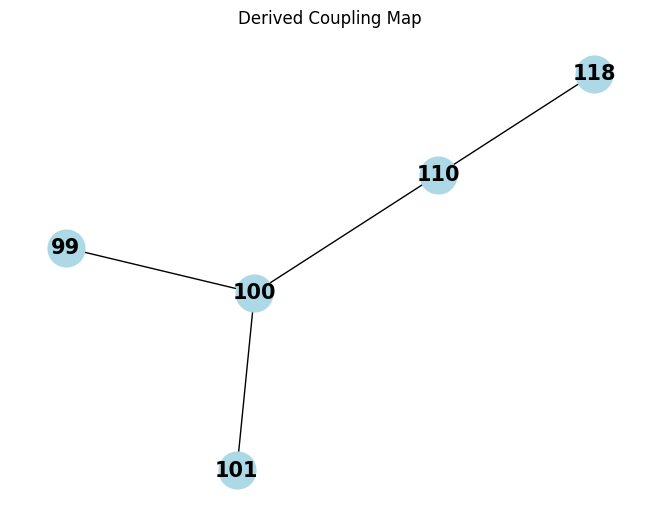

{(46, 47), (47, 48)}


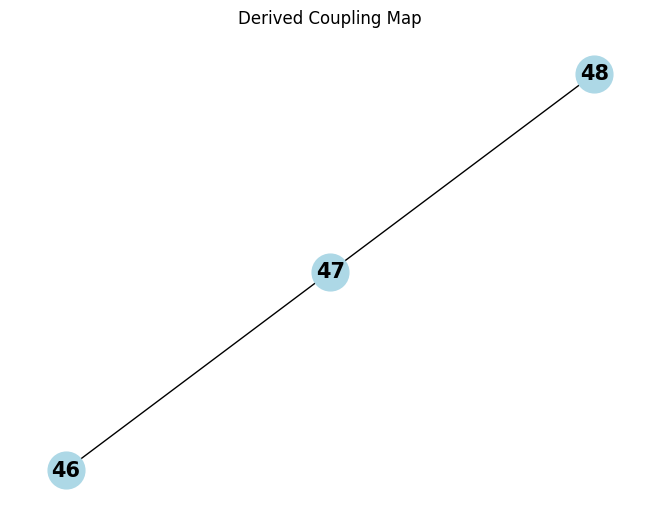

In [63]:
start_time = time.time()
derived_map_mod5= derive_coupling_map_from_circuit(combo_mod5_4)
print(derived_map_mod5)
plot_coupling_map(derived_map_mod5)
end_time = time.time()
execution_time = end_time- start_time
print(execution_time)

start_time = time.time()
derived_map_1bit_adder = derive_coupling_map_from_circuit(compiled_cal_qc_combo)
print(derived_map_1bit_adder)
plot_coupling_map(derived_map_1bit_adder)
end_time = time.time()
execution_time = end_time- start_time
print(execution_time)

derived_map_qft = derive_coupling_map_from_circuit(combo_qft_circuit)
print(derived_map_qft)
plot_coupling_map(derived_map_qft)

derived_map_grover = derive_coupling_map_from_circuit(combo_grover_circuit)
print(derived_map_grover)
plot_coupling_map(derived_map_grover)

derived_map_one23 = derive_coupling_map_from_circuit(combo_one23)
print(derived_map_one23)
plot_coupling_map(derived_map_one23)

derived_map_ghz = derive_coupling_map_from_circuit(combo_ghz_circuit)
print(derived_map_ghz)
plot_coupling_map(derived_map_ghz)

derived_map_4gt4 = derive_coupling_map_from_circuit(combo_4gt4)
print(derived_map_4gt4)
plot_coupling_map(derived_map_4gt4)

derived_map_4mod7 = derive_coupling_map_from_circuit(combo_4mod7)
print(derived_map_4mod7)
plot_coupling_map(derived_map_4mod7)

derived_map_4gt11 = derive_coupling_map_from_circuit(combo_4gt11)
print(derived_map_4gt11)
plot_coupling_map(derived_map_4gt11)

derived_map_4gt12 = derive_coupling_map_from_circuit(combo_4gt12)
print(derived_map_4gt12)
plot_coupling_map(derived_map_4gt12)

derived_map_4gt13 = derive_coupling_map_from_circuit(combo_4gt13)
print(derived_map_4gt13)
plot_coupling_map(derived_map_4gt13)

derived_map_mod5mils = derive_coupling_map_from_circuit(combo_mod5mils)
print(derived_map_mod5mils)
plot_coupling_map(derived_map_mod5mils)

derived_map_rc = derive_coupling_map_from_circuit(combo_rc_s)
print(derived_map_rc)
plot_coupling_map(derived_map_rc)


In [7]:
# Import necessary modules
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.circuit.library import CXGate
# from qiskit_ibm_provider import IBMProvider
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import CouplingMap
from qiskit.circuit.library import C4XGate
# from qiskit_ibm_runtime.fake_provider import FakeCambridge

import time
import os
 
service = QiskitRuntimeService(channel="ibm_quantum", token="71312790a9405e5c50790a7928a71fa4afb8271d5b1c54a1fc092fc3e9afe355ad29bd206edd926f3cc6f57bd59f7bc486c8fb372a3f5e3457b22d43f45ce1c0")
# Set the API key as an environment variable

# Initialize the Qiskit Runtime Service

# Specify the backend
backend_name = 'ibm_sherbrooke'
backend = service.backend(backend_name)
sim_name = 'qasm_simulator'
sim = service.backend(sim_name)
qreg_q = QuantumRegister(4, 'q')
cal_qc = QuantumCircuit(qreg_q)
from qiskit import QuantumCircuit
import numpy as np


# compiled_qft = transpile(qft_circuit, backend, seed_transpiler=42)


def qft_dagger(n):
    """Creates the inverse QFT on n qubits."""
    qc = QuantumCircuit(n)
    # Apply Hadamard gate to each qubit
    for qubit in range(n-1, -1, -1):
        qc.h(qubit)
        for j in range(qubit):
            qc.cp(-np.pi/2**(qubit-j), j, qubit)
    return qc
# linear_coupling_map = CouplingMap([(0, 1), (1, 2), (2, 3), (3, 4)])

# compiled_qft_new = transpile(qft_circuit, backend, seed_transpiler=42)
# Adding CX gates to the circuit
# cal_qc.cx(qreg_q[1], qreg_q[2])
# cal_qc.cx(qreg_q[1], qreg_q[4])
# cal_qc.cx(qreg_q[2], qreg_q[3])
# cal_qc.cx(qreg_q[5], qreg_q[4])
# cal_qc.cx(qreg_q[5], qreg_q[0])
# cal_qc.cx(qreg_q[6], qreg_q[0])
cal_qc.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
# cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[3])
cal_qc.ccx(qreg_q[0], qreg_q[1], qreg_q[3])
cal_qc.x(qreg_q[1])
cal_qc.x(qreg_q[2])
# cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.x(qreg_q[0])
# cal_qc.cx(qreg_q[0], qreg_q[4])

# combo_cal_qc = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_cal_qc.append(cal_qc, combo_cal_qc.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_cal_qc.append(qft_circuit, combo_cal_qc.qubits[5:])
# Transpile the circuit for the chosen backend
compiled_cal_qc_combo = transpile(cal_qc, backend=backend, seed_transpiler=42)
n_qubits = 4
qft_circuit_s = qft_dagger(n_qubits)
qft_circuit_s.draw('mpl')

# combo_qft_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_qft_circuit.append(qft_circuit_s, combo_qft_circuit.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_qft_circuit.append(qft_circuit, combo_qft_circuit.qubits[5:])
# Transpile the circuit for the chosen backend
combo_qft_circuit = transpile(qft_circuit_s, backend=backend, seed_transpiler=42)
print(combo_qft_circuit)

mod5_4 = QuantumCircuit(qreg_q)

mod5_4.cx(qreg_q[0], qreg_q[2])
mod5_4.cx(qreg_q[1], qreg_q[3])
# mod5_4.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
mod5_4.cx(qreg_q[2], qreg_q[3])
# mod5_4.cx(qreg_q[3], qreg_q[4])
# combo_mod5_4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5_4.append(mod5_4, combo_mod5_4.qubits[2:7])

# # Add the second circuit to the next 10 qubits
# combo_mod5_4.append(grover_circuit, [combo_mod5_4.qubits[i] for i in [0,1,7,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_mod5_4 = transpile(mod5_4, backend=backend, seed_transpiler=42)

from qiskit.circuit.library import GroverOperator

n_qubits = 4
oracle = QuantumCircuit(n_qubits)
oracle.cz(0, 1)  # Define an oracle for example purposes
grover = GroverOperator(oracle)

grover_circuit_s = QuantumCircuit(n_qubits)
grover_circuit_s.h(range(n_qubits))  # Apply Hadamard
grover_circuit_s.append(grover, range(n_qubits))  # Apply Grover iteration

grover_circuit_s.draw('mpl')
grover_cm = CouplingMap([(8,7),(16,7),(19,16),(20,19)])

# combo_grover_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_grover_circuit.append(grover_circuit_s, combo_grover_circuit.qubits[3:8])

# # Add the second circuit to the next 10 qubits
# combo_grover_circuit.append(qft_circuit, [combo_grover_circuit.qubits[i] for i in [0,1,2,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_grover_circuit = transpile(grover_circuit_s, backend=backend, seed_transpiler=42)
n_qubits = 4
ghz_circuit = QuantumCircuit(n_qubits)
ghz_circuit.h(0)  # Apply Hadamard on the first qubit
for qubit in range(n_qubits-1):
    ghz_circuit.cx(qubit, qubit + 1)  # Create entanglement

# ghz_circuit.measure_all()

ghz_circuit.draw('mpl')

ghz_cm= CouplingMap([(17,23),(23,24),(24,25),(25,26)])

# combo_ghz_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_ghz_circuit.append(ghz_circuit, combo_ghz_circuit.qubits[4:9])

# # Add the second circuit to the next 10 qubits
# combo_ghz_circuit.append(ghz_circuit_new, [combo_ghz_circuit.qubits[i] for i in [0,1,2,3,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_ghz_circuit = transpile(ghz_circuit, backend=backend, seed_transpiler=42)
# compiled_ghz = transpile(ghz_circuit, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(4, 'q')
one23 = QuantumCircuit(qreg_q)

one23.cx(qreg_q[3], qreg_q[1])
one23.cx(qreg_q[2], qreg_q[0])
# one23.ccx(qreg_q[3], qreg_q[4], qreg_q[2])
# one23.ccx(qreg_q[2], qreg_q[0], qreg_q[4])
# one23.cx(qreg_q[4], qreg_q[3])
# one23.ccx(qreg_q[1], qreg_q[3], qreg_q[4])
one23.cx(qreg_q[3], qreg_q[2])
one23.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
one23_cm= CouplingMap([(13,14),(14,15),(15,18),(18,27)])
# combo_one23 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_one23.append(one23, combo_one23.qubits[5:10])

# # Add the second circuit to the next 10 qubits
# combo_one23.append(grover_circuit, [combo_one23.qubits[i] for i in [0,1,2,3,4,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_one23 = transpile(one23, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(4, 'q')
fourgt4 = QuantumCircuit(qreg_q)
#backend = Aer.get_backend('qasm_simulator')
from qiskit.circuit.library import C3XGate, C4XGate

# fourgt4.cx(qreg_q[4], qreg_q[1])
fourgt4.ccx(qreg_q[2], qreg_q[3], qreg_q[0])
fourgt4.x(qreg_q[0])
fourgt4.cx(qreg_q[1],qreg_q[2])


# fourgt4.ccx(qreg_q[0], qreg_q[1], qreg_q[4])
# fourgt4.append(C4XGate(), [qreg_q[1], qreg_q[0], qreg_q[2], qreg_q[3], qreg_q[4]])
fourgt4_cm= CouplingMap([(4,6),(6,13),(12,13),(14,13)])

# combo_4gt4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt4.append(fourgt4, combo_4gt4.qubits[6:11])

# # Add the second circuit to the next 10 qubits
# combo_4gt4.append(grover_circuit, [combo_4gt4.qubits[i] for i in [0,1,2,3,4,5,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4gt4 = transpile(fourgt4, backend=backend, seed_transpiler=42)
# compiled_4gt4=transpile(fourgt4, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(4, 'q')
fourmod7 = QuantumCircuit(qreg_q)

fourmod7.x(qreg_q[0])
fourmod7.ccx(qreg_q[3], qreg_q[1], qreg_q[0])
# fourmod7.cx(qreg_q[1], qreg_q[4])
# fourmod7.cx(qreg_q[1], qreg_q[4])
# fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[4], qreg_q[2], qreg_q[0]])
# fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[0], qreg_q[2], qreg_q[4]])
fourmod7.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
fourmod7_cm= CouplingMap([(0,5),(5,9),(8,9),(9,10)])
# combo_4mod7 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4mod7.append(fourmod7, combo_4mod7.qubits[7:12])

# # Add the second circuit to the next 10 qubits
# combo_4mod7.append(ghz_circuit_new, [combo_4mod7.qubits[i] for i in [0,1,2,3,4,5,6,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4mod7 = transpile(fourmod7, backend=backend, seed_transpiler=42)
fourgt11 = QuantumCircuit(qreg_q)

fourgt11.cx(qreg_q[2], qreg_q[0])
fourgt11.cx(qreg_q[1], qreg_q[2])
fourgt11.cx(qreg_q[3], qreg_q[2])
fourgt11.cx(qreg_q[2], qreg_q[3])
# fourgt11.cx(qreg_q[4], qreg_q[3])
# fourgt11.cx(qreg_q[3], qreg_q[4])
# fourgt11.ccx(qreg_q[1], qreg_q[4], qreg_q[0])
# fourgt11.cx(qreg_q[4], qreg_q[3])
# fourgt11.cx(qreg_q[4], qreg_q[2])
# fourgt11.cx(qreg_q[4], qreg_q[1])
# fourgt11.cx(qreg_q[0], qreg_q[4])
# fourgt11.cx(qreg_q[4], qreg_q[0])
# combo_4gt11 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt11.append(fourgt11, combo_4gt11.qubits[8:13])

# # Add the second circuit to the next 10 qubits
# combo_4gt11.append(grover_circuit, [combo_4gt11.qubits[i] for i in [0,1,2,3,4,5,6,7,13,14]])
# Transpile the circuit for the chosen backend
combo_4gt11 = transpile(fourgt11, backend=backend, seed_transpiler=42)
mod5mils = QuantumCircuit(qreg_q)

# mod5mils.x(qreg_q[0])
mod5mils.cx(qreg_q[1], qreg_q[2])
mod5mils.ccx(qreg_q[3], qreg_q[0], qreg_q[1])
# mod5mils.ccx(qreg_q[3], qreg_q[0], qreg_q[4])
mod5mils.cx(qreg_q[2], qreg_q[3])
mod5mils_cm=CouplingMap([(21,22),(17,23),(23,22),(20,21)])
# combo_mod5mils = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5mils.append(mod5mils, combo_mod5mils.qubits[9:14])

# # Add the second circuit to the next 10 qubits
# combo_mod5mils.append(ghz_circuit_new, [combo_mod5mils.qubits[i] for i in [0,1,2,3,4,5,6,7,8,14]])
# Transpile the circuit for the chosen backend
combo_mod5mils = transpile(mod5mils, backend=backend, seed_transpiler=42)
fourgt12 = QuantumCircuit(qreg_q)

fourgt12.ccx(qreg_q[1], qreg_q[2], qreg_q[3])
fourgt12.ccx(qreg_q[2], qreg_q[1], qreg_q[0])
# fourgt12.cx(qreg_q[4], qreg_q[0])
# fourgt12.cx(qreg_q[0], qreg_q[4])
# fourgt12.append(C4XGate(), [qreg_q[3], qreg_q[2], qreg_q[0], qreg_q[1], qreg_q[4]])
fourgt12_cm=CouplingMap([(15,18),(18,27),(27,26),(26,25)])
# combo_4gt12= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt12.append(fourgt12, combo_4gt12.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_4gt12.append(qft_circuit, combo_4gt12.qubits[5:])
# Transpile the circuit for the chosen backend
combo_4gt12= transpile(fourgt12, backend=backend, seed_transpiler=42)
fourgt13 = QuantumCircuit(qreg_q)

# fourgt13.cx(qreg_q[4], qreg_q[0])
fourgt13.append(C3XGate(), [qreg_q[3], qreg_q[2], qreg_q[1], qreg_q[0]])
fourgt13.cx(qreg_q[0], qreg_q[3])
fourgt13.draw(output='mpl')
fourgt13_cm=CouplingMap([(0,5),(5,9),(9,10),(10,11)])

combo_4gt13= transpile(fourgt13, backend=backend, seed_transpiler=42)

from collections import Counter
import numpy as np
from qiskit.circuit.library import SwapGate, CXGate, RZZGate, RXXGate, RYYGate, iSwapGate
from qiskit.quantum_info import Operator
def is_swap_gate(instruction_tuple):
    """Check if the given instruction represents a SWAP gate or equivalent sequence."""
    instruction = instruction_tuple[0]  # Unpack the instruction from the tuple

    # Direct SWAP gate
    if isinstance(instruction, SwapGate):
        return True
    
    # Named SWAP gate
    if instruction.name.lower() == 'swap':
        return True
    
    # Check for equivalent operations using matrix comparison
    if instruction.num_qubits == 2:
        swap_op = Operator(SwapGate())
        instr_op = Operator(instruction)
        if np.allclose(instr_op.data, swap_op.data, atol=1e-10):
            return True
    
    # Check for common SWAP implementations
    if isinstance(instruction, CXGate):
        # CNOT-based SWAP (3 CNOTs)
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                cx1, cx2, cx3 = data[0][0], data[1][0], data[2][0]
                if (isinstance(cx1, CXGate) and isinstance(cx2, CXGate) and isinstance(cx3, CXGate) and
                    cx1.qargs[0] == cx2.qargs[1] and cx1.qargs[1] == cx3.qargs[1] and
                    cx2.qargs[0] == cx3.qargs[0]):
                    return True
    
    # iSWAP-based SWAP
    if isinstance(instruction, iSwapGate):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 2:
                iswap, s = data[0][0], data[1][0]
                if isinstance(iswap, iSwapGate) and s.name == 's' and s.qargs == iswap.qargs:
                    return True
    
    # RZZ, RXX, RYY-based SWAP
    if isinstance(instruction, (RZZGate, RXXGate, RYYGate)):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                rzz, rxx, ryy = data[0][0], data[1][0], data[2][0]
                if (isinstance(rzz, RZZGate) and isinstance(rxx, RXXGate) and isinstance(ryy, RYYGate) and
                    rzz.params[0] == rxx.params[0] == ryy.params[0] == np.pi/2 and
                    rzz.qargs == rxx.qargs == ryy.qargs):
                    return True
    
    return False

from qiskit import QuantumCircuit
from qiskit.circuit.library.standard_gates import SwapGate
# Updated function to derive coupling map
# Updated function to derive coupling map
# Updated function to derive coupling map
def derive_coupling_map_from_circuit(transpiled_circuit):
    derived_coupling_map = set()  # Use a set to avoid duplicate entries

    # Initialize the swap history for each qubit in the circuit
    qubit_swap_history = {qubit: False for qubit in transpiled_circuit.qubits}

    for instruction in transpiled_circuit.data:
        if instruction[0].name == 'swap':
            # If the instruction is a SWAP gate, mark the qubits as involved in a swap
            for qarg in instruction[1]:
                qubit_swap_history[qarg] = True
            continue  # Move to the next instruction

        if len(instruction[1]) == 2:
            # Directly use the qubit objects
            qubits = [qarg for qarg in instruction[1]]

            # Check if any of the qubits were involved in a SWAP
            if not any(qubit_swap_history[qubit] for qubit in qubits):
                # If neither qubit has been swapped, add the connection
                qubit_indices = [transpiled_circuit.find_bit(qarg).index for qarg in qubits]
                derived_coupling_map.add(tuple(sorted(qubit_indices)))

    return derived_coupling_map

# Use the updated function to derive the coupling map
import matplotlib.pyplot as plt
import networkx as nx

def plot_coupling_map(coupling_map):
    # Create a graph from the coupling map
    G = nx.Graph()
    G.add_edges_from(coupling_map)
    
    # Draw the graph using networkx
    pos = nx.spring_layout(G)  # Position nodes using a layout algorithm
    nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=15, font_weight='bold')
    plt.title("Derived Coupling Map")
    plt.show()


derived_map_mod5= derive_coupling_map_from_circuit(combo_mod5_4)
print(derived_map_mod5)
plot_coupling_map(derived_map_mod5)


derived_map_1bit_adder = derive_coupling_map_from_circuit(compiled_cal_qc_combo)
print(derived_map_1bit_adder)
plot_coupling_map(derived_map_1bit_adder)


derived_map_qft = derive_coupling_map_from_circuit(combo_qft_circuit)
print(derived_map_qft)
plot_coupling_map(derived_map_qft)

derived_map_grover = derive_coupling_map_from_circuit(combo_grover_circuit)
print(derived_map_grover)
plot_coupling_map(derived_map_grover)

derived_map_one23 = derive_coupling_map_from_circuit(combo_one23)
print(derived_map_one23)
plot_coupling_map(derived_map_one23)

derived_map_ghz = derive_coupling_map_from_circuit(combo_ghz_circuit)
print(derived_map_ghz)
plot_coupling_map(derived_map_ghz)

derived_map_4gt4 = derive_coupling_map_from_circuit(combo_4gt4)
print(derived_map_4gt4)
plot_coupling_map(derived_map_4gt4)

derived_map_4mod7 = derive_coupling_map_from_circuit(combo_4mod7)
print(derived_map_4mod7)
plot_coupling_map(derived_map_4mod7)

derived_map_4gt11 = derive_coupling_map_from_circuit(combo_4gt11)
print(derived_map_4gt11)
plot_coupling_map(derived_map_4gt11)

derived_map_4gt12 = derive_coupling_map_from_circuit(combo_4gt12)
print(derived_map_4gt12)
plot_coupling_map(derived_map_4gt12)

derived_map_4gt13 = derive_coupling_map_from_circuit(combo_4gt13)
print(derived_map_4gt13)
plot_coupling_map(derived_map_4gt13)

derived_map_mod5mils = derive_coupling_map_from_circuit(combo_mod5mils)
print(derived_map_mod5mils)
plot_coupling_map(derived_map_mod5mils)




C:\Users\rupsh\AppData\Local\Temp\ipykernel_16584\3563639175.py:13: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(channel="ibm_quantum", token="71312790a9405e5c50790a7928a71fa4afb8271d5b1c54a1fc092fc3e9afe355ad29bd206edd926f3cc6f57bd59f7bc486c8fb372a3f5e3457b22d43f45ce1c0")


IBMNotAuthorizedError: '401 Client Error: Unauthorized for url: https://auth.quantum.ibm.com/api/users/loginWithToken. This version of platform has been sunset. Create an account or sign in to the upgraded IBM Quantum Platform at https://quantum.cloud.ibm.com, Error code: 3447.'

In [3]:
# Import necessary modules
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.circuit.library import CXGate
from qiskit_ibm_provider import IBMProvider
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import CouplingMap
from qiskit.circuit.library import C4XGate
from qiskit_ibm_runtime.fake_provider import FakeCambridge

import time
import os
 
service = QiskitRuntimeService(channel="ibm_quantum", token="71312790a9405e5c50790a7928a71fa4afb8271d5b1c54a1fc092fc3e9afe355ad29bd206edd926f3cc6f57bd59f7bc486c8fb372a3f5e3457b22d43f45ce1c0")
# Set the API key as an environment variable

# Initialize the Qiskit Runtime Service

# Specify the backend
backend_name = 'ibm_kyiv'
backend = service.get_backend(backend_name)
qreg_q = QuantumRegister(4, 'q')
cal_qc = QuantumCircuit(qreg_q)
from qiskit import QuantumCircuit
import numpy as np


# compiled_qft = transpile(qft_circuit, backend, seed_transpiler=42)


def qft_dagger(n):
    """Creates the inverse QFT on n qubits."""
    qc = QuantumCircuit(n)
    # Apply Hadamard gate to each qubit
    for qubit in range(n-1, -1, -1):
        qc.h(qubit)
        for j in range(qubit):
            qc.cp(-np.pi/2**(qubit-j), j, qubit)
    return qc
# linear_coupling_map = CouplingMap([(0, 1), (1, 2), (2, 3), (3, 4)])

# compiled_qft_new = transpile(qft_circuit, backend, seed_transpiler=42)
# Adding CX gates to the circuit
# cal_qc.cx(qreg_q[1], qreg_q[2])
# cal_qc.cx(qreg_q[1], qreg_q[4])
# cal_qc.cx(qreg_q[2], qreg_q[3])
# cal_qc.cx(qreg_q[5], qreg_q[4])
# cal_qc.cx(qreg_q[5], qreg_q[0])
# cal_qc.cx(qreg_q[6], qreg_q[0])
cal_qc.cx(qreg_q[0], qreg_q[2])
# cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.cx(qreg_q[1], qreg_q[2])
cal_qc.cx(qreg_q[0], qreg_q[1])
cal_qc.x(qreg_q[1])
cal_qc.x(qreg_q[2])
# cal_qc.ccx(qreg_q[1], qreg_q[2], qreg_q[4])
cal_qc.x(qreg_q[0])
# cal_qc.cx(qreg_q[0], qreg_q[4])

# combo_cal_qc = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_cal_qc.append(cal_qc, combo_cal_qc.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_cal_qc.append(qft_circuit, combo_cal_qc.qubits[5:])
# Transpile the circuit for the chosen backend
compiled_cal_qc_combo = transpile(cal_qc, backend=backend, seed_transpiler=42)
n_qubits = 3
qft_circuit_s = qft_dagger(n_qubits)
qft_circuit_s.draw('mpl')

# combo_qft_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_qft_circuit.append(qft_circuit_s, combo_qft_circuit.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_qft_circuit.append(qft_circuit, combo_qft_circuit.qubits[5:])
# Transpile the circuit for the chosen backend
combo_qft_circuit = transpile(qft_circuit_s, backend=backend, seed_transpiler=42)
print(combo_qft_circuit)

mod5_4 = QuantumCircuit(qreg_q)

mod5_4.cx(qreg_q[0], qreg_q[2])
mod5_4.cx(qreg_q[1], qreg_q[0])
# mod5_4.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
mod5_4.cx(qreg_q[2], qreg_q[1])
# mod5_4.cx(qreg_q[3], qreg_q[4])
# combo_mod5_4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5_4.append(mod5_4, combo_mod5_4.qubits[2:7])

# # Add the second circuit to the next 10 qubits
# combo_mod5_4.append(grover_circuit, [combo_mod5_4.qubits[i] for i in [0,1,7,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_mod5_4 = transpile(mod5_4, backend=backend, seed_transpiler=42)

from qiskit.circuit.library import GroverOperator

n_qubits = 3
oracle = QuantumCircuit(n_qubits)
oracle.cz(0, 1)  # Define an oracle for example purposes
grover = GroverOperator(oracle)

grover_circuit_s = QuantumCircuit(n_qubits)
grover_circuit_s.h(range(n_qubits))  # Apply Hadamard
grover_circuit_s.append(grover, range(n_qubits))  # Apply Grover iteration

grover_circuit_s.draw('mpl')
grover_cm = CouplingMap([(8,7),(16,7),(19,16),(20,19)])

# combo_grover_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_grover_circuit.append(grover_circuit_s, combo_grover_circuit.qubits[3:8])

# # Add the second circuit to the next 10 qubits
# combo_grover_circuit.append(qft_circuit, [combo_grover_circuit.qubits[i] for i in [0,1,2,8,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_grover_circuit = transpile(grover_circuit_s, backend=backend, seed_transpiler=42)
n_qubits = 3
ghz_circuit = QuantumCircuit(n_qubits)
ghz_circuit.h(0)  # Apply Hadamard on the first qubit
for qubit in range(n_qubits-1):
    ghz_circuit.cx(qubit, qubit + 1)  # Create entanglement

# ghz_circuit.measure_all()

ghz_circuit.draw('mpl')

ghz_cm= CouplingMap([(17,23),(23,24),(24,25),(25,26)])

# combo_ghz_circuit = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_ghz_circuit.append(ghz_circuit, combo_ghz_circuit.qubits[4:9])

# # Add the second circuit to the next 10 qubits
# combo_ghz_circuit.append(ghz_circuit_new, [combo_ghz_circuit.qubits[i] for i in [0,1,2,3,9,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_ghz_circuit = transpile(ghz_circuit, backend=backend, seed_transpiler=42)
# compiled_ghz = transpile(ghz_circuit, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(3, 'q')
one23 = QuantumCircuit(qreg_q)

one23.cx(qreg_q[0], qreg_q[1])
one23.cx(qreg_q[2], qreg_q[1])
# one23.ccx(qreg_q[3], qreg_q[4], qreg_q[2])
# one23.ccx(qreg_q[2], qreg_q[0], qreg_q[4])
# one23.cx(qreg_q[4], qreg_q[3])
# one23.ccx(qreg_q[1], qreg_q[3], qreg_q[4])
one23.cx(qreg_q[0], qreg_q[2])
one23.ccx(qreg_q[1], qreg_q[2], qreg_q[0])
one23_cm= CouplingMap([(13,14),(14,15),(15,18),(18,27)])
# combo_one23 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_one23.append(one23, combo_one23.qubits[5:10])

# # Add the second circuit to the next 10 qubits
# combo_one23.append(grover_circuit, [combo_one23.qubits[i] for i in [0,1,2,3,4,10,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_one23 = transpile(one23, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(3, 'q')
fourgt4 = QuantumCircuit(qreg_q)
#backend = Aer.get_backend('qasm_simulator')
from qiskit.circuit.library import C3XGate, C4XGate

# fourgt4.cx(qreg_q[4], qreg_q[1])
fourgt4.ccx(qreg_q[2], qreg_q[1], qreg_q[0])
fourgt4.x(qreg_q[0])
fourgt4.cx(qreg_q[1],qreg_q[2])


# fourgt4.ccx(qreg_q[0], qreg_q[1], qreg_q[4])
# fourgt4.append(C4XGate(), [qreg_q[1], qreg_q[0], qreg_q[2], qreg_q[3], qreg_q[4]])
fourgt4_cm= CouplingMap([(4,6),(6,13),(12,13),(14,13)])

# combo_4gt4 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt4.append(fourgt4, combo_4gt4.qubits[6:11])

# # Add the second circuit to the next 10 qubits
# combo_4gt4.append(grover_circuit, [combo_4gt4.qubits[i] for i in [0,1,2,3,4,5,11,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4gt4 = transpile(fourgt4, backend=backend, seed_transpiler=42)
# compiled_4gt4=transpile(fourgt4, backend=backend, seed_transpiler=42)
qreg_q = QuantumRegister(3, 'q')
fourmod7 = QuantumCircuit(qreg_q)

fourmod7.x(qreg_q[0])
fourmod7.ccx(qreg_q[2], qreg_q[1], qreg_q[0])
# fourmod7.cx(qreg_q[1], qreg_q[4])
# fourmod7.cx(qreg_q[1], qreg_q[4])
# fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[4], qreg_q[2], qreg_q[0]])
# fourmod7.append(C3XGate(), [qreg_q[3], qreg_q[0], qreg_q[2], qreg_q[4]])
# fourmod7.ccx(qreg_q[0], qreg_q[2], qreg_q[3])
fourmod7_cm= CouplingMap([(0,5),(5,9),(8,9),(9,10)])
# combo_4mod7 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4mod7.append(fourmod7, combo_4mod7.qubits[7:12])

# # Add the second circuit to the next 10 qubits
# combo_4mod7.append(ghz_circuit_new, [combo_4mod7.qubits[i] for i in [0,1,2,3,4,5,6,12,13,14]])
# Transpile the circuit for the chosen backend
combo_4mod7 = transpile(fourmod7, backend=backend, seed_transpiler=42)
# fourgt11 = QuantumCircuit(qreg_q)

# fourgt11.cx(qreg_q[2], qreg_q[0])
# fourgt11.cx(qreg_q[1], qreg_q[2])
# fourgt11.cx(qreg_q[3], qreg_q[2])
# fourgt11.cx(qreg_q[2], qreg_q[3])
# fourgt11.cx(qreg_q[4], qreg_q[3])
# fourgt11.cx(qreg_q[3], qreg_q[4])
# fourgt11.ccx(qreg_q[1], qreg_q[4], qreg_q[0])
# fourgt11.cx(qreg_q[4], qreg_q[3])
# fourgt11.cx(qreg_q[4], qreg_q[2])
# fourgt11.cx(qreg_q[4], qreg_q[1])
# fourgt11.cx(qreg_q[0], qreg_q[4])
# fourgt11.cx(qreg_q[4], qreg_q[0])
# combo_4gt11 = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt11.append(fourgt11, combo_4gt11.qubits[8:13])

# # Add the second circuit to the next 10 qubits
# combo_4gt11.append(grover_circuit, [combo_4gt11.qubits[i] for i in [0,1,2,3,4,5,6,7,13,14]])
# Transpile the circuit for the chosen backend
# combo_4gt11 = transpile(fourgt11, backend=backend, seed_transpiler=42)
mod5mils = QuantumCircuit(qreg_q)

# mod5mils.x(qreg_q[0])
mod5mils.cx(qreg_q[1], qreg_q[2])
mod5mils.ccx(qreg_q[2], qreg_q[0], qreg_q[1])
# mod5mils.ccx(qreg_q[3], qreg_q[0], qreg_q[4])
mod5mils.cx(qreg_q[2], qreg_q[0])
mod5mils_cm=CouplingMap([(21,22),(17,23),(23,22),(20,21)])
# combo_mod5mils = QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_mod5mils.append(mod5mils, combo_mod5mils.qubits[9:14])

# # Add the second circuit to the next 10 qubits
# combo_mod5mils.append(ghz_circuit_new, [combo_mod5mils.qubits[i] for i in [0,1,2,3,4,5,6,7,8,14]])
# Transpile the circuit for the chosen backend
combo_mod5mils = transpile(mod5mils, backend=backend, seed_transpiler=42)
fourgt12 = QuantumCircuit(qreg_q)

# fourgt12.ccx(qreg_q[1], qreg_q[2], qreg_q[3])
fourgt12.ccx(qreg_q[2], qreg_q[1], qreg_q[0])
# fourgt12.cx(qreg_q[4], qreg_q[0])
# fourgt12.cx(qreg_q[0], qreg_q[4])
# fourgt12.append(C4XGate(), [qreg_q[3], qreg_q[2], qreg_q[0], qreg_q[1], qreg_q[4]])
fourgt12_cm=CouplingMap([(15,18),(18,27),(27,26),(26,25)])
# combo_4gt12= QuantumCircuit(15)

# # Add the first circuit to the first 5 qubits
# combo_4gt12.append(fourgt12, combo_4gt12.qubits[:5])

# # Add the second circuit to the next 10 qubits
# combo_4gt12.append(qft_circuit, combo_4gt12.qubits[5:])
# Transpile the circuit for the chosen backend
combo_4gt12= transpile(fourgt12, backend=backend, seed_transpiler=42)
fourgt13 = QuantumCircuit(qreg_q)

# fourgt13.cx(qreg_q[4], qreg_q[0])
fourgt13.ccx(qreg_q[2], qreg_q[0], qreg_q[1])
fourgt13.cx(qreg_q[0], qreg_q[2])
fourgt13.draw(output='mpl')
fourgt13_cm=CouplingMap([(0,5),(5,9),(9,10),(10,11)])

combo_4gt13= transpile(fourgt13, backend=backend, seed_transpiler=42)

from collections import Counter
import numpy as np
from qiskit.circuit.library import SwapGate, CXGate, RZZGate, RXXGate, RYYGate, iSwapGate
from qiskit.quantum_info import Operator
def is_swap_gate(instruction_tuple):
    """Check if the given instruction represents a SWAP gate or equivalent sequence."""
    instruction = instruction_tuple[0]  # Unpack the instruction from the tuple

    # Direct SWAP gate
    if isinstance(instruction, SwapGate):
        return True
    
    # Named SWAP gate
    if instruction.name.lower() == 'swap':
        return True
    
    # Check for equivalent operations using matrix comparison
    if instruction.num_qubits == 2:
        swap_op = Operator(SwapGate())
        instr_op = Operator(instruction)
        if np.allclose(instr_op.data, swap_op.data, atol=1e-10):
            return True
    
    # Check for common SWAP implementations
    if isinstance(instruction, CXGate):
        # CNOT-based SWAP (3 CNOTs)
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                cx1, cx2, cx3 = data[0][0], data[1][0], data[2][0]
                if (isinstance(cx1, CXGate) and isinstance(cx2, CXGate) and isinstance(cx3, CXGate) and
                    cx1.qargs[0] == cx2.qargs[1] and cx1.qargs[1] == cx3.qargs[1] and
                    cx2.qargs[0] == cx3.qargs[0]):
                    return True
    
    # iSWAP-based SWAP
    if isinstance(instruction, iSwapGate):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 2:
                iswap, s = data[0][0], data[1][0]
                if isinstance(iswap, iSwapGate) and s.name == 's' and s.qargs == iswap.qargs:
                    return True
    
    # RZZ, RXX, RYY-based SWAP
    if isinstance(instruction, (RZZGate, RXXGate, RYYGate)):
        if hasattr(instruction, 'definition') and instruction.definition:
            data = instruction.definition.data
            if len(data) == 3:
                rzz, rxx, ryy = data[0][0], data[1][0], data[2][0]
                if (isinstance(rzz, RZZGate) and isinstance(rxx, RXXGate) and isinstance(ryy, RYYGate) and
                    rzz.params[0] == rxx.params[0] == ryy.params[0] == np.pi/2 and
                    rzz.qargs == rxx.qargs == ryy.qargs):
                    return True
    
    return False

from qiskit import QuantumCircuit
from qiskit.circuit.library.standard_gates import SwapGate
# Updated function to derive coupling map
# Updated function to derive coupling map
# Updated function to derive coupling map
from collections import defaultdict

def compute_symbolic_and_numeric_error(transpiled_circuit, backend, derived_coupling_map):
    properties = backend.properties()

    gate_counts = defaultdict(int)
    gate_errors = {}

    for inst, qargs, _ in transpiled_circuit.data:
        if not qargs:
            continue  # Skip barriers, etc.

        qubit_indices = tuple(qarg.index for qarg in qargs)
        sorted_indices = tuple(sorted(qubit_indices))

        # Only include 2-qubit gates if their connection exists in derived map
        if len(qubit_indices) == 2 and sorted_indices not in derived_coupling_map:
            continue

        key = (inst.name, sorted_indices)
        gate_counts[key] += 1

        # Lookup gate error
        if key not in gate_errors:
            error_val = 1.0  # Fallback high error
            for gate in properties.gates:
                if gate.gate == inst.name and set(gate.qubits) == set(sorted_indices):
                    for param in gate.parameters:
                        if param.name == 'gate_error':
                            error_val = param.value
                            break
            gate_errors[key] = error_val

    # Build expressions
    symbolic_terms = []
    numerical_product = 1.0

    for (gate_name, qubit_tuple), count in gate_counts.items():
        symbol = f"(1 - ε_{gate_name}{qubit_tuple})^{count}"
        symbolic_terms.append(symbol)

        ε = gate_errors[(gate_name, qubit_tuple)]
        numerical_term = (1 - ε) ** count
        numerical_product *= numerical_term

    symbolic_expression = " * ".join(symbolic_terms)
    return symbolic_expression, numerical_product
# Use the updated function to derive the coupling map
import matplotlib.pyplot as plt
import networkx as nx

def plot_coupling_map(coupling_map):
    # Create a graph from the coupling map
    G = nx.Graph()
    G.add_edges_from(coupling_map)
    
    # Draw the graph using networkx
    pos = nx.spring_layout(G)  # Position nodes using a layout algorithm
    nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=15, font_weight='bold')
    plt.title("Derived Coupling Map")
    plt.show()


derived_map_mod5= derive_coupling_map_from_circuit(combo_mod5_4)
print(derived_map_mod5)
plot_coupling_map(derived_map_mod5)


derived_map_1bit_adder = derive_coupling_map_from_circuit(compiled_cal_qc_combo)
print(derived_map_1bit_adder)
plot_coupling_map(derived_map_1bit_adder)


derived_map_qft = derive_coupling_map_from_circuit(combo_qft_circuit)
print(derived_map_qft)
plot_coupling_map(derived_map_qft)

derived_map_grover = derive_coupling_map_from_circuit(combo_grover_circuit)
print(derived_map_grover)
plot_coupling_map(derived_map_grover)

derived_map_one23 = derive_coupling_map_from_circuit(combo_one23)
print(derived_map_one23)
plot_coupling_map(derived_map_one23)

derived_map_ghz = derive_coupling_map_from_circuit(combo_ghz_circuit)
print(derived_map_ghz)
plot_coupling_map(derived_map_ghz)

derived_map_4gt4 = derive_coupling_map_from_circuit(combo_4gt4)
print(derived_map_4gt4)
plot_coupling_map(derived_map_4gt4)

derived_map_4mod7 = derive_coupling_map_from_circuit(combo_4mod7)
print(derived_map_4mod7)
plot_coupling_map(derived_map_4mod7)

# derived_map_4gt11 = derive_coupling_map_from_circuit(combo_4gt11)
# print(derived_map_4gt11)
# plot_coupling_map(derived_map_4gt11)

derived_map_4gt12 = derive_coupling_map_from_circuit(combo_4gt12)
print(derived_map_4gt12)
plot_coupling_map(derived_map_4gt12)

derived_map_4gt13 = derive_coupling_map_from_circuit(combo_4gt13)
print(derived_map_4gt13)
plot_coupling_map(derived_map_4gt13)

derived_map_mod5mils = derive_coupling_map_from_circuit(combo_mod5mils)
print(derived_map_mod5mils)
plot_coupling_map(derived_map_mod5mils)




ImportError: cannot import name 'ProviderV1' from 'qiskit.providers' (c:\Users\rupsh\AppData\Local\Programs\Python\Python310\lib\site-packages\qiskit\providers\__init__.py)

In [ ]:
# combo_ghz_circuit_big = QuantumCircuit(20)

# # Add the first circuit to the first 5 qubits
# combo_ghz_circuit_big.append(ghz_circuit_new, combo_ghz_circuit_big.qubits[:10])

# # Add the second circuit to the next 10 qubits
# combo_ghz_circuit_big.append(ghz_circuit_new, combo_ghz_circuit_big.qubits[10:])
# Transpile the circuit for the chosen backend
combo_ghz_circuit_big = transpile(ghz_circuit_new, backend=backend, seed_transpiler=42)

{(45, 46), (44, 45), (48, 49), (50, 51), (32, 36), (36, 51), (47, 48), (49, 50), (46, 47)}


C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:347: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:353: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:355: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]


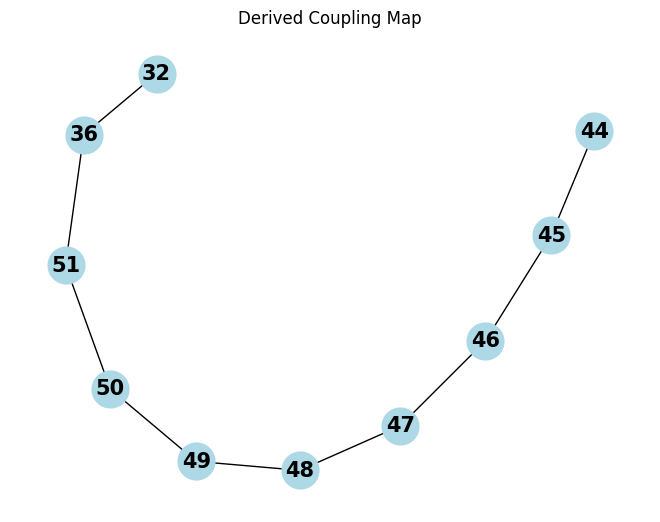

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


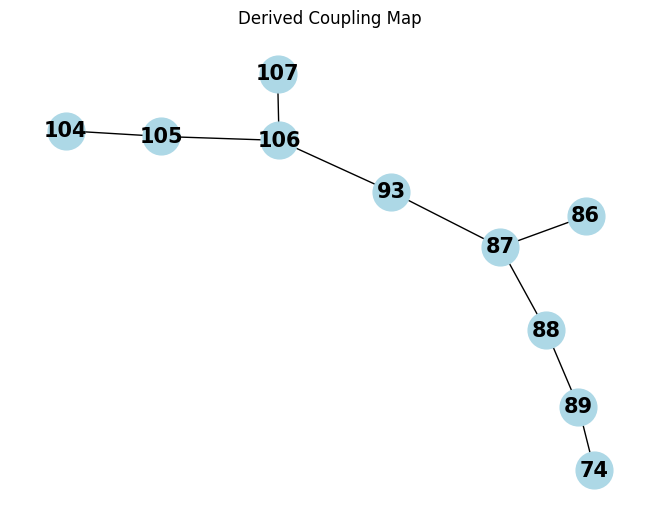

{(45, 46), (44, 45), (48, 49), (28, 35), (45, 54), (47, 48), (35, 47), (46, 47), (43, 44)}


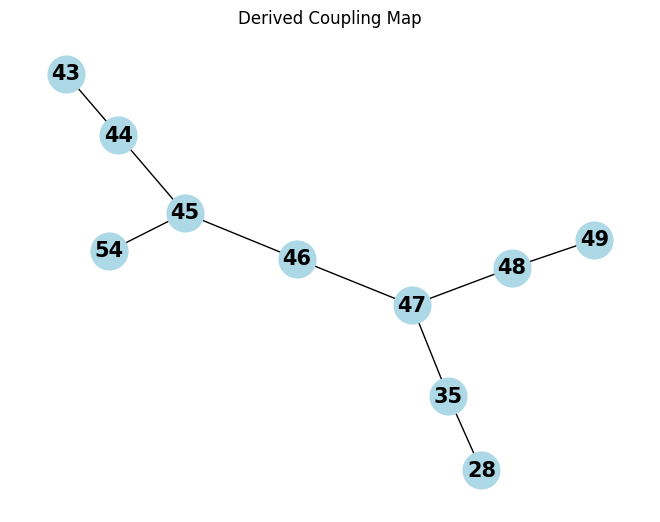

{(68, 69), (70, 74), (105, 106), (87, 93), (88, 89), (69, 70), (93, 106), (74, 89), (87, 88)}


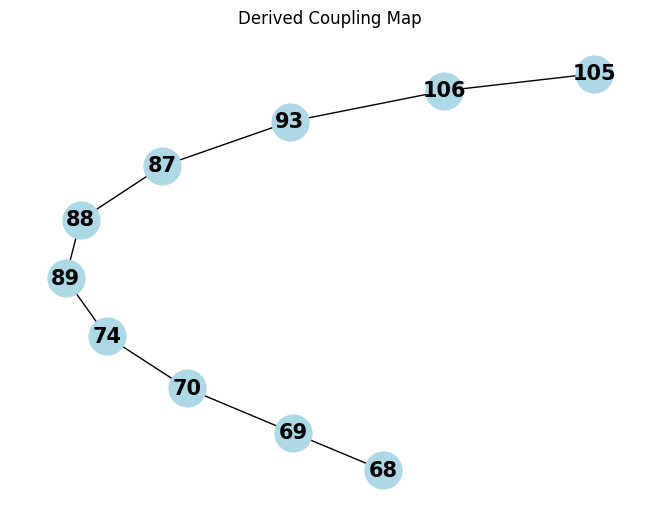

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


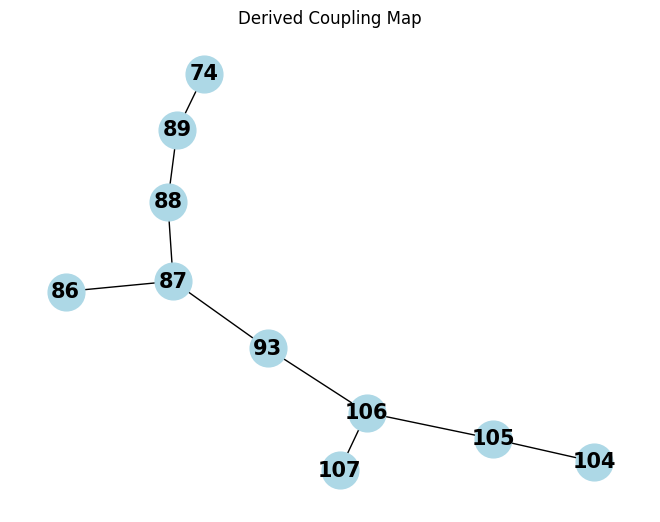

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (85, 86), (93, 106), (107, 108), (87, 88)}


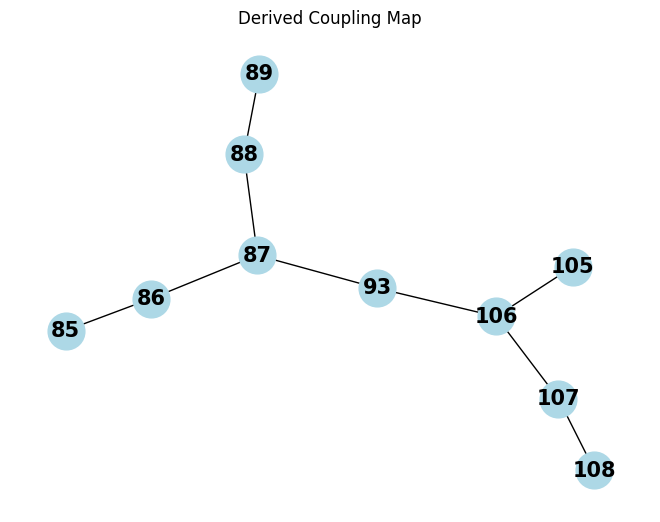

{(68, 69), (67, 68), (70, 74), (87, 93), (88, 89), (69, 70), (93, 106), (74, 89), (87, 88)}


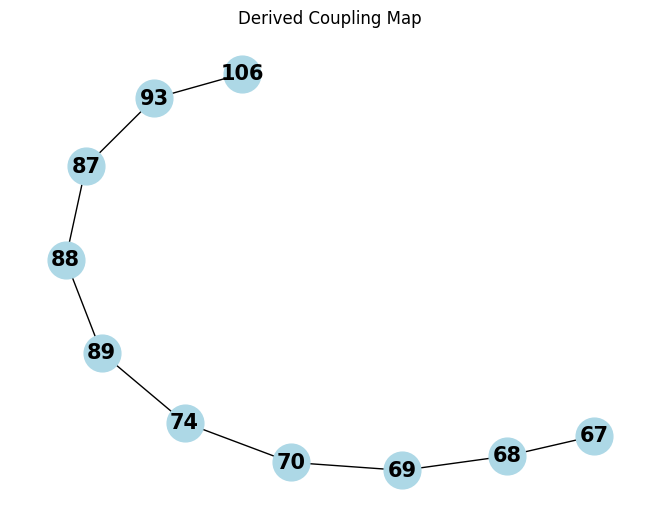

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


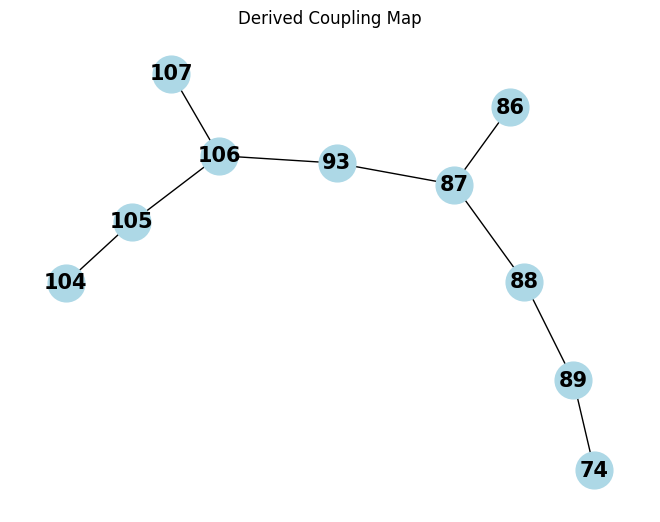

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (85, 86), (93, 106), (107, 108), (87, 88)}


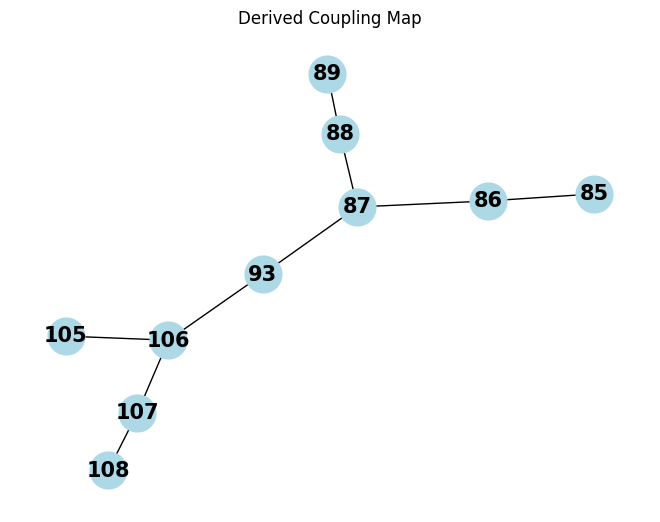

{(68, 69), (67, 68), (70, 74), (87, 93), (88, 89), (69, 70), (93, 106), (74, 89), (87, 88)}


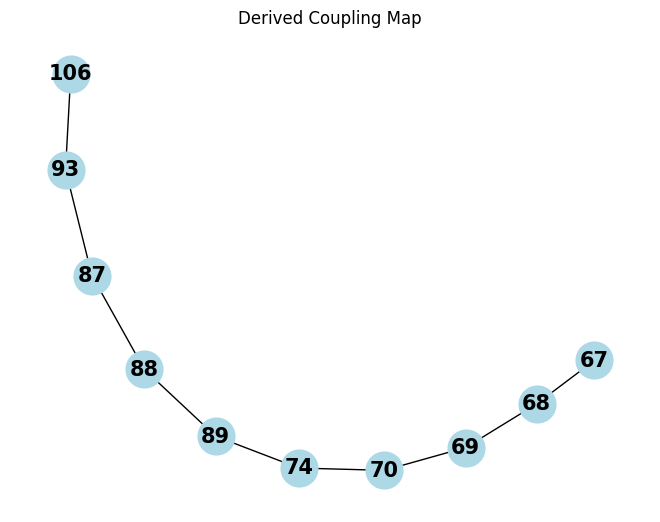

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


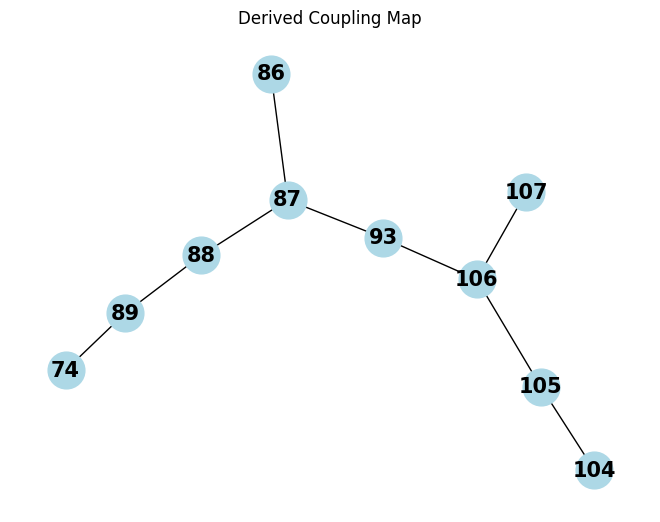

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (85, 86), (93, 106), (107, 108), (87, 88)}


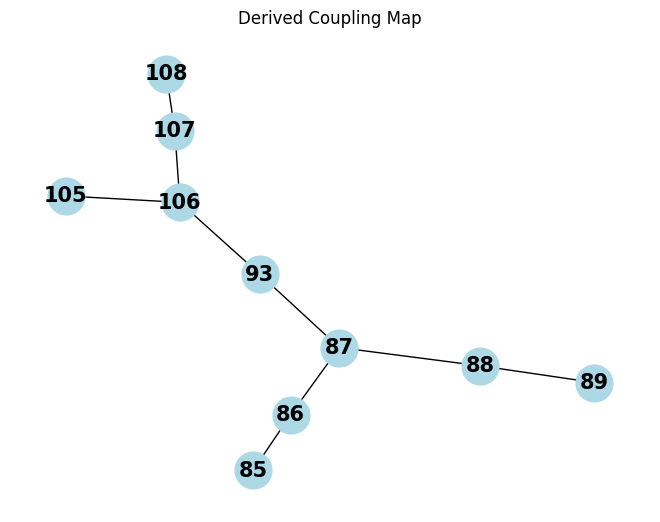

{(68, 69), (67, 68), (70, 74), (87, 93), (88, 89), (69, 70), (93, 106), (74, 89), (87, 88)}


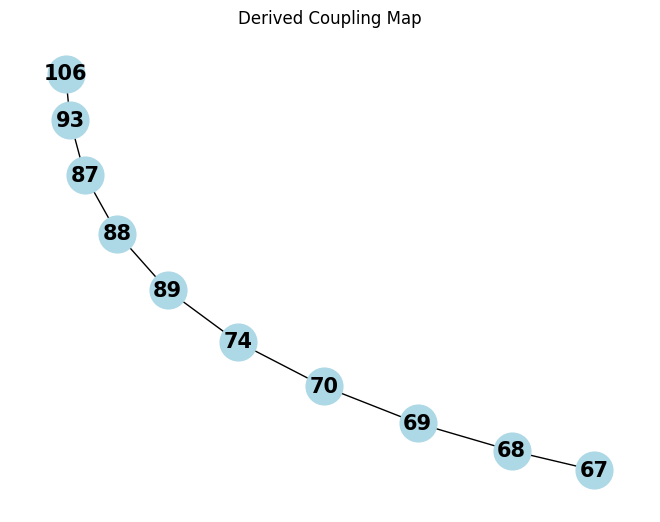

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


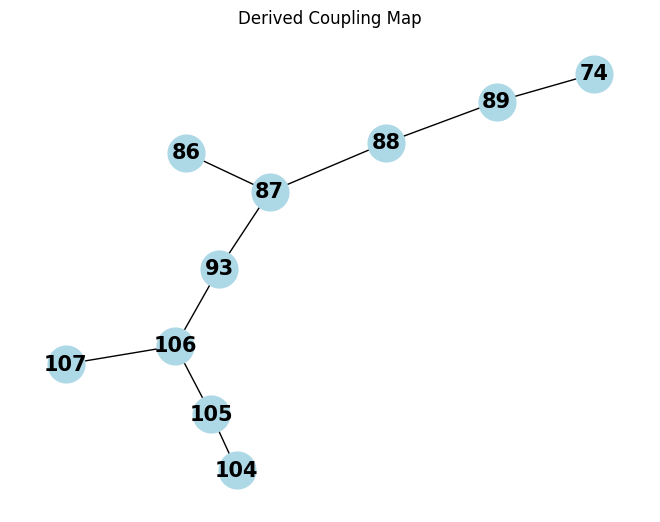

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (85, 86), (93, 106), (107, 108), (87, 88)}


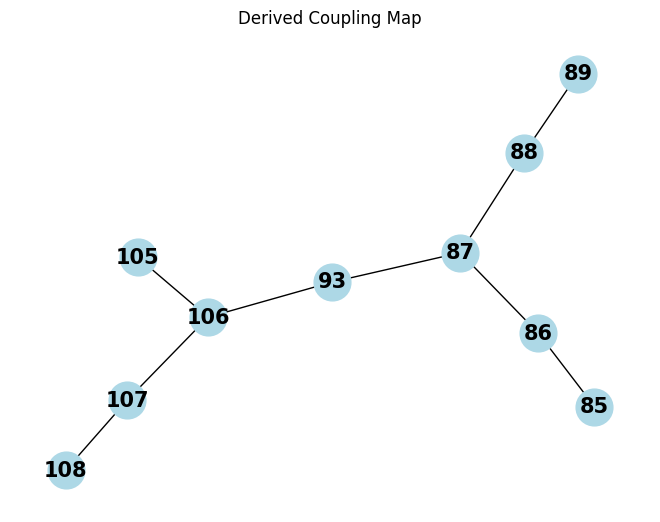

{(68, 69), (67, 68), (70, 74), (87, 93), (88, 89), (69, 70), (93, 106), (74, 89), (87, 88)}


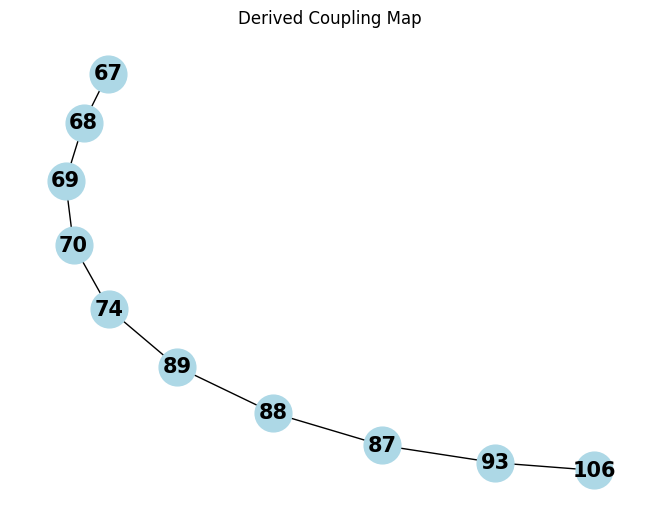

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (93, 106), (74, 89), (104, 105), (87, 88)}


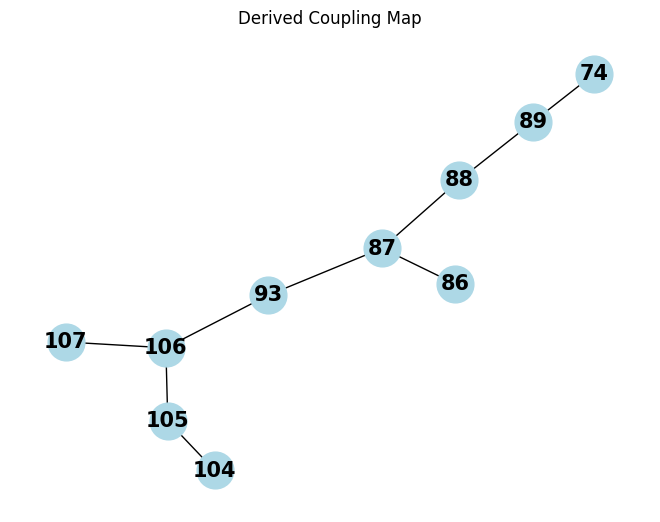

{(106, 107), (87, 93), (105, 106), (86, 87), (88, 89), (85, 86), (93, 106), (107, 108), (87, 88)}


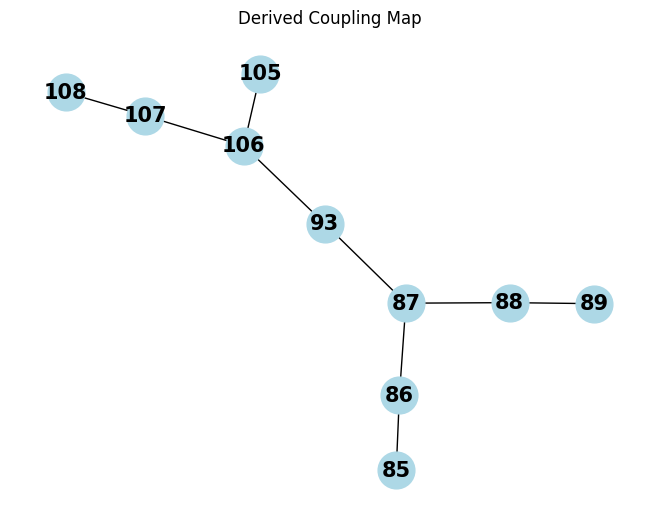

In [ ]:
# combo_grover_big= QuantumCircuit(20)

# # Add the first circuit to the first 5 qubits
# combo_grover_big.append(qft_circuit, combo_grover_big.qubits[1:11])

# # Add the second circuit to the next 10 qubits
# combo_grover_big.append(grover_circuit, [combo_grover_big.qubits[i] for i in [0,11,12,13,14,15,16,17,18,19]])
# Transpile the circuit for the chosen backend
combo_grover_big= transpile(grover_circuit, backend=backend, seed_transpiler=42)

# combo_qft_big= QuantumCircuit(20)

# # Add the first circuit to the first 5 qubits
# combo_qft_big.append(qft_circuit, combo_qft_big.qubits[2:12])

# # Add the second circuit to the next 10 qubits
# combo_qft_big.append(ghz_circuit_new, [combo_qft_big.qubits[i] for i in [0,1,12,13,14,15,16,17,18,19]])
# Transpile the circuit for the chosen backend
combo_qft_big= transpile(qft_circuit, backend=backend, seed_transpiler=42)

derived_map_ghz_big = derive_coupling_map_from_circuit(combo_ghz_circuit_big)
print(derived_map_ghz_big)
plot_coupling_map(derived_map_ghz_big)

derived_map_grover_big = derive_coupling_map_from_circuit(combo_grover_big)
print(derived_map_grover_big)
plot_coupling_map(derived_map_grover_big)

derived_map_qft_big = derive_coupling_map_from_circuit(combo_qft_big)
print(derived_map_qft_big)
plot_coupling_map(derived_map_qft_big)

combo_qft_big= transpile(combo_qft_big, backend=backend, seed_transpiler=35)
combo_grover_big= transpile(combo_grover_big, backend=backend, seed_transpiler=35)
combo_ghz_circuit_big = transpile(combo_ghz_circuit_big, backend=backend, seed_transpiler=35)

derived_map_ghz_big_2 = derive_coupling_map_from_circuit(combo_ghz_circuit_big)
print(derived_map_ghz_big_2)
plot_coupling_map(derived_map_ghz_big_2)

derived_map_grover_big_2 = derive_coupling_map_from_circuit(combo_grover_big)
print(derived_map_grover_big_2)
plot_coupling_map(derived_map_grover_big_2)

derived_map_qft_big_2 = derive_coupling_map_from_circuit(combo_qft_big)
print(derived_map_qft_big_2)
plot_coupling_map(derived_map_qft_big_2)
# Transpile the circuit for the chosen backend
# Transpile the circuit for the chosen backend
combo_qft_big_3= transpile(combo_qft_big, backend=backend, seed_transpiler=20)
combo_grover_big_3= transpile(combo_grover_big, backend=backend, seed_transpiler=20)
combo_ghz_circuit_big_3 = transpile(combo_ghz_circuit_big, backend=backend, seed_transpiler=20)

derived_map_ghz_big_3= derive_coupling_map_from_circuit(combo_ghz_circuit_big_3)
print(derived_map_ghz_big_3)
plot_coupling_map(derived_map_ghz_big_3)

derived_map_grover_big_3 = derive_coupling_map_from_circuit(combo_grover_big_3)
print(derived_map_grover_big_3)
plot_coupling_map(derived_map_grover_big_3)

derived_map_qft_big_3 = derive_coupling_map_from_circuit(combo_qft_big_3)
print(derived_map_qft_big_3)
plot_coupling_map(derived_map_qft_big_3)

combo_qft_big_4= transpile(combo_qft_big_3, backend=backend, seed_transpiler=30)
combo_grover_big_4= transpile(combo_grover_big_3, backend=backend, seed_transpiler=30)
combo_ghz_circuit_big_4 = transpile(combo_ghz_circuit_big_3, backend=backend, seed_transpiler=30)

derived_map_ghz_big_4= derive_coupling_map_from_circuit(combo_ghz_circuit_big_4)
print(derived_map_ghz_big_4)
plot_coupling_map(derived_map_ghz_big_4)

derived_map_grover_big_4 = derive_coupling_map_from_circuit(combo_grover_big_4)
print(derived_map_grover_big_4)
plot_coupling_map(derived_map_grover_big_4)

derived_map_qft_big_4 = derive_coupling_map_from_circuit(combo_qft_big_4)
print(derived_map_qft_big_4)
plot_coupling_map(derived_map_qft_big_4)

combo_qft_big_5= transpile(combo_qft_big_3, backend=backend, seed_transpiler=50)
combo_grover_big_5= transpile(combo_grover_big_3, backend=backend, seed_transpiler=50)
combo_ghz_circuit_big_5 = transpile(combo_ghz_circuit_big_3, backend=backend, seed_transpiler=50)

derived_map_ghz_big_5= derive_coupling_map_from_circuit(combo_ghz_circuit_big_5)
print(derived_map_ghz_big_5)
plot_coupling_map(derived_map_ghz_big_5)

derived_map_grover_big_5 = derive_coupling_map_from_circuit(combo_grover_big_5)
print(derived_map_grover_big_5)
plot_coupling_map(derived_map_grover_big_5)

derived_map_qft_big_5 = derive_coupling_map_from_circuit(combo_qft_big_5)
print(derived_map_qft_big_5)
plot_coupling_map(derived_map_qft_big_5)

# Transpile the circuit for the chosen backend
combo_qft_big_6= transpile(combo_qft_big, backend=backend, seed_transpiler=20)
combo_grover_big_6= transpile(combo_grover_big, backend=backend, seed_transpiler=20)
combo_ghz_circuit_big_6 = transpile(combo_ghz_circuit_big, backend=backend, seed_transpiler=20)

derived_map_ghz_big_6= derive_coupling_map_from_circuit(combo_ghz_circuit_big_6)
print(derived_map_ghz_big_6)
plot_coupling_map(derived_map_ghz_big_6)

derived_map_grover_big_6 = derive_coupling_map_from_circuit(combo_grover_big_6)
print(derived_map_grover_big_6)
plot_coupling_map(derived_map_grover_big_6)

derived_map_qft_big_6 = derive_coupling_map_from_circuit(combo_qft_big_6)
print(derived_map_qft_big_6)
plot_coupling_map(derived_map_qft_big_6)

In [ ]:
from qiskit.circuit.random import random_circuit

# Generate a random 10-qubit quantum circuit with 20 layers of gates
random_circ = random_circuit(num_qubits=15, depth=5, max_operands=2)
combo_rc= QuantumCircuit(20)

# Add the first circuit to the first 5 qubits
combo_rc.append(fourgt11, combo_rc.qubits[1:6])

# Add the second circuit to the next 10 qubits
combo_rc.append(random_circ, [combo_rc.qubits[i] for i in [0,6,7,8,9,10,11,12,13,14,15,16,17,18,19]])
# Transpile the circuit for the chosen backend
combo_rc= transpile(combo_rc, backend=backend, seed_transpiler=42)

derived_map_rc= derive_coupling_map_from_circuit(combo_rc)
logical_to_physical = get_logical_to_physical_mapping(combo_rc)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc = filter_physical_edges(edges_list, derived_map_rc,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc)

random_circ_2 = random_circuit(num_qubits=15, depth=5, max_operands=2)
combo_rc_2= QuantumCircuit(20)

# Add the first circuit to the first 5 qubits
combo_rc_2.append(mod5_4, combo_rc_2.qubits[1:6])

# Add the second circuit to the next 10 qubits
combo_rc_2.append(random_circ_2, [combo_rc_2.qubits[i] for i in [0,6,7,8,9,10,11,12,13,14,15,16,17,18,19]])
# Transpile the circuit for the chosen backend
combo_rc_2= transpile(combo_rc_2, backend=backend, seed_transpiler=42)

derived_map_rc_2= derive_coupling_map_from_circuit(combo_rc_2)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_2)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_2 = filter_physical_edges(edges_list, derived_map_rc_2,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_2)

random_circ_3 = random_circuit(num_qubits=15, depth=5, max_operands=2)

combo_rc_3= QuantumCircuit(20)

# Add the first circuit to the first 5 qubits
combo_rc_3.append(one23, combo_rc_3.qubits[1:6])

# Add the second circuit to the next 10 qubits
combo_rc_3.append(random_circ_3, [combo_rc_3.qubits[i] for i in [0,6,7,8,9,10,11,12,13,14,15,16,17,18,19]])
# Transpile the circuit for the chosen backend
combo_rc_3= transpile(combo_rc_3, backend=backend, seed_transpiler=42)

derived_map_rc_3= derive_coupling_map_from_circuit(combo_rc_3)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_3)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_3 = filter_physical_edges(edges_list, derived_map_rc_3,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_3)

combo_rc_4 = transpile(random_circ, backend=backend, seed_transpiler=40)
combo_rc_5= transpile(random_circ_2, backend=backend, seed_transpiler=40)
combo_rc_6 = transpile(random_circ_3, backend=backend, seed_transpiler=40)

derived_map_rc_4= derive_coupling_map_from_circuit(combo_rc_4)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_4)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_4 = filter_physical_edges(edges_list, derived_map_rc_4,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_4)

derived_map_rc_5= derive_coupling_map_from_circuit(combo_rc_5)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_5)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_5 = filter_physical_edges(edges_list, derived_map_rc_5,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_5)

derived_map_rc_6= derive_coupling_map_from_circuit(combo_rc_6)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_6)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_6 = filter_physical_edges(edges_list, derived_map_rc_6,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_6)

combo_rc_7 = transpile(random_circ, backend=backend, seed_transpiler=45)
combo_rc_8= transpile(random_circ_2, backend=backend, seed_transpiler=45)
combo_rc_9 = transpile(random_circ_3, backend=backend, seed_transpiler=45)

derived_map_rc_7= derive_coupling_map_from_circuit(combo_rc_7)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_7)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_7 = filter_physical_edges(edges_list, derived_map_rc_7,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_7)

derived_map_rc_8= derive_coupling_map_from_circuit(combo_rc_8)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_8)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_8 = filter_physical_edges(edges_list, derived_map_rc_8,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_8)

derived_map_rc_9= derive_coupling_map_from_circuit(combo_rc_9)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_9)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_9 = filter_physical_edges(edges_list, derived_map_rc_9,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_9)

combo_rc_10 = transpile(random_circ, backend=backend, seed_transpiler=49)
combo_rc_11= transpile(random_circ_2, backend=backend, seed_transpiler=49)
combo_rc_12 = transpile(random_circ_3, backend=backend, seed_transpiler=49)

derived_map_rc_10= derive_coupling_map_from_circuit(combo_rc_10)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_10)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_10 = filter_physical_edges(edges_list, derived_map_rc_10,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_10)

derived_map_rc_11= derive_coupling_map_from_circuit(combo_rc_11)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_11)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_11 = filter_physical_edges(edges_list, derived_map_rc_11,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_11)

derived_map_rc_12= derive_coupling_map_from_circuit(combo_rc_12)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_12)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_12 = filter_physical_edges(edges_list, derived_map_rc_12,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_12)

combo_rc_13 = transpile(random_circ, backend=backend, seed_transpiler=69)
combo_rc_14= transpile(random_circ_2, backend=backend, seed_transpiler=69)
combo_rc_15 = transpile(random_circ_3, backend=backend, seed_transpiler=69)

derived_map_rc_13= derive_coupling_map_from_circuit(combo_rc_13)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_13)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_13 = filter_physical_edges(edges_list, derived_map_rc_13,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_13)

derived_map_rc_14= derive_coupling_map_from_circuit(combo_rc_14)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_14)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_14 = filter_physical_edges(edges_list, derived_map_rc_14,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_14)

derived_map_rc_15= derive_coupling_map_from_circuit(combo_rc_15)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_15)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_15 = filter_physical_edges(edges_list, derived_map_rc_15,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_15)

combo_rc_16 = transpile(random_circ, backend=backend, seed_transpiler=89)
combo_rc_17= transpile(random_circ_2, backend=backend, seed_transpiler=89)
combo_rc_18 = transpile(random_circ_3, backend=backend, seed_transpiler=89)

derived_map_rc_16= derive_coupling_map_from_circuit(combo_rc_16)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_16)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_16 = filter_physical_edges(edges_list, derived_map_rc_16,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_16)

derived_map_rc_17= derive_coupling_map_from_circuit(combo_rc_17)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_17)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_17 = filter_physical_edges(edges_list, derived_map_rc_17,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_17)

derived_map_rc_18= derive_coupling_map_from_circuit(combo_rc_18)
logical_to_physical = get_logical_to_physical_mapping(combo_rc_18)
edges_list = mapping_to_edges(logical_to_physical)
exclude_logical_indices={1,2,3,4,5}
filtered_edges_rc_18 = filter_physical_edges(edges_list, derived_map_rc_18,exclude_logical_indices)
plot_coupling_map(filtered_edges_rc_18)

CircuitError: 'The amount of qubit arguments 5 does not match the instruction expectation (4).'

C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:347: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:353: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_22752\2653484263.py:355: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]


{(106, 107), (103, 104), (111, 122), (105, 106), (87, 93), (102, 103), (86, 87), (88, 89), (74, 89), (122, 123), (104, 105), (104, 111), (93, 106), (87, 88)}


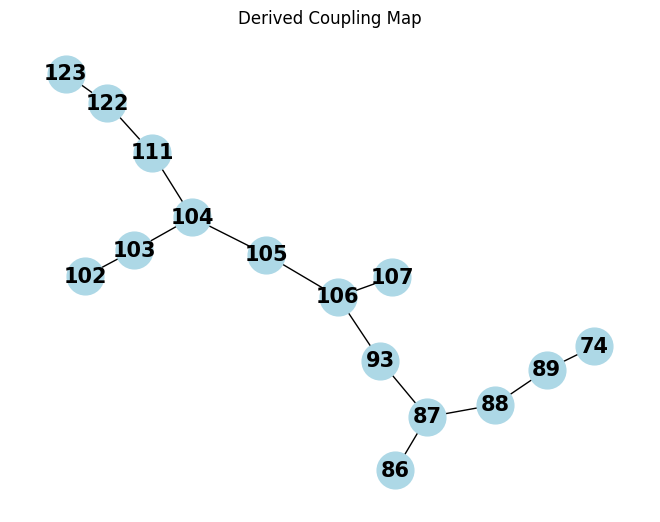

{(41, 53), (45, 46), (44, 45), (48, 49), (41, 42), (50, 51), (32, 36), (31, 32), (36, 51), (47, 48), (49, 50), (42, 43), (46, 47), (43, 44)}


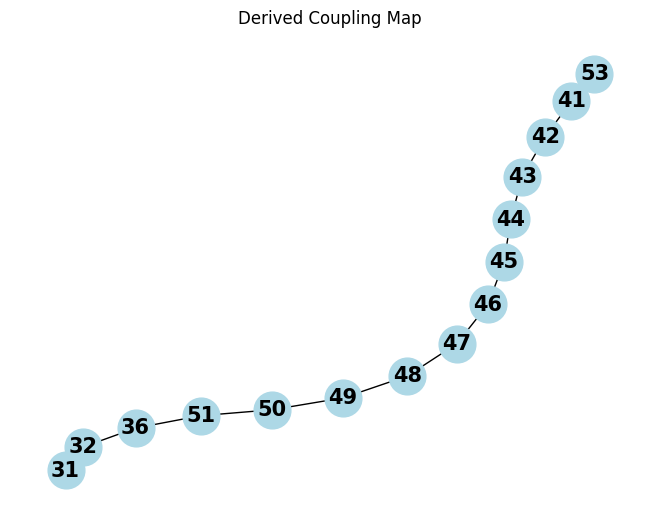

{(34, 43), (41, 53), (61, 62), (45, 46), (63, 64), (35, 47), (44, 45), (54, 64), (41, 42), (45, 54), (47, 48), (60, 61), (40, 41), (62, 63), (42, 43), (46, 47), (43, 44), (53, 60)}


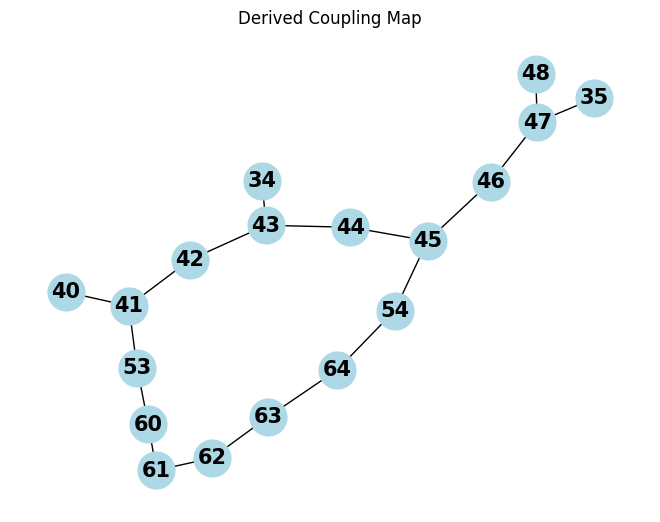

{(106, 107), (103, 104), (105, 106), (87, 93), (102, 103), (111, 122), (86, 87), (85, 86), (104, 105), (104, 111), (93, 106), (87, 88), (73, 85), (84, 85)}


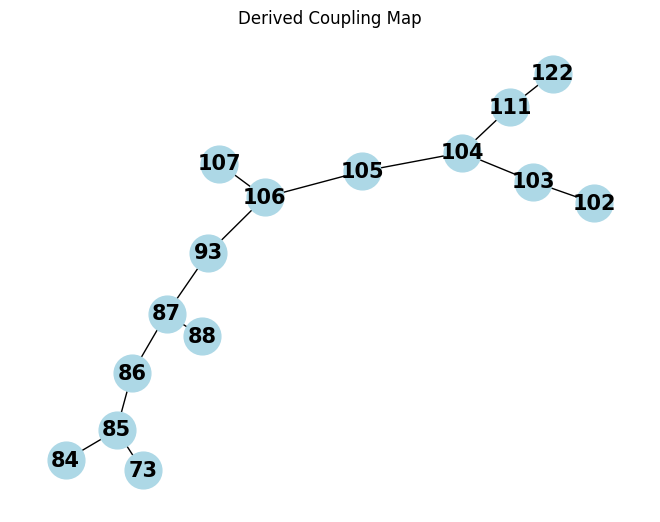

{(41, 53), (45, 46), (44, 45), (48, 49), (41, 42), (50, 51), (32, 36), (31, 32), (36, 51), (47, 48), (49, 50), (42, 43), (46, 47), (43, 44)}


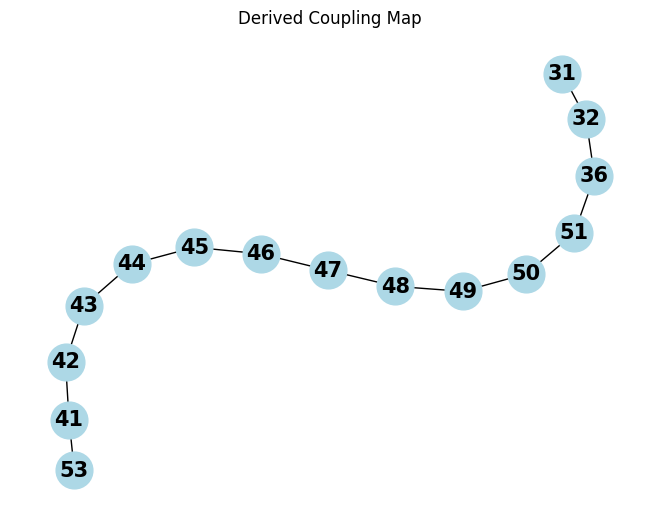

{(34, 43), (45, 46), (44, 45), (48, 49), (54, 64), (28, 35), (42, 43), (45, 54), (47, 48), (35, 47), (46, 47), (43, 44), (24, 34), (27, 28)}


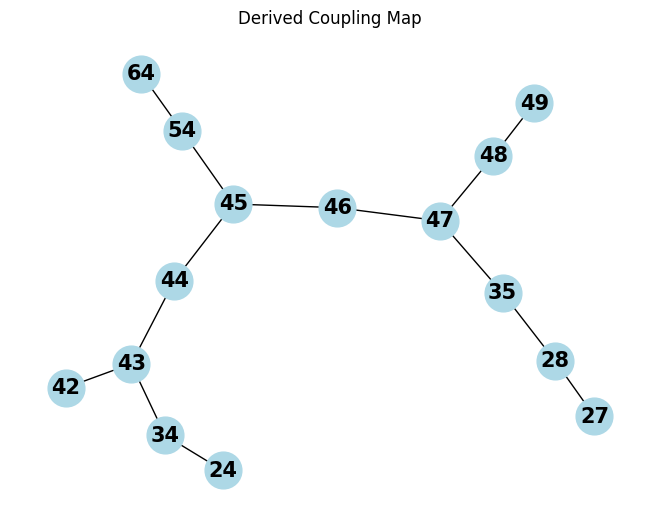

{(34, 43), (41, 53), (45, 46), (44, 45), (48, 49), (28, 35), (42, 43), (41, 42), (45, 54), (47, 48), (49, 50), (35, 47), (46, 47), (43, 44)}


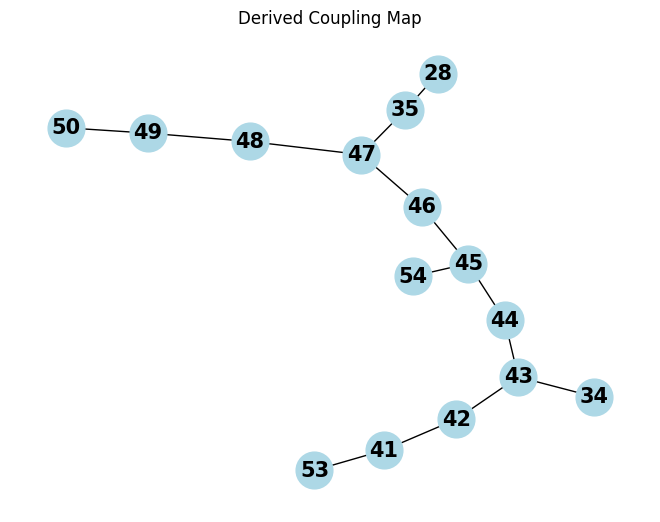

{(41, 53), (45, 46), (44, 45), (48, 49), (41, 42), (50, 51), (32, 36), (31, 32), (36, 51), (47, 48), (49, 50), (42, 43), (46, 47), (43, 44)}


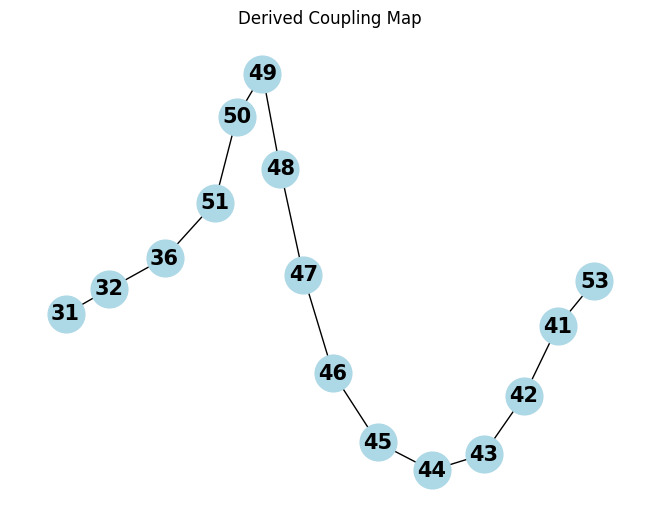

{(106, 107), (103, 104), (121, 122), (111, 122), (105, 106), (87, 93), (86, 87), (88, 89), (74, 89), (122, 123), (104, 105), (104, 111), (93, 106), (87, 88)}


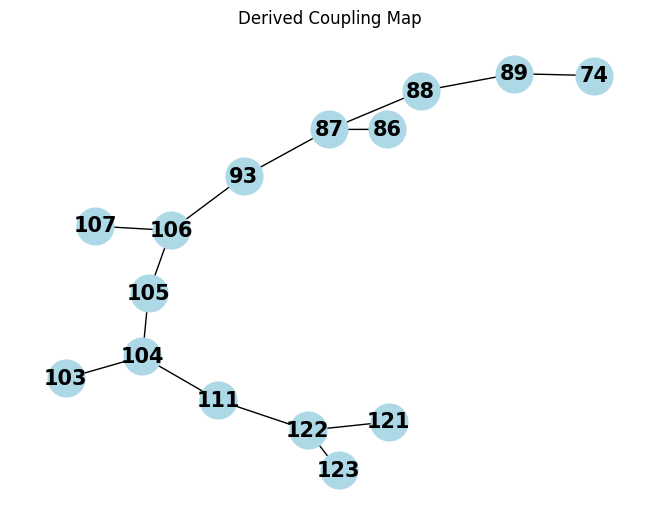

{(34, 43), (45, 46), (44, 45), (48, 49), (28, 35), (42, 43), (50, 51), (45, 54), (47, 48), (49, 50), (35, 47), (46, 47), (43, 44), (24, 34)}


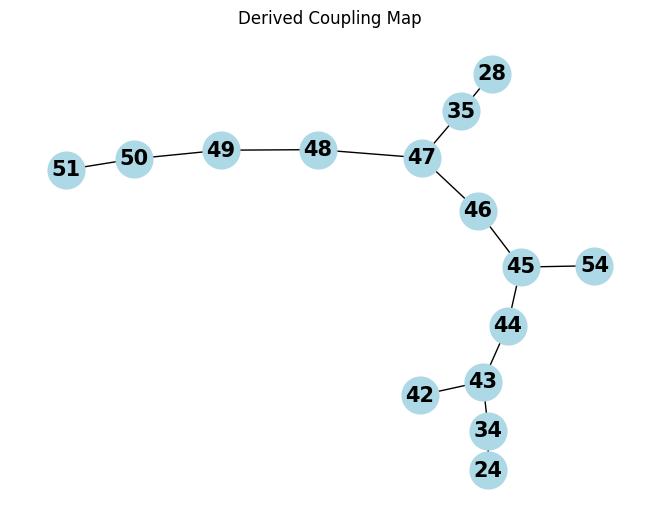

{(41, 53), (45, 46), (44, 45), (48, 49), (41, 42), (50, 51), (32, 36), (31, 32), (36, 51), (47, 48), (49, 50), (42, 43), (46, 47), (43, 44)}


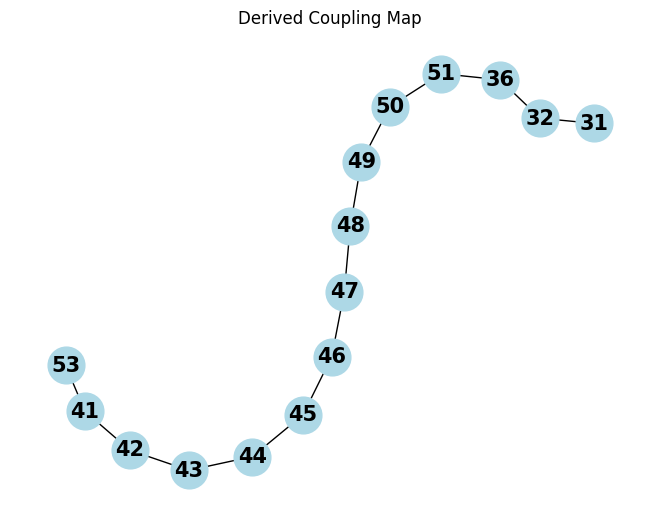

{(110, 118), (100, 110), (79, 91), (99, 100), (118, 119), (80, 81), (72, 81), (79, 80), (101, 102), (98, 99), (78, 79), (100, 101), (91, 98), (97, 98)}


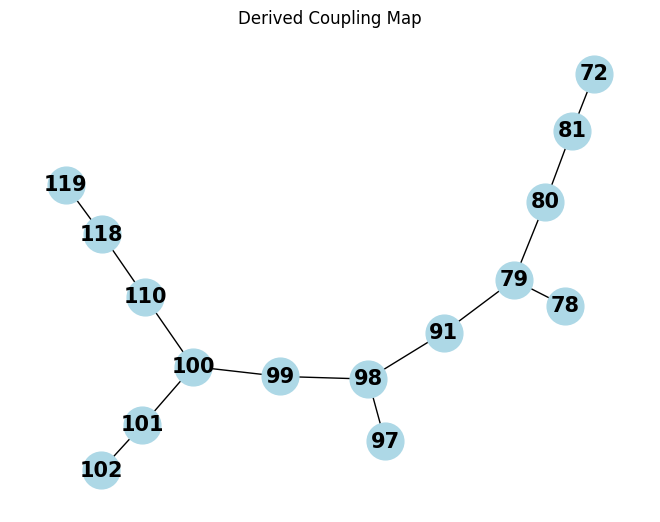

In [ ]:
from qiskit.circuit.random import random_circuit
n_qubits=15
oracle = QuantumCircuit(n_qubits)
oracle.cz(0, 1)  # Define an oracle for example purposes
grover = GroverOperator(oracle)

grover_circuit = QuantumCircuit(n_qubits)
grover_circuit.h(range(n_qubits))  # Apply Hadamard
grover_circuit.append(grover, range(n_qubits))  # Apply Grover iteration

# Generate a random 10-qubit quantum circuit with 20 layers of gates
# line_15 = CouplingMap([(0, 5), (5, 9), (9, 10), (10, 11),(9,8),(8,7),(16,7),(19,16),(20,19),(20,21),(21,22),(22,23),(23,24),(24,25)])
compiled_rc_4 = transpile(grover_circuit, backend=backend, seed_transpiler=42)

derived_map_rc_4 = derive_coupling_map_from_circuit(compiled_rc_4)
print(derived_map_rc_4)
plot_coupling_map(derived_map_rc_4)

n_qubits = 15
ghz_circuit_new = QuantumCircuit(n_qubits)
ghz_circuit_new.h(0)  # Apply Hadamard on the first qubit
for qubit in range(n_qubits-1):
    ghz_circuit_new.cx(qubit, qubit + 1)  # Create entanglement

# ghz_circuit_new.measure_all()

ghz_circuit_new.draw('mpl')
# t_15 = CouplingMap([(11,12),(12,13),(13,14) ,(14,15),(11,17),(17,23),(15,18),(18,27),(23,24),(24,25),(25,26),(26,27),(3,4),(4,6),(6,13)])
compiled_rc_5 = transpile(ghz_circuit_new, backend=backend, seed_transpiler=42)

derived_map_rc_5 = derive_coupling_map_from_circuit(compiled_rc_5)
print(derived_map_rc_5)
plot_coupling_map(derived_map_rc_5)

compiled_rc_7 = transpile(grover_circuit, backend=backend, seed_transpiler=40)
compiled_rc_8 = transpile(ghz_circuit_new, backend=backend, seed_transpiler=40)

qft_circuit = qft_dagger(n_qubits)
# cm_15 = CouplingMap([(0,1),(2,1),(2,3),(3,4),(4,6),(6,13),(13,14),(14,15),(15,18),(18,27),(27,26),(26,25),(25,24),(23,24)])
# cm_15_2 = CouplingMap([(0,1),(2,1),(2,3),(3,4),(0,5),(5,9),(9,8),(8,7),(7,16),(16,19),(19,20),(21,22),(22,23)])

compiled_rc_6 = transpile(qft_circuit, backend=backend, seed_transpiler=42)
# compiled_rc_7 = transpile(qft_circuit, backend=backend, coupling_map=t_15,seed_transpiler=42)
compiled_rc_9 = transpile(qft_circuit, backend=backend, seed_transpiler=40)
compiled_rc_10 = transpile(qft_circuit, backend=backend, seed_transpiler=41)
compiled_rc_11 = transpile(ghz_circuit_new, backend=backend, seed_transpiler=41)
compiled_rc_12 = transpile(grover_circuit, backend=backend, seed_transpiler=41)
compiled_rc_13 = transpile(qft_circuit, backend=backend, seed_transpiler=38)
compiled_rc_14 = transpile(ghz_circuit_new, backend=backend, seed_transpiler=38)
compiled_rc_15 = transpile(grover_circuit, backend=backend, seed_transpiler=38)

derived_map_rc_6= derive_coupling_map_from_circuit(compiled_rc_6)
print(derived_map_rc_6)
plot_coupling_map(derived_map_rc_6)

derived_map_rc_7= derive_coupling_map_from_circuit(compiled_rc_7)
print(derived_map_rc_7)
plot_coupling_map(derived_map_rc_7)

derived_map_rc_8= derive_coupling_map_from_circuit(compiled_rc_8)
print(derived_map_rc_8)
plot_coupling_map(derived_map_rc_8)

derived_map_rc_9= derive_coupling_map_from_circuit(compiled_rc_9)
print(derived_map_rc_9)
plot_coupling_map(derived_map_rc_9)

derived_map_rc_10= derive_coupling_map_from_circuit(compiled_rc_10)
print(derived_map_rc_10)
plot_coupling_map(derived_map_rc_10)

derived_map_rc_11= derive_coupling_map_from_circuit(compiled_rc_11)
print(derived_map_rc_11)
plot_coupling_map(derived_map_rc_11)

derived_map_rc_12= derive_coupling_map_from_circuit(compiled_rc_12)
print(derived_map_rc_12)
plot_coupling_map(derived_map_rc_12)

derived_map_rc_13= derive_coupling_map_from_circuit(compiled_rc_13)
print(derived_map_rc_13)
plot_coupling_map(derived_map_rc_13)

derived_map_rc_14= derive_coupling_map_from_circuit(compiled_rc_14)
print(derived_map_rc_14)
plot_coupling_map(derived_map_rc_14)

derived_map_rc_15= derive_coupling_map_from_circuit(compiled_rc_15)
print(derived_map_rc_15)
plot_coupling_map(derived_map_rc_15)


In [33]:
from collections import Counter, defaultdict
from qiskit.circuit.random import random_circuit
from qiskit import transpile
import numpy as np
np.random.seed(42)
from qiskit.quantum_info import state_fidelity, partial_trace, DensityMatrix
# from qiskit_aer.primitives import Sampler  # Aer Sampler runs locally
from qiskit_ibm_runtime import Sampler
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
 
# Get a fake backend from the fake provider
backend = FakeManilaV2()
# Assume backend is defined somewhere earlier in your environment
sampler = Sampler(backend)  # no backend needed, runs on AerSimulator under the hood

def standardize_counts(counts, num_qubits):
    """Convert all keys to little-endian bitstring format used by Qiskit get_counts()."""
    new_counts = {}
    for k, v in counts.items():
        if isinstance(k, int):  # integer key
            bitstring = format(k, f"0{num_qubits}b")[::-1]  # reverse for little-endian
        elif isinstance(k, (list, tuple)):  # tuple or list of bits
            bitstring = "".join(str(b) for b in reversed(k))  # reverse order
        else:  # assume string
            bitstring = k
        new_counts[bitstring] = new_counts.get(bitstring, 0) + v
    return new_counts

def get_ideal_counts(circuit, shots=1000):
    # Ensure circuit has measurements for counts

    
    job = sim.run(circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()
    return counts
def normalize_counts(counts):
    """Normalize counts dictionary to probabilities."""
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

def classical_fidelity(p, q):
    """Calculate classical fidelity (Bhattacharyya coefficient) between two distributions p and q."""
    all_keys = set(p.keys()).union(q.keys())
    fidelity = 0
    for k in all_keys:
        fidelity += np.sqrt(p.get(k, 0) * q.get(k, 0))
    return fidelity

def compute_circuit_fidelity(qc, backend, shots=1000):
    cr = ClassicalRegister(1, name='c')
    qc.add_register(cr)


    # Allowed gates (no "dcx")
    allowed_gates = ["cx", "h", "x", "y", "z", "rx", "ry", "rz", "sx", "u", "id"]

  

    # Convert to only allowed gates (transpile)

    qc = transpile(qc, basis_gates=allowed_gates)

    # Measure qubit 1 into the classical bit 0 of 'c'
    qc.measure(2, cr[0])
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_isa = pm.run(qc)

    # -------------------
    # 1) Run on real backend (or Sampler)
    sampler = Sampler(mode=backend)
    counts_backend = sampler.run([qc_isa], shots=1000).result()[0].data.c.get_counts()
    print("Counts from backend:", counts_backend)
    backend = AerSimulator()
    # -------------------
    # 2) Run same transpiled circuit on statevector simulator for fidelity
    pm = generate_preset_pass_manager(backend=sim, optimization_level=3)
    qc_isa = pm.run(qc)

    # -------------------
    # 1) Run on real backend (or Sampler)
    sampler = Sampler(mode=backend)
    counts_sim = sampler.run([qc_isa], shots=1000).result()[0].data.c.get_counts()
    print("Counts from backend:", counts_sim)

    all_keys = set(counts_backend.keys()).union(set(counts_sim.keys()))
    fidelity = sum(
        (counts_backend.get(k, 0) / shots) ** 0.5 *
        (counts_sim.get(k, 0) / shots) ** 0.5
        for k in all_keys
    ) ** 2

    print("Classical fidelity:", fidelity)
    return fidelity


def compute_transpiler_fidelity_expression(transpiled_circuit, derived_coupling_map, backend):
    """
    Build a symbolic fidelity LHS expression from the transpiled circuit,
    ignoring virtual-Z type gates (rz, u1, u2).
    """
    basis_gates = backend.configuration().basis_gates  # get native gate set

    transpiled_circuit = transpile(
        transpiled_circuit,
        backend=backend,
        basis_gates=basis_gates,
        optimization_level=3
    )

    gate_counts = defaultdict(int)
    readout_qubits = set()

    # gates to ignore (virtual Z rotations)
    ignore_gates = {"rz", "u1", "u2", "p"}

    for inst, qargs, _ in transpiled_circuit.data:
        if not qargs:
            continue  # skip barriers, etc.
        q_indices = tuple(transpiled_circuit.find_bit(qarg).index for qarg in qargs)
        sorted_indices = tuple(sorted(q_indices))

        if inst.name in ignore_gates:
            continue  # skip virtual-Z gates

        # Only include 2Q gates present in derived coupling map
        if len(q_indices) == 2 and sorted_indices not in derived_coupling_map:
            continue

        if inst.name == "measure":
            readout_qubits.add(q_indices[0])
        else:
            gate_counts[(inst.name, sorted_indices)] += 1

    # 🔹 Build symbolic expression
    symbolic_terms = []
    for (gname, qubits), count in gate_counts.items():
        symbolic_terms.append(f"(1 - ε_{gname}{qubits})^{count}")

    for q in sorted(readout_qubits):
        symbolic_terms.append(f"(1 - ε_ro_q{q})")

    return " * ".join(symbolic_terms) if symbolic_terms else "1"

def build_fidelity_equation_with_rhs(transpiled_circuit, derived_coupling_map, shots=1000):
    lhs_expr = compute_transpiler_fidelity_expression(transpiled_circuit, derived_coupling_map, backend)
    rhs_fid = compute_circuit_fidelity(transpiled_circuit, backend, shots)
    rhs_value = f"{rhs_fid:.6f}"
    return f"{lhs_expr} = {rhs_value}"

from qiskit.circuit.random import random_circuit
import numpy as np

equation_list = []


for i in range(16):  # more circuits
    num_qubits = 5
    # depth = np.random.randint(5, 30)  # deeper circuits
    qc = random_circuit(num_qubits, 2, max_operands=2, seed=42+i)
    big_rc = derive_coupling_map_from_circuit(qc)
    symbolic = build_fidelity_equation_with_rhs(qc, big_rc, shots=1000)
    equation_list.append(symbolic)



print("\n".join(equation_list))


C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:78: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]
c:\Users\rupsh\AppData\Local\Program

Counts from backend: {'0': 933, '1': 67}
Counts from backend: {'0': 1000}
Classical fidelity: 0.9329999999999999


C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:78: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]
c:\Users\rupsh\AppData\Local\Program

Counts from backend: {'0': 765, '1': 235}
Counts from backend: {'1': 208, '0': 792}
Classical fidelity: 0.9989425934006542


C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:72: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for qarg in instruction[1]:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1

...

Counts from backend: {'1': 922, '0': 78}
Counts from backend: {'1': 1000}
Classical fidelity: 0.922


C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:78: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]
c:\Users\rupsh\AppData\Local\Program

Counts from backend: {'0': 925, '1': 75}
Counts from backend: {'0': 931, '1': 69}
Classical fidelity: 0.9998652519377468


C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:70: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\1553622732.py:76: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
c:\Users\rupsh\AppData\Local\Programs\Python\Python310\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(
C:\Users\rupsh\AppData\Local\Temp\ipykernel_29020\

Counts from backend: {'0': 930, '1': 70}
Counts from backend: {'0': 1000}
Classical fidelity: 0.9300000000000002
(1 - ε_sx(0,))^5 * (1 - ε_sx(1,))^4 * (1 - ε_sx(3,))^2 * (1 - ε_x(4,))^1 = 0.933000
(1 - ε_sx(0,))^3 * (1 - ε_sx(4,))^2 = 0.998943
(1 - ε_x(1,))^1 * (1 - ε_x(0,))^1 * (1 - ε_x(2,))^1 * (1 - ε_sx(4,))^2 * (1 - ε_x(4,))^1 * (1 - ε_x(3,))^1 = 0.879000
(1 - ε_cx(0, 1))^2 * (1 - ε_sx(2,))^2 * (1 - ε_sx(3,))^2 * (1 - ε_cx(2, 3))^2 * (1 - ε_cx(1, 2))^1 = 0.997798
(1 - ε_sx(0,))^3 * (1 - ε_sx(1,))^1 * (1 - ε_sx(2,))^2 * (1 - ε_sx(4,))^1 = 0.999936
(1 - ε_x(1,))^1 * (1 - ε_cx(0, 1))^2 * (1 - ε_x(0,))^1 * (1 - ε_sx(0,))^2 * (1 - ε_sx(2,))^2 * (1 - ε_cx(1, 2))^2 * (1 - ε_sx(3,))^2 * (1 - ε_sx(4,))^1 = 0.960000
(1 - ε_sx(0,))^3 * (1 - ε_sx(4,))^2 = 0.974094
(1 - ε_cx(0, 1))^2 * (1 - ε_sx(1,))^2 * (1 - ε_sx(3,))^4 * (1 - ε_sx(2,))^2 * (1 - ε_sx(4,))^2 = 0.977000
(1 - ε_sx(0,))^2 * (1 - ε_sx(1,))^3 * (1 - ε_x(0,))^1 * (1 - ε_sx(2,))^2 * (1 - ε_x(4,))^2 * (1 - ε_x(3,))^1 = 0.985000
(1 - ε_

In [ ]:
from collections import Counter, defaultdict
from qiskit.circuit.random import random_circuit
from qiskit import transpile, ClassicalRegister
import numpy as np
np.random.seed(42)
from qiskit.quantum_info import state_fidelity, partial_trace, DensityMatrix
from qiskit_ibm_runtime import Sampler, Options
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_aer import AerSimulator

# Get a fake backend from the fake provider
backend = FakeManilaV2()
sim = AerSimulator()  # Statevector simulator for ideal counts

def standardize_counts(counts, num_qubits):
    """Convert all keys to little-endian bitstring format used by Qiskit get_counts()."""
    new_counts = {}
    for k, v in counts.items():
        if isinstance(k, int):  # integer key
            bitstring = format(k, f"0{num_qubits}b")[::-1]  # reverse for little-endian
        elif isinstance(k, (list, tuple)):  # tuple or list of bits
            bitstring = "".join(str(b) for b in reversed(k))  # reverse order
        else:  # assume string
            bitstring = k
        new_counts[bitstring] = new_counts.get(bitstring, 0) + v
    return new_counts

def get_ideal_counts(circuit, shots=1000):
    """Get ideal counts from statevector simulator."""
    # Ensure circuit has measurements for counts
    job = sim.run(circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()
    return counts

def normalize_counts(counts):
    """Normalize counts dictionary to probabilities."""
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

def classical_fidelity(p, q):
    """Calculate classical fidelity (Bhattacharyya coefficient) between two distributions p and q."""
    all_keys = set(p.keys()).union(q.keys())
    fidelity = 0
    for k in all_keys:
        fidelity += np.sqrt(p.get(k, 0) * q.get(k, 0))
    return fidelity

def compute_circuit_fidelity(qc, backend, shots=1000):
    """Compute fidelity between ideal and noisy execution."""
    # Add classical register for measurement
    cr = ClassicalRegister(1, name='c')
    qc_with_meas = qc.copy()
    qc_with_meas.add_register(cr)
    qc_with_meas.measure(2, cr[0])  # Measure qubit 2

    # Allowed gates
    allowed_gates = ["cx", "h", "x", "y", "z", "rx", "ry", "rz", "sx", "u", "id"]

    # Transpile to allowed gates
    qc_transpiled = transpile(qc_with_meas, basis_gates=allowed_gates)

    # Get backend counts using the new Sampler API
    options = Options()
    options.execution.shots = shots
    options.simulator.seed_simulator = 42
    
    # Use the backend for simulation
    sampler = Sampler(backend=backend, options=options)
    counts_backend = sampler.run(qc_transpiled).result().quasi_dists[0]
    
    # Convert quasi distribution to counts
    backend_counts = {}
    for state, prob in counts_backend.items():
        backend_counts[format(state, '01b')] = int(prob * shots)
    
    # Get ideal counts from simulator
    ideal_counts = get_ideal_counts(qc_transpiled, shots=shots)
    
    # Calculate classical fidelity
    p = normalize_counts(backend_counts)
    q = normalize_counts(ideal_counts)
    fidelity = classical_fidelity(p, q)
    
    print(f"Classical fidelity: {fidelity:.6f}")
    return fidelity

def derive_coupling_map_from_circuit(circuit):
    """Derive coupling map from circuit structure."""
    coupling_map = set()
    
    for instruction in circuit.data:
        qargs = instruction.qubits
        if len(qargs) == 2:
            q1 = circuit.find_bit(qargs[0]).index
            q2 = circuit.find_bit(qargs[1]).index
            coupling_map.add(tuple(sorted((q1, q2))))
    
    return list(coupling_map)

def compute_transpiler_fidelity_expression(transpiled_circuit, derived_coupling_map, backend):
    """
    Build a symbolic fidelity LHS expression from the transpiled circuit.
    """
    basis_gates = backend.configuration().basis_gates
    transpiled_circuit = transpile(
        transpiled_circuit,
        backend=backend,
        basis_gates=basis_gates,
        optimization_level=1  # Reduced optimization for simplicity
    )

    gate_counts = defaultdict(int)
    readout_qubits = set()

    for instruction in transpiled_circuit.data:
        qargs = instruction.qubits
        if not qargs:
            continue
        
        q_indices = tuple(transpiled_circuit.find_bit(qarg).index for qarg in qargs)
        sorted_indices = tuple(sorted(q_indices))

        # Only include 2Q gates present in derived coupling map
        if len(q_indices) == 2 and sorted_indices not in derived_coupling_map:
            continue

        if instruction.operation.name == "measure":
            readout_qubits.add(q_indices[0])
        else:
            gate_counts[(instruction.operation.name, sorted_indices)] += 1

    # Build symbolic expression
    symbolic_terms = []
    for (gname, qubits), count in gate_counts.items():
        if len(qubits) == 1:
            symbolic_terms.append(f"(1 - ε_{gname}({qubits[0]},))^{count}")
        else:
            symbolic_terms.append(f"(1 - ε_{gname}({qubits[0]}, {qubits[1]}))^{count}")

    for q in sorted(readout_qubits):
        symbolic_terms.append(f"(1 - ε_ro({q},))")

    return " * ".join(symbolic_terms)

def build_fidelity_equation_with_rhs(transpiled_circuit, derived_coupling_map, shots=1000):
    """Build fidelity equation with RHS value."""
    try:
        lhs_expr = compute_transpiler_fidelity_expression(transpiled_circuit, derived_coupling_map, backend)
        rhs_fid = compute_circuit_fidelity(transpiled_circuit, backend, shots)
        rhs_value = f"{rhs_fid:.6f}"
        return f"{lhs_expr} = {rhs_value}"
    except Exception as e:
        print(f"Error in build_fidelity_equation_with_rhs: {e}")
        return None

# Generate equations
equation_list = []

print("Generating equations...")
for i in range(5):  # Start with even fewer equations for testing
    try:
        print(f"Generating equation {i+1}...")
        qc = random_circuit(3, 2, max_operands=2, seed=42+i)  # Smaller circuit
        big_rc = derive_coupling_map_from_circuit(qc)
        symbolic = build_fidelity_equation_with_rhs(qc, big_rc, shots=100)
        
        if symbolic:
            equation_list.append(symbolic)
            print(f"Generated equation {i+1}: {symbolic}")
        else:
            print(f"Failed to generate equation {i+1}")
            
    except Exception as e:
        print(f"Error generating equation {i+1}: {e}")
        continue

print(f"\nTotal equations generated: {len(equation_list)}")

if equation_list:
    print("\nFirst few equations:")
    for i, eq in enumerate(equation_list[:3]):
        print(f"{i+1}. {eq}")
    
    # Now solve the equations
    print("\n=== Solving equation system ===")
    sols = find_exact_eps_solutions(equation_list, validate_tol=1e-9)
    print("Solutions:", sols)
else:
    print("No equations were generated successfully!")

Generating equations...
Generating equation 1...
Error in build_fidelity_equation_with_rhs: 'OptionsV2' object has no attribute 'execution'
Failed to generate equation 1
Generating equation 2...
Error in build_fidelity_equation_with_rhs: 'OptionsV2' object has no attribute 'execution'
Failed to generate equation 2
Generating equation 3...
Error in build_fidelity_equation_with_rhs: 'OptionsV2' object has no attribute 'execution'
Failed to generate equation 3
Generating equation 4...
Error in build_fidelity_equation_with_rhs: 'OptionsV2' object has no attribute 'execution'
Failed to generate equation 4
Generating equation 5...
Error in build_fidelity_equation_with_rhs: 'OptionsV2' object has no attribute 'execution'
Failed to generate equation 5

Total equations generated: 0
No equations were generated successfully!


In [34]:
import re
import numpy as np
from scipy.optimize import least_squares

# ------------ helpers ------------
_TOKEN_RE = re.compile(r"ε_(\w+)\(([^)]*)\)")  # matches ε_gate(args)

_TWO_QUBIT_GATES = {"cx", "cy", "cz", "ecr", "iswap", "dcx"}

def _canon_key(gate: str, argstr: str) -> str:
    nums = re.findall(r"\d+", argstr)
    if not nums:
        return gate
    return f"{gate}_{'_'.join(nums)}"

def _collect_var_names(equations):
    keys = set()
    for eq in equations:
        lhs, _ = eq.split("=")
        for m in _TOKEN_RE.finditer(lhs):
            keys.add(_canon_key(m.group(1), m.group(2)))
    return sorted(keys)

def _compile_equation(lhs_expr: str, index_map: dict):
    lhs_expr = lhs_expr.replace("^", "**")

    def _repl(m: re.Match) -> str:
        gate, argstr = m.group(1), m.group(2)
        key = _canon_key(gate, argstr)
        idx = index_map[key]
        return f"x[{idx}]"

    expr = _TOKEN_RE.sub(_repl, lhs_expr)
    code = compile(expr, "<fidelity_expr>", "eval")

    def f(x):
        return eval(code, {"__builtins__": {}}, {"x": x, "np": np})

    return f

# ------------ log-space solver ------------
def solve_with_log_space(equations):
    if not equations:
        raise ValueError("No equations provided.")

    var_names = _collect_var_names(equations)
    if not var_names:
        raise ValueError("No variables found in equations.")

    index_map = {name: i for i, name in enumerate(var_names)}

    # Build residuals
    residual_funcs = []
    for eq in equations:
        lhs, rhs = eq.split("=")
        lhs, rhs_val = lhs.strip(), float(rhs.strip())
        f_lhs = _compile_equation(lhs, index_map)

        def make_residual(f=f_lhs, rhs_val=rhs_val):
            return lambda y: f(10**y) - rhs_val  # convert log vars -> linear
        residual_funcs.append(make_residual())

    def stacked_residuals(y):
        return np.array([rf(y) for rf in residual_funcs], dtype=float)

    # Bounds in log space
    lb, ub = np.empty(len(var_names)), np.empty(len(var_names))
    for i, name in enumerate(var_names):
        gate = name.split("_", 1)[0]
        if gate in _TWO_QUBIT_GATES:
            lb[i], ub[i] = 1e-4, 5e-2
        else:
            lb[i], ub[i] = 1e-5, 5e-3

    log_lb, log_ub = np.log10(lb), np.log10(ub)

    # Initial guess: mid-point in log space
    y0 = (log_lb + log_ub) / 2

    # Solve in log space
    res = least_squares(stacked_residuals, y0,
                        bounds=(log_lb, log_ub),
                        method="trf", ftol=1e-9, xtol=1e-9, gtol=1e-9)

    # Convert solution back to linear
    x_sol = 10**res.x
    sol = {name: float(x_sol[i]) for i, name in enumerate(var_names)}
    return sol, res.cost, res.success


# ------------- example -------------
if __name__ == "__main__":
    # Example usage – replace equation_list with your own


    sol, cost, ok = solve_with_realistic_bounds(equation_list)
    print("Success:", ok)
    print("Cost:", cost)
    print("Solution:")
    for k, v in sol.items():
        print(f"  {k} = {v:.6e}")


Success: True
Cost: 0.011001135352760986
Solution:
  cx_0_1 = 1.019659e-02
  cx_1_2 = 1.211666e-03
  cx_2_3 = 1.914446e-02
  cx_3_4 = 9.156163e-03
  sx_0 = 2.610439e-03
  sx_1 = 4.628540e-03
  sx_2 = 1.000015e-05
  sx_3 = 1.386528e-03
  sx_4 = 4.113364e-03
  x_0 = 1.000000e-05
  x_1 = 3.724164e-03
  x_2 = 3.086671e-03
  x_3 = 2.210297e-03
  x_4 = 4.219200e-03


In [5]:
import re
import numpy as np
from scipy.optimize import least_squares



# ------------------------
# Normalize variable keys
def canonical_key(var_name):
    key = var_name.replace("(", "_").replace(")", "").replace(",", "_").replace(" ", "").rstrip("_")
    return key

# ------------------------
# Extract all unique variables from equations
var_set = set()
term_re = re.compile(r'ε_([a-z0-9_]+\([^)]*\))')
for eq in equation_list:
    var_set.update(term_re.findall(eq))

variables = sorted(list(var_set))
var_idx = {v: i for i, v in enumerate(variables)}

# ------------------------
# Extract IBM backend gate errors
backend = FakeManilaV2()
properties = backend.properties()

backend_errors = {}
for gate in properties.gates:
    name = gate.gate
    qubits = "_".join(str(q) for q in gate.qubits)
    key = f"{name}_{qubits}"
    for param in gate.parameters:
        if param.name == "gate_error":
            backend_errors[key] = param.value

# ------------------------
# Set solver bounds using backend errors
lower_bounds = []
upper_bounds = []
for var in variables:
    key = canonical_key(var)
    ub = backend_errors.get(key, 0.1)  # fallback to 0.1 if not found
    lower_bounds.append(0.0)
    upper_bounds.append(ub)

# ------------------------
# Define residuals function for least_squares
def residuals(eps_array):
    res = []
    for eq in equation_list:
        lhs, rhs = eq.split('=')
        rhs = float(rhs.strip())
        term_matches = re.findall(r'\(1 - ε_([a-z0-9_]+\([^)]*\))\)\^(\d+)', lhs)
        prod = 1.0
        for var, power in term_matches:
            idx = var_idx[var]
            prod *= (1 - eps_array[idx]) ** int(power)
        res.append(prod - rhs)
    return res

# ------------------------
# Initial guess

# ------------------------
# Solve
result = least_squares(residuals, x0, bounds=(lower_bounds, upper_bounds))

# ------------------------
# Print results
print("Estimated gate error rates (respecting IBM backend limits):")
for i, var in enumerate(variables):
    print(f"{var} = {result.x[i]:.6e} (max allowed: {upper_bounds[i]:.2e})")


NameError: name 'x0' is not defined

In [6]:
import re
from z3 import *

# ------------------------
# Prepare variables
var_set = set()
for eq in equation_list:
    var_set.update(re.findall(r'ε_([a-z0-9_]+\([^)]*\))', eq))

variables = sorted(list(var_set))

# Create Z3 Real variables
epsilon = {v: Real(v) for v in variables}

# ------------------------
# Create solver
s = Solver()

# Add positivity and IBM realistic upper bounds
for var in variables:
    s.add(epsilon[var] > 0)
    if var.startswith('cx'):
        s.add(epsilon[var] < 0.02)  # 2-qubit IBM typical max
    else:
        s.add(epsilon[var] < 0.005) # single-qubit IBM typical max

# ------------------------
# Add equations with relaxed tolerance
tolerance = 1e-3  # relaxed tolerance to make SMT feasible
for eq in equation_list:
    lhs, rhs = eq.split('=')
    rhs_val = float(rhs.strip())
    term_matches = re.findall(r'\(1 - ε_([a-z0-9_]+\([^)]*\))\)\^(\d+)', lhs)
    
    prod = 1
    for var, power in term_matches:
        prod *= (1 - epsilon[var]) ** int(power)
    
    s.add(prod >= rhs_val - tolerance)
    s.add(prod <= rhs_val + tolerance)

# ------------------------
# Solve
if s.check() == sat:
    m = s.model()
    solution = {var: float(m[epsilon[var]].as_decimal(10)) for var in variables}
    print("Estimated gate error rates (positive, IBM bounds, relaxed tolerance):")
    for var in sorted(solution):
        print(f"{var} = {solution[var]:.6e}")
else:
    print("No solution found")


No solution found


In [50]:
print(equation_list)

['(1 - ε_x(0,))^2 * (1 - ε_cx(1, 2))^4 * (1 - ε_cx(0, 1))^4 * (1 - ε_sx(0,))^4 * (1 - ε_x(1,))^1 * (1 - ε_sx(1,))^2 * (1 - ε_sx(2,))^2 = 0.987000', '(1 - ε_sx(0,))^4 * (1 - ε_sx(1,))^3 * (1 - ε_sx(2,))^2 * (1 - ε_cx(1, 2))^4 * (1 - ε_cx(0, 1))^4 * (1 - ε_x(0,))^1 * (1 - ε_x(2,))^1 = 0.996314', '(1 - ε_sx(0,))^4 * (1 - ε_cx(0, 1))^2 * (1 - ε_x(0,))^1 * (1 - ε_sx(1,))^2 * (1 - ε_sx(4,))^2 = 0.997691', '(1 - ε_sx(0,))^4 * (1 - ε_cx(0, 1))^2 * (1 - ε_x(0,))^1 * (1 - ε_sx(1,))^2 * (1 - ε_sx(4,))^2 = 0.999995', '(1 - ε_sx(0,))^10 * (1 - ε_sx(1,))^11 * (1 - ε_sx(2,))^4 * (1 - ε_cx(1, 2))^6 * (1 - ε_cx(0, 1))^7 * (1 - ε_x(1,))^2 = 0.963805', '(1 - ε_sx(0,))^2 * (1 - ε_sx(1,))^2 * (1 - ε_x(0,))^2 * (1 - ε_sx(4,))^2 = 0.999373', '(1 - ε_cx(0, 1))^6 * (1 - ε_sx(0,))^5 * (1 - ε_sx(1,))^8 * (1 - ε_sx(2,))^3 * (1 - ε_cx(1, 2))^5 = 0.999775', '(1 - ε_sx(0,))^6 * (1 - ε_sx(1,))^7 * (1 - ε_sx(2,))^4 * (1 - ε_cx(0, 1))^3 = 0.995902', '(1 - ε_sx(0,))^6 * (1 - ε_sx(1,))^4 * (1 - ε_cx(0, 1))^8 * (1 - ε_x(0

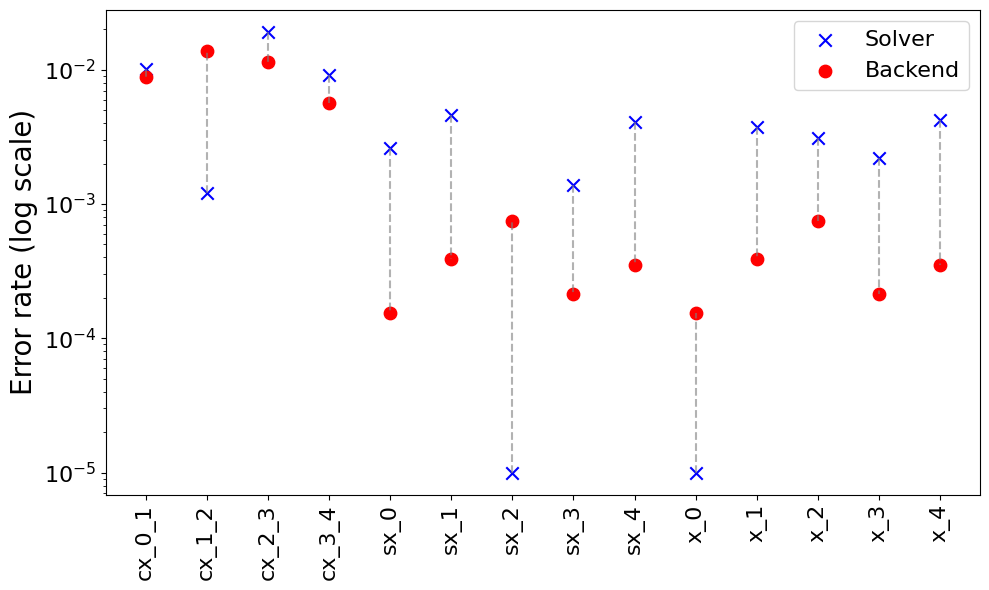

Single-qubit accuracies: {'sx_0': 0.0, 'sx_1': 0.0, 'sx_2': 0.013408331188138112, 'sx_3': 0.0, 'sx_4': 0.0, 'x_0': 0.06448869470689877, 'x_1': 0.0, 'x_2': 0.0, 'x_3': 0.0, 'x_4': 0.0}
Two-qubit accuracies: {'cx_0_1': 0.8449337345353078, 'cx_1_2': 0.08691771182051133, 'cx_2_3': 0.3138755762205393, 'cx_3_4': 0.39260537917856797}
Stats: {'single_mean': 0.007789702589503689, 'single_min': 0.0, 'single_max': 0.06448869470689877, 'two_mean': 0.40958310043873164, 'two_min': 0.08691771182051133, 'two_max': 0.8449337345353078}


In [35]:
# ----------------- comparison function -----------------
def compare_error_values(all_solutions, backend, tol=1e-6, plot=True, compute_accuracy=True):
    """
    Compare one or more solutions (list of dicts) against backend error values.
    Returns a list of tuples:
      (matches, mismatches, missing, accuracies, single_acc, two_acc, stats)
    """
    def get_backend_val(gate, qubits):
        # Special handling: map 'ecr' to 'cx' if backend doesn't have ecr
        try:
            return backend.properties().gate_error(gate, qubits)
        except:
            if gate == "ecr":
                try:
                    return backend.properties().gate_error("cx", qubits)
                except:
                    return None
            return None

    results = []

    if isinstance(all_solutions, dict):  # wrap single dict in list
        all_solutions = [all_solutions]

    for sol in all_solutions:
        matches, mismatches, missing = {}, {}, {}
        accuracies = {}
        single_qubit_acc = {}
        two_qubit_acc = {}

        for key, val in sol.items():
            clean_key = key[4:] if key.startswith("eps_") else key
            parts = clean_key.split("_")
            gate = parts[0]
            qubits = tuple(map(int, parts[1:])) if len(parts) > 1 else ()

            backend_val = get_backend_val(gate, qubits)

            if backend_val is None:
                # excluded from all accuracy/statistics calculations
                missing[key] = val
                continue  

            # if backend value exists → compare
            if abs(val - backend_val) <= tol:
                matches[key] = (val, backend_val)
            else:
                mismatches[key] = (val, backend_val)

            if compute_accuracy:
                acc = 1 - abs(val - backend_val) / (backend_val if backend_val != 0 else 1e-12)
                acc = max(0.0, min(1.0, acc))
                accuracies[key] = acc

                if len(qubits) == 1:
                    single_qubit_acc[key] = acc
                elif len(qubits) == 2:
                    two_qubit_acc[key] = acc

        # --- compute stats ---
        stats = {}
        for label, group in [("single", single_qubit_acc), ("two", two_qubit_acc)]:
            if group:
                vals = np.array(list(group.values()))
                stats[f"{label}_mean"] = float(np.mean(vals))
                stats[f"{label}_min"] = float(np.min(vals))
                stats[f"{label}_max"] = float(np.max(vals))
            else:
                stats[f"{label}_mean"] = None
                stats[f"{label}_min"] = None
                stats[f"{label}_max"] = None

        results.append((matches, mismatches, missing, accuracies, single_qubit_acc, two_qubit_acc, stats))

    if plot:
        plot_error_comparison(results)

    return results


# ----------------- plotting function -----------------
def plot_error_comparison(results):
    """
    Plot solver vs backend error rates for all solutions (log scale).
    Missing backend values are marked in orange.
    """
    for i, (matches, mismatches, missing, accuracies, single_qubit_acc, two_qubit_acc, stats) in enumerate(results):
        fig, ax = plt.subplots(figsize=(10, 6))

        keys = []
        solver_vals = []
        backend_vals = []
        missing_keys = []

        # matches + mismatches
        combined = {**matches, **mismatches}
        for k, (s, b) in combined.items():
            keys.append(k)
            solver_vals.append(s)
            backend_vals.append(b)

        # missing backend points
        for k, s in missing.items():
            keys.append(k)
            solver_vals.append(s)
            backend_vals.append(None)
            missing_keys.append(len(keys)-1)

        x = np.arange(len(keys))

        # Solver points
        ax.scatter(x, solver_vals, color='blue', marker='x', s=80, label='Solver')

        # Backend points where available
        for xi, b in enumerate(backend_vals):
            if b is not None:
                ax.scatter(xi, b, color='red', marker='o', s=80, label='Backend' if xi==0 else "")
                ax.plot([xi, xi], [solver_vals[xi], b], color='gray', linestyle='--', alpha=0.6)

        # Highlight missing backend points
        # if missing_keys:
        #     ax.scatter([x[k] for k in missing_keys],
        #                [solver_vals[k] for k in missing_keys],
        #                color='orange', marker='o', s=80, label='Missing backend')

        ax.set_yscale("log")
        ax.set_ylabel("Error rate (log scale)",fontsize=20)
        ax.set_xticks(x)
        ax.set_xticklabels(keys, rotation=90,fontsize=16)
        ax.tick_params(axis='y', labelsize=16)                  # bigger ytick labels
        ax.legend(fontsize=16) 
        plt.tight_layout()
        plt.show()

# sol is your single solution dict from least_squares
comparison_results = compare_error_values(sol, backend, tol=1e-6)

matches, mismatches, missing, accuracies, single_acc, two_acc, stats = comparison_results[0]

print("Single-qubit accuracies:", single_acc)
print("Two-qubit accuracies:", two_acc)
print("Stats:", stats)


In [26]:
def compare_error_values(all_solutions, backend, tol=1e-6, plot=True):
    """
    Compare one or more solutions (list of dicts) against backend error values.
    Returns a list of (matches, mismatches, missing) for each solution.
    """
    
    def get_cnot_qubits(backend, qubit_index):
        """
        Helper function to get actual CNOT qubit pairs from backend topology.
        """
        # Get the backend coupling map
        coupling_map = backend.configuration().coupling_map
        
        # Find all CNOT gates involving the given qubit
        for gate in coupling_map:
            if qubit_index in gate:
                return tuple(gate)
        
        return (qubit_index,)  # Fallback
    
    results = []
    for sol in all_solutions:
        matches, mismatches, missing = {}, {}, {}
        
        for key, sym_val in sol.items():
            # Example: key = "eps_cx_0" or "eps_u2_1"
            # Remove the "eps_" prefix
            if key.startswith('eps_'):
                clean_key = key[4:]  # Remove "eps_" prefix
            else:
                clean_key = key
            
            # Now split the clean key
            parts = clean_key.split("_")
            gate = parts[0]
            
            # Map gate names to backend expected names
            gate_mapping = {
                'cx': 'cx',
                'sx': 'sx',
                'x':'x'
            }
            
            if gate in gate_mapping:
                backend_gate = gate_mapping[gate]
            else:
                backend_gate = gate
            
            # Get qubit indices
            if len(parts) > 1:
                try:
                    qubits = tuple(map(int, parts[1:]))
                except ValueError:
                    qubits = tuple(parts[1:])
            else:
                qubits = ()
            
            # For two-qubit gates, handle them appropriately
            if backend_gate in ['cx', 'cy'] and len(qubits) == 1:
                # If we have "cx_0", try to find the actual CNOT pair
                qubits = get_cnot_qubits(backend, qubits[0])
            
            try:
                backend_val = backend.properties().gate_error(backend_gate, qubits)
            except Exception as e:
                # print(f"Error getting {backend_gate} error for qubits {qubits}: {e}")
                backend_val = None

            if backend_val is None:
                missing[key] = sym_val
            else:
                if abs(sym_val - backend_val) <= tol:
                    matches[key] = (sym_val, backend_val)
                else:
                    mismatches[key] = (sym_val, backend_val)

        results.append((matches, mismatches, missing))

    if plot:
        plot_error_comparison(results)

    return results

properties = backend.properties()
backend_errors = {}
for gate in properties.gates:
    name = gate.gate
    qubits = "_".join(str(q) for q in gate.qubits)
    key = f"{name}_{qubits}"
    backend_errors[key] = gate.parameters[0].value
# ------------------------ Example Usage ------------------------
# Assume you already have:
# 1. `variables` : list of variable names like ["cx(0,1)", "sx(0,)", ...]
# 2. `result` : the output from least_squares (result.x)
# 3. `backend` : your IBM backend object

# Wrap the solver output into a list
solver_dict = {var: val for var, val in zip(variables, result.x)}

# Wrap it in a list
all_solutions = [solver_dict]

# Now call compare_error_values
comparison_results = compare_error_values(all_solutions, backend_errors, tol=1e-6, plot=True)

# Inspect detailed results
matches, mismatches, missing = comparison_results[0]


print("=== Matches ===")
for key, (solver_val, backend_val) in matches.items():
    print(f"{key}: Solver={solver_val:.6e}, Backend={backend_val:.6e}")

print("\n=== Mismatches ===")
for key, (solver_val, backend_val) in mismatches.items():
    print(f"{key}: Solver={solver_val:.6e}, Backend={backend_val:.6e}")

print("\n=== Missing in Backend ===")
for key, solver_val in missing.items():
    print(f"{key}: Solver={solver_val:.6e} (not found in backend)")


NameError: name 'variables' is not defined

In [46]:
import matplotlib.pyplot as plt

def plot_error_comparison(matches, mismatches):
    """
    Plot symbolic vs backend error values with y=x reference line.
    Shows symbolic and backend values in different colors.
    """
    sym_vals, back_vals = [], []
    labels = []

    for k, (sym, back, cand) in {**matches, **mismatches}.items():
        sym_vals.append(sym)
        back_vals.append(back)
        labels.append(k)

    # Scatter for symbolic errors
    plt.figure(figsize=(12,6))
    plt.scatter(range(len(sym_vals)), sym_vals, color="blue", marker="o", label="Derived ε")

    # Scatter for backend errors
    plt.scatter(range(len(back_vals)), back_vals, color="red", marker="x", label="Actual ε")

    # Reference y=x line is not meaningful here (since we plot index vs values),
    # but we can instead connect symbolic & backend pairs with lines:
    for i in range(len(sym_vals)):
        plt.plot([i, i], [sym_vals[i], back_vals[i]], color="gray", linestyle="--", alpha=0.6)

    # Labels and formatting
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel("Error values")
    plt.title("Actual vs Derived Error Values")
    plt.yscale("log")   # 🔑 Set y-axis to log scale

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
print(missing)
matches, mismatches, missing = compare_error_values(solution, backend)

plot_error_comparison(matches, mismatches)


{}


NameError: name 'solution' is not defined

In [48]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import state_fidelity
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler

# --- Example double slit circuit ---


# Create a classical register and add it to the circuit
cr = ClassicalRegister(1, name='c')
qc.add_register(cr)

# Measure qubit 1 into the classical bit 0 of 'c'
qc.measure(1, cr[0])


# Transpile to ISA for backend


CircuitError: 'register name "c" already exists'

C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\2653484263.py:347: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name == 'swap':
C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\2653484263.py:353: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if len(instruction[1]) == 2:
C:\Users\rupsh\AppData\Local\Temp\ipykernel_26488\2653484263.py:355: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  qubits = [qarg for qarg in instruction[1]]


{(62, 72), (67, 68), (44, 45), (99, 100), (8, 9), (40, 41), (17, 30), (100, 101), (91, 98), (100, 110), (41, 42), (55, 68), (9, 10), (49, 55), (106, 107), (47, 48), (42, 43), (107, 108), (73, 85), (38, 39), (20, 33), (48, 49), (103, 104), (80, 81), (66, 73), (85, 86), (81, 82), (110, 118), (16, 26), (118, 119), (22, 23), (77, 78), (49, 50), (104, 105), (45, 46), (50, 51), (105, 106), (72, 81), (82, 83), (46, 47), (23, 24), (78, 79), (83, 84), (19, 20), (24, 25), (79, 80), (56, 57), (93, 106), (20, 21), (12, 17), (41, 53), (57, 58), (87, 93), (30, 31), (25, 26), (79, 91), (26, 27), (21, 22), (58, 71), (31, 32), (4, 15), (86, 87), (104, 111), (27, 28), (34, 43), (64, 65), (119, 120), (54, 64), (32, 36), (5, 6), (60, 61), (87, 88), (97, 98), (28, 29), (45, 54), (36, 51), (88, 89), (120, 121), (15, 22), (24, 34), (84, 85), (29, 30), (61, 62), (70, 74), (121, 122), (62, 63), (117, 118), (37, 52), (3, 4), (58, 59), (33, 39), (68, 69), (63, 64), (71, 77), (111, 122), (4, 5), (59, 60), (69, 70

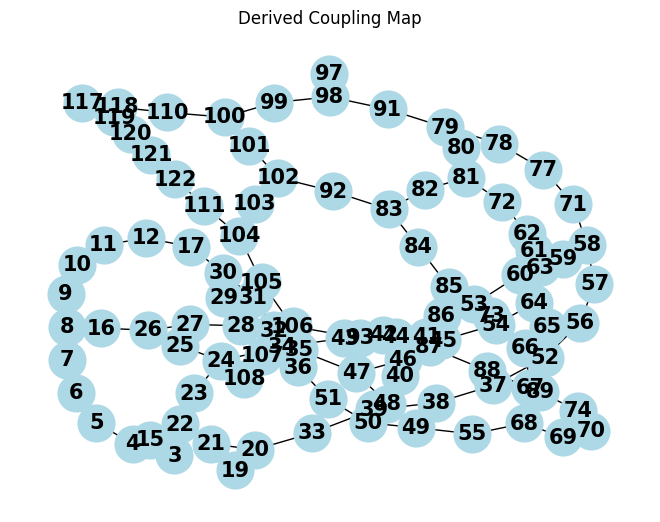

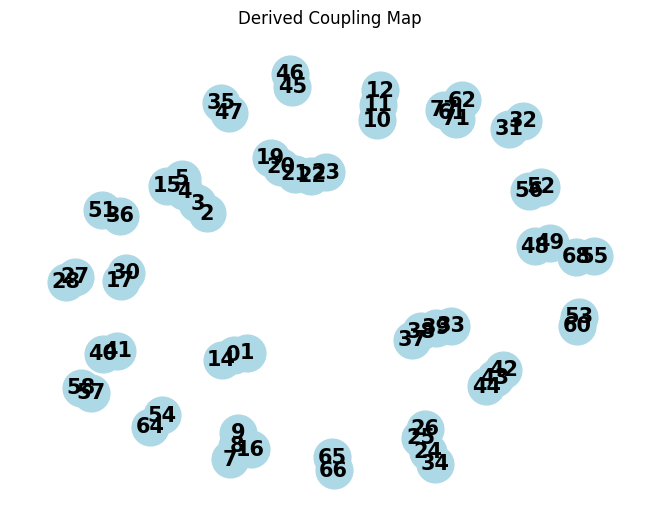

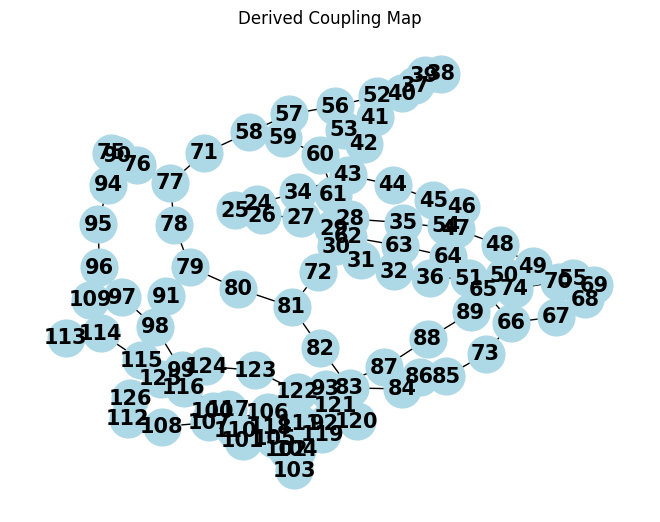

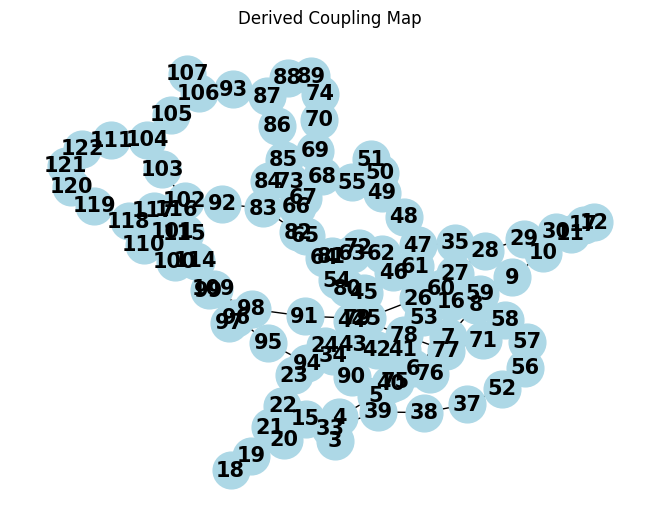

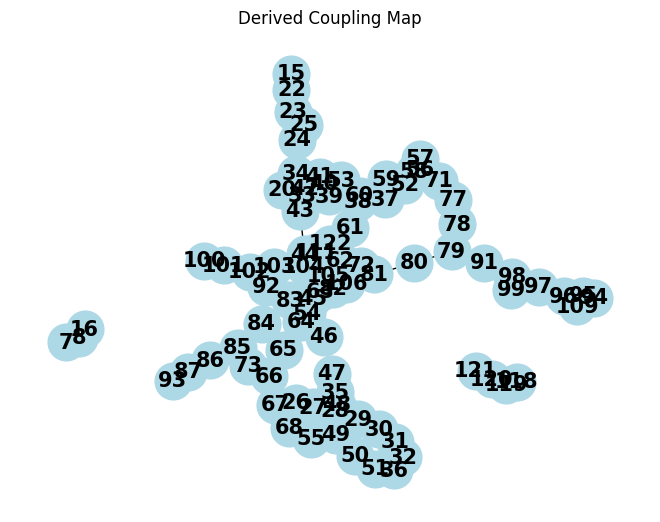

In [76]:
from qiskit.circuit.random import random_circuit
random_circ = random_circuit(num_qubits=100, depth=5, max_operands=2)
random_circ= transpile(random_circ, backend=backend, seed_transpiler=42)

big_rc= derive_coupling_map_from_circuit(random_circ)
print(big_rc)
plot_coupling_map(big_rc)

random_circ = random_circuit(num_qubits=100, depth=5, max_operands=2)
random_circ= transpile(random_circ, backend=backend, seed_transpiler=40)

big_rc_2= derive_coupling_map_from_circuit(random_circ)
plot_coupling_map(big_rc_2)

random_circ = random_circuit(num_qubits=100, depth=5, max_operands=2)
random_circ= transpile(random_circ, backend=backend, seed_transpiler=43)

big_rc_3= derive_coupling_map_from_circuit(random_circ)
plot_coupling_map(big_rc_3)

random_circ = random_circuit(num_qubits=100, depth=5, max_operands=2)
random_circ= transpile(random_circ, backend=backend, seed_transpiler=52)

big_rc_4= derive_coupling_map_from_circuit(random_circ)
plot_coupling_map(big_rc_4)

random_circ = random_circuit(num_qubits=100, depth=5, max_operands=2)
random_circ= transpile(random_circ, backend=backend, seed_transpiler=49)

big_rc_5= derive_coupling_map_from_circuit(random_circ)
plot_coupling_map(big_rc_5)


Qubit Pair  Count  Rank
     40_41      5     1
     55_68      5     1
     42_43      5     1
     38_39      5     1
     48_49      5     1
     45_46      5     1
     24_25      5     1
     57_58      5     1
     27_28      5     1
     54_64      5     1
     24_34      5     1
     61_62      5     1
     71_77      5     1
     35_47      5     1
     65_66      5     1
     37_38      5     1
     43_44      5     1
     52_56      5     1
     53_60      5     1
     62_72      4     2
     67_68      4     2
     44_45      4     2
   100_101      4     2
     91_98      4     2
     41_42      4     2
     49_55      4     2
     47_48      4     2
     73_85      4     2
   103_104      4     2
     80_81      4     2
     66_73      4     2
     85_86      4     2
     81_82      4     2
   118_119      4     2
     22_23      4     2
     77_78      4     2
     49_50      4     2
   104_105      4     2
     50_51      4     2
   105_106      4     2
     72_81      

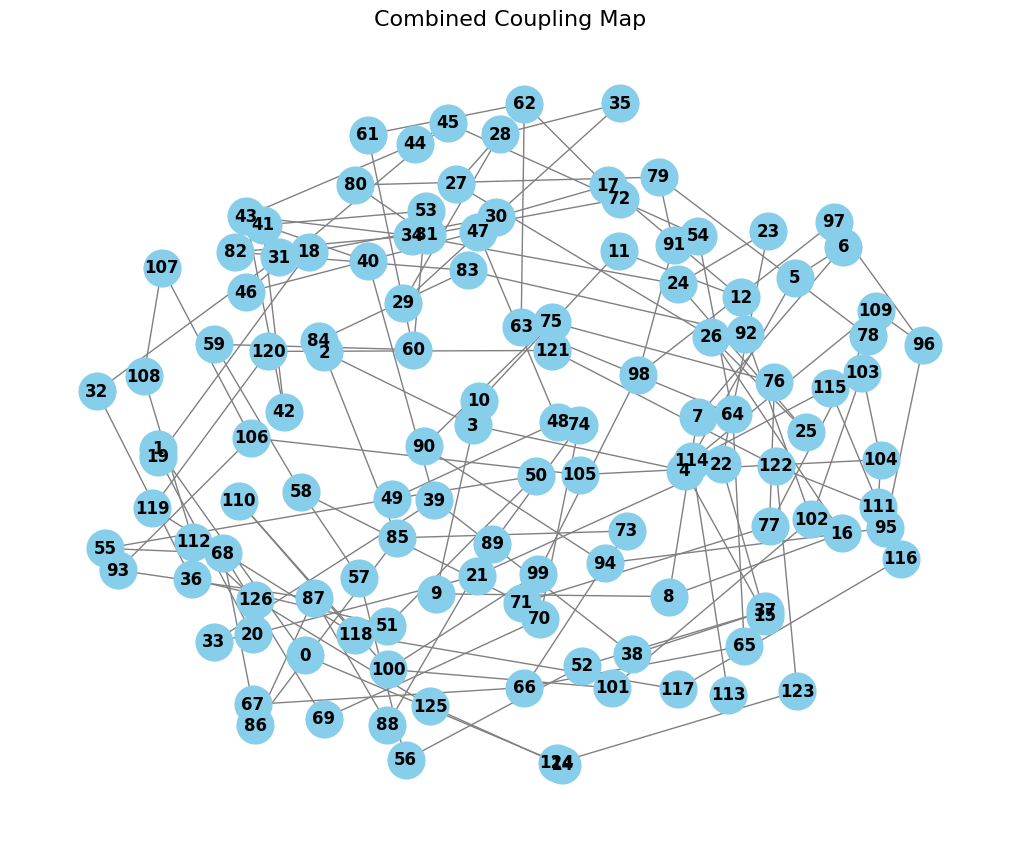

{(62, 72), (67, 68), (44, 45), (99, 100), (108, 112), (8, 9), (40, 41), (0, 14), (17, 30), (100, 101), (91, 98), (100, 110), (75, 90), (41, 42), (96, 97), (18, 19), (55, 68), (9, 10), (49, 55), (106, 107), (47, 48), (42, 43), (107, 108), (73, 85), (38, 39), (20, 33), (48, 49), (103, 104), (80, 81), (75, 76), (66, 73), (85, 86), (81, 82), (110, 118), (16, 26), (90, 94), (118, 119), (22, 23), (77, 78), (49, 50), (104, 105), (114, 115), (45, 46), (50, 51), (105, 106), (72, 81), (82, 83), (46, 47), (23, 24), (78, 79), (83, 84), (115, 116), (19, 20), (24, 25), (79, 80), (56, 57), (93, 106), (116, 117), (20, 21), (12, 17), (41, 53), (57, 58), (87, 93), (30, 31), (25, 26), (79, 91), (26, 27), (21, 22), (58, 71), (31, 32), (4, 15), (86, 87), (113, 114), (104, 111), (123, 124), (27, 28), (34, 43), (64, 65), (119, 120), (54, 64), (32, 36), (5, 6), (60, 61), (87, 88), (97, 98), (112, 126), (28, 29), (45, 54), (36, 51), (88, 89), (120, 121), (15, 22), (24, 34), (84, 85), (29, 30), (61, 62), (70, 7

In [77]:
import networkx as nx
import matplotlib.pyplot as plt
coupling_maps=[]
# Define the derived coupling maps as lists of tuples (edges)
# Assuming derived_map_grover_l, derived_map_t_qft, derived_map_t_1bit, derived_map_1bit_adder are defined
coupling_maps.append(big_rc_5)
coupling_maps.append(big_rc_4)
coupling_maps.append(big_rc_2)
coupling_maps.append(big_rc_3)
coupling_maps.append(big_rc)

# coupling_maps.append(derived_map_mod5)
# coupling_maps.append(derived_map_1bit_adder)
# coupling_maps.append(derived_map_qft)
# coupling_maps.append(derived_map_grover)
# coupling_maps.append(derived_map_ghz)
# coupling_maps.append(derived_map_4mod7)
# coupling_maps.append(derived_map_one23)
# coupling_maps.append(derived_map_4gt4)
# coupling_maps.append(derived_map_4gt11)
# coupling_maps.append(derived_map_mod5mils)
# coupling_maps.append(derived_map_4gt13)
# coupling_maps.append(derived_map_4gt12)
# coupling_maps.append(derived_map_ghz_big)
# coupling_maps.append(derived_map_ghz_big_2)
# coupling_maps.append(derived_map_ghz_big_3)
# coupling_maps.append(derived_map_ghz_big_4)
# coupling_maps.append(derived_map_ghz_big_5)
# coupling_maps.append(derived_map_ghz_big_6)
# coupling_maps.append(derived_map_grover_big_2)
# coupling_maps.append(derived_map_grover_big)
# coupling_maps.append(derived_map_grover_big_3)
# coupling_maps.append(derived_map_grover_big_4)
# coupling_maps.append(derived_map_grover_big_5)
# coupling_maps.append(derived_map_grover_big_6)
# coupling_maps.append(derived_map_qft_big_2)
# coupling_maps.append(derived_map_qft_big)
# coupling_maps.append(derived_map_qft_big_3)
# coupling_maps.append(derived_map_qft_big_4)
# coupling_maps.append(derived_map_qft_big_5)
# coupling_maps.append(derived_map_qft_big_6)
# coupling_maps.append(derived_map_rc_4)
# coupling_maps.append(derived_map_rc_5)
# coupling_maps.append(derived_map_rc_6)
# coupling_maps.append(derived_map_rc_7)
# coupling_maps.append(derived_map_rc_8)
# coupling_maps.append(derived_map_rc_9)
# coupling_maps.append(derived_map_rc_10)
# coupling_maps.append(derived_map_rc_11)
# coupling_maps.append(derived_map_rc_12)
# coupling_maps.append(derived_map_rc_14)
# coupling_maps.append(derived_map_rc_15)

from collections import Counter
import pandas as pd

# Flatten the list of edges from all coupling maps
all_edges = [edge for cmap in coupling_maps for edge in cmap]

# Count occurrences of each edge
edge_counts = Counter(all_edges)

# Sort edges by count in descending order
sorted_edges = sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)

# Assign ranks correctly
ranked_edges = []
current_rank = 0  # The displayed rank
prev_count = None  # Track previous count

for edge, count in sorted_edges:
    if prev_count is None or count < prev_count:
        current_rank = current_rank + 1  # Ensure consecutive ranking
    
    ranked_edges.append(("{}_{}".format(edge[0], edge[1]), count, current_rank))
    prev_count = count  # Update previous count

# Create a DataFrame for structured output
df = pd.DataFrame(ranked_edges, columns=["Qubit Pair", "Count", "Rank"])

# Print formatted table
print(df.to_string(index=False))
# coupling_maps.append(derived_map_rc)
# all_edges = [edge for cmap in coupling_maps for edge in cmap]

# # Count occurrences of each edge
# edge_counts = Counter(all_edges)
# sorted_edges = sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)

# # Print all ranked edges
# rank = 1
# prev_count = None
# ranked_edges = {}

# for i, (edge, count) in enumerate(sorted_edges):
#     if count != prev_count:
#         rank = i + 1  # Update rank only when count changes
#     if rank not in ranked_edges:
#         ranked_edges[rank] = []
#     ranked_edges[rank].append(edge)
#     prev_count = count

# # Print edges grouped by rank
# for rank, edges in ranked_edges.items():
#     print(f"Rank {rank}: {edges}")
# most_common_edges = edge_counts.most_common()

# # First most frequent edge
# if len(most_common_edges) > 0:
#     print("Most Frequent Edge:", most_common_edges[0][0], "with count:", most_common_edges[0][1])

# # Second most frequent edge (next in order)
# if len(most_common_edges) > 1:
#     print("Second Most Frequent Edge:", most_common_edges[1][0], "with count:", most_common_edges[1][1])

# # Third most frequent edge (if needed)
# if len(most_common_edges) > 2:
#     print("Third Most Frequent Edge:", most_common_edges[2][0], "with count:", most_common_edges[2][1])
    
combined_coupling_map = big_rc|big_rc_4|big_rc_2|big_rc_3|big_rc_5
#derived_map_ghz_big|derived_map_ghz_big_2|derived_map_ghz_big_3|derived_map_ghz_big_4|derived_map_ghz_big_5|derived_map_ghz_big_6|derived_map_grover_big|derived_map_grover_big_2|derived_map_grover_big_3|derived_map_grover_big_4|derived_map_grover_big_5|derived_map_grover_big_6|derived_map_qft_big|derived_map_qft_big_2|derived_map_qft_big_3|derived_map_qft_big_4|derived_map_qft_big_5|derived_map_qft_big_6
# combined_coupling_map = filtered_edges_ghz_big|filtered_edges_qft_big|filtered_edges_grover_big|filtered_edges_rc_6|filtered_edges_grover_big_2#|filtered_edges_rc_7|filtered_edges_grover_big_3 
#derived_map_rc_4|derived_map_rc_6
#filtered_edges_4mod7|filtered_edges_mod54
#|filtered_edges_4gt12|filtered_edges_4gt11|filtered_edges_rc_s_3|filtered_edges_rc_s_2|filtered_edges_rc_s|filtered_edges_rc_s_6|filtered_edges_rc_s_5|filtered_edges_rc_s_4

#filtered_edges_qft_big|filtered_edges_ghz_big|filtered_edges_grover_big|filtered_edges_ghz_big_2|filtered_edges_grover_big_2|filtered_edges_qft_big_2|filtered_edges_qft_big_3|filtered_edges_grover_big_3|filtered_edges_ghz_big_3|filtered_edges_ghz_big_4|filtered_edges_grover_big_4|filtered_edges_qft_big_4|filtered_edges_qft_big_5|filtered_edges_grover_big_5|filtered_edges_ghz_big_5|filtered_edges_qft_big_6|filtered_edges_grover_big_6|filtered_edges_ghz_big_6
#filtered_edges_rc_3|filtered_edges_rc|filtered_edges_rc_2|filtered_edges_rc_6|filtered_edges_rc_5|filtered_edges_rc_4|filtered_edges_rc_7|filtered_edges_rc_8|filtered_edges_rc_9|filtered_edges_rc_12|filtered_edges_rc_10|filtered_edges_rc_11|filtered_edges_rc_15|filtered_edges_rc_13|filtered_edges_rc_14|filtered_edges_rc_16|filtered_edges_rc_18|filtered_edges_rc_17
#filtered_edges_1bit|filtered_edges_mod54|filtered_edges_qft|filtered_edges_ghz|filtered_edges_grover|filtered_edges_one23|filtered_edges_4gt13|c|filtered_edges_4mod7|filtered_edges_4gt12|filtered_edges_4gt11|filtered_edges_rc_s_3|filtered_edges_rc_s_2|filtered_edges_rc_s|filtered_edges_rc_s_6|filtered_edges_rc_s_5|filtered_edges_rc_s_4
# # |filtered_edges_4gt11|filtered_edges_4gt12|filtered_edges_4gt13
# |derived_map_rc|derived_map_rc_3|derived_map_rc_2
# |derived_map_rc_17|derived_map_rc_18|derived_map_rc_16
# combined_coupling_map = derived_map_rc_5| derived_map_rc_4|derived_map_rc_6|derived_map_rc_7|derived_map_rc_8|derived_map_rc_9|derived_map_rc_11|derived_map_rc_10|derived_map_rc_12|derived_map_rc_13|derived_map_rc_14|derived_map_rc_15
G = nx.Graph()
G.add_edges_from(combined_coupling_map)

# Use a layout to minimize edge overlap
pos = nx.spring_layout(G, seed=42, k=0.5)  # Adjust 'k' for spacing; increase it for more space

plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=700, edge_color='gray', font_size=12, font_weight='bold')
plt.title('Combined Coupling Map', fontsize=16)
plt.axis('off')  # Turn off the axis for better visibility
plt.show()

# Print the combined coupling map
print(combined_coupling_map)


In [78]:
import numpy as np
from scipy.spatial.distance import hamming

def convert_to_graph(edge_set):
    graph = nx.Graph()
    graph.add_edges_from(edge_set)
    return graph

def normalize_graph(graph, n_qubits):
    # Extract all nodes (qubits) and create a mapping to the normalized range
    qubits = sorted(graph.nodes())
    qubit_mapping = {q: i for i, q in enumerate(qubits)}  # Map original qubits to [0, len(qubits)-1]
    
    # Create a normalized adjacency matrix
    matrix = np.zeros((n_qubits, n_qubits))
    
    for edge in graph.edges():
        # Map edges to the normalized qubit indices
        normalized_edge = (qubit_mapping[edge[0]], qubit_mapping[edge[1]])
        matrix[normalized_edge[0], normalized_edge[1]] = 1
        matrix[normalized_edge[1], normalized_edge[0]] = 1  # Assuming undirected graph
    return matrix

def hamming_distance_normalized(graph1, graph2, n_qubits):
    # Normalize both graphs
    adj_matrix1 = normalize_graph(graph1, n_qubits)
    adj_matrix2 = normalize_graph(graph2, n_qubits)
    
    # Flatten the matrices and compute Hamming distance
    flat1 = adj_matrix1.flatten()
    flat2 = adj_matrix2.flatten()
    return hamming(flat1, flat2) * len(flat1)
coupling_map = backend.configuration().coupling_map

# coupling_map = [
#     # Horizontal connections (↔) on Row 1
#     (0, 1), (1, 2), (2, 3), (3, 4),
#     # Horizontal connections (↔) on Row 2
#     (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15),
#     # Horizontal connections (↔) on Row 3
#     (19, 20), (20, 21), (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27),

#     # Vertical connections (↕)
#     (0, 5), (5, 9),  # First column
#     (4, 6), (6, 13),  # Fifth column

#     (7, 16), (19, 16),  # First column in Row 2 to Row 3
#     (11, 17), (23, 17),  # Fifth column in Row 2 to Row 3
#     (15, 18), (27, 18) # Connection from Row 2 to Row 3 (column 9)
# ]

# Example usage
graph1 = convert_to_graph(coupling_map)
graph2 = convert_to_graph(combined_coupling_map)

# n_qubits = 28
# hamming_dist_20 = hamming_distance_normalized(graph1, graph2, n_qubits)
# print(f"Hamming Distance between the two loop graphs for 20 qubits: {hamming_dist_20}")

# graph1_new = convert_to_graph(derived_map_grover_loop)
# graph2_new = convert_to_graph(loop_15)

# n_qubits = 15
# hamming_dist_15 = hamming_distance_normalized(graph1_new, graph2_new, n_qubits)
# print(f"Hamming Distance between the two loop graphs for 15 qubits: {hamming_dist_15}")


# Define the first coupling map
# Create graphs
G_a = nx.Graph()
G_a.add_edges_from(coupling_map)

G_b = nx.Graph()
G_b.add_edges_from(combined_coupling_map)

# Find missing edges from A in B
missing_from_a_to_b = [edge for edge in G_a.edges() if edge not in G_b.edges()]
missing_from_b_to_a = [edge for edge in G_b.edges() if edge not in G_a.edges()]

# Count of missing edges
count_missing_from_a_to_b = len(missing_from_a_to_b)
count_missing_from_b_to_a = len(missing_from_b_to_a)

# Output results
print(f"Number of connections in A missing from B: {count_missing_from_a_to_b}")
print(f"Number of connections in B missing from A: {count_missing_from_b_to_a}")




Number of connections in A missing from B: 3
Number of connections in B missing from A: 0


In [ ]:
properties = backend.properties()
print(properties.to_dict())


{'backend_name': 'ibm_kyiv', 'backend_version': '1.20.22', 'last_update_date': datetime.datetime(2025, 2, 25, 9, 39, 1, tzinfo=tzlocal()), 'qubits': [[{'date': datetime.datetime(2025, 2, 24, 22, 16, 29, tzinfo=tzlocal()), 'name': 'T1', 'unit': 'us', 'value': 458.5349722777456}, {'date': datetime.datetime(2025, 2, 24, 22, 16, 47, tzinfo=tzlocal()), 'name': 'T2', 'unit': 'us', 'value': 530.6191512423914}, {'date': datetime.datetime(2025, 2, 25, 9, 39, 1, tzinfo=tzlocal()), 'name': 'frequency', 'unit': 'GHz', 'value': 4.655634914476918}, {'date': datetime.datetime(2025, 2, 25, 9, 39, 1, tzinfo=tzlocal()), 'name': 'anharmonicity', 'unit': 'GHz', 'value': -0.3110632460863657}, {'date': datetime.datetime(2025, 2, 25, 1, 9, 15, tzinfo=tzlocal()), 'name': 'readout_error', 'unit': '', 'value': 0.005615234375}, {'date': datetime.datetime(2025, 2, 25, 1, 9, 9, tzinfo=tzlocal()), 'name': 'prob_meas0_prep1', 'unit': '', 'value': 0.0068359375}, {'date': datetime.datetime(2025, 2, 25, 1, 9, 12, tzinf

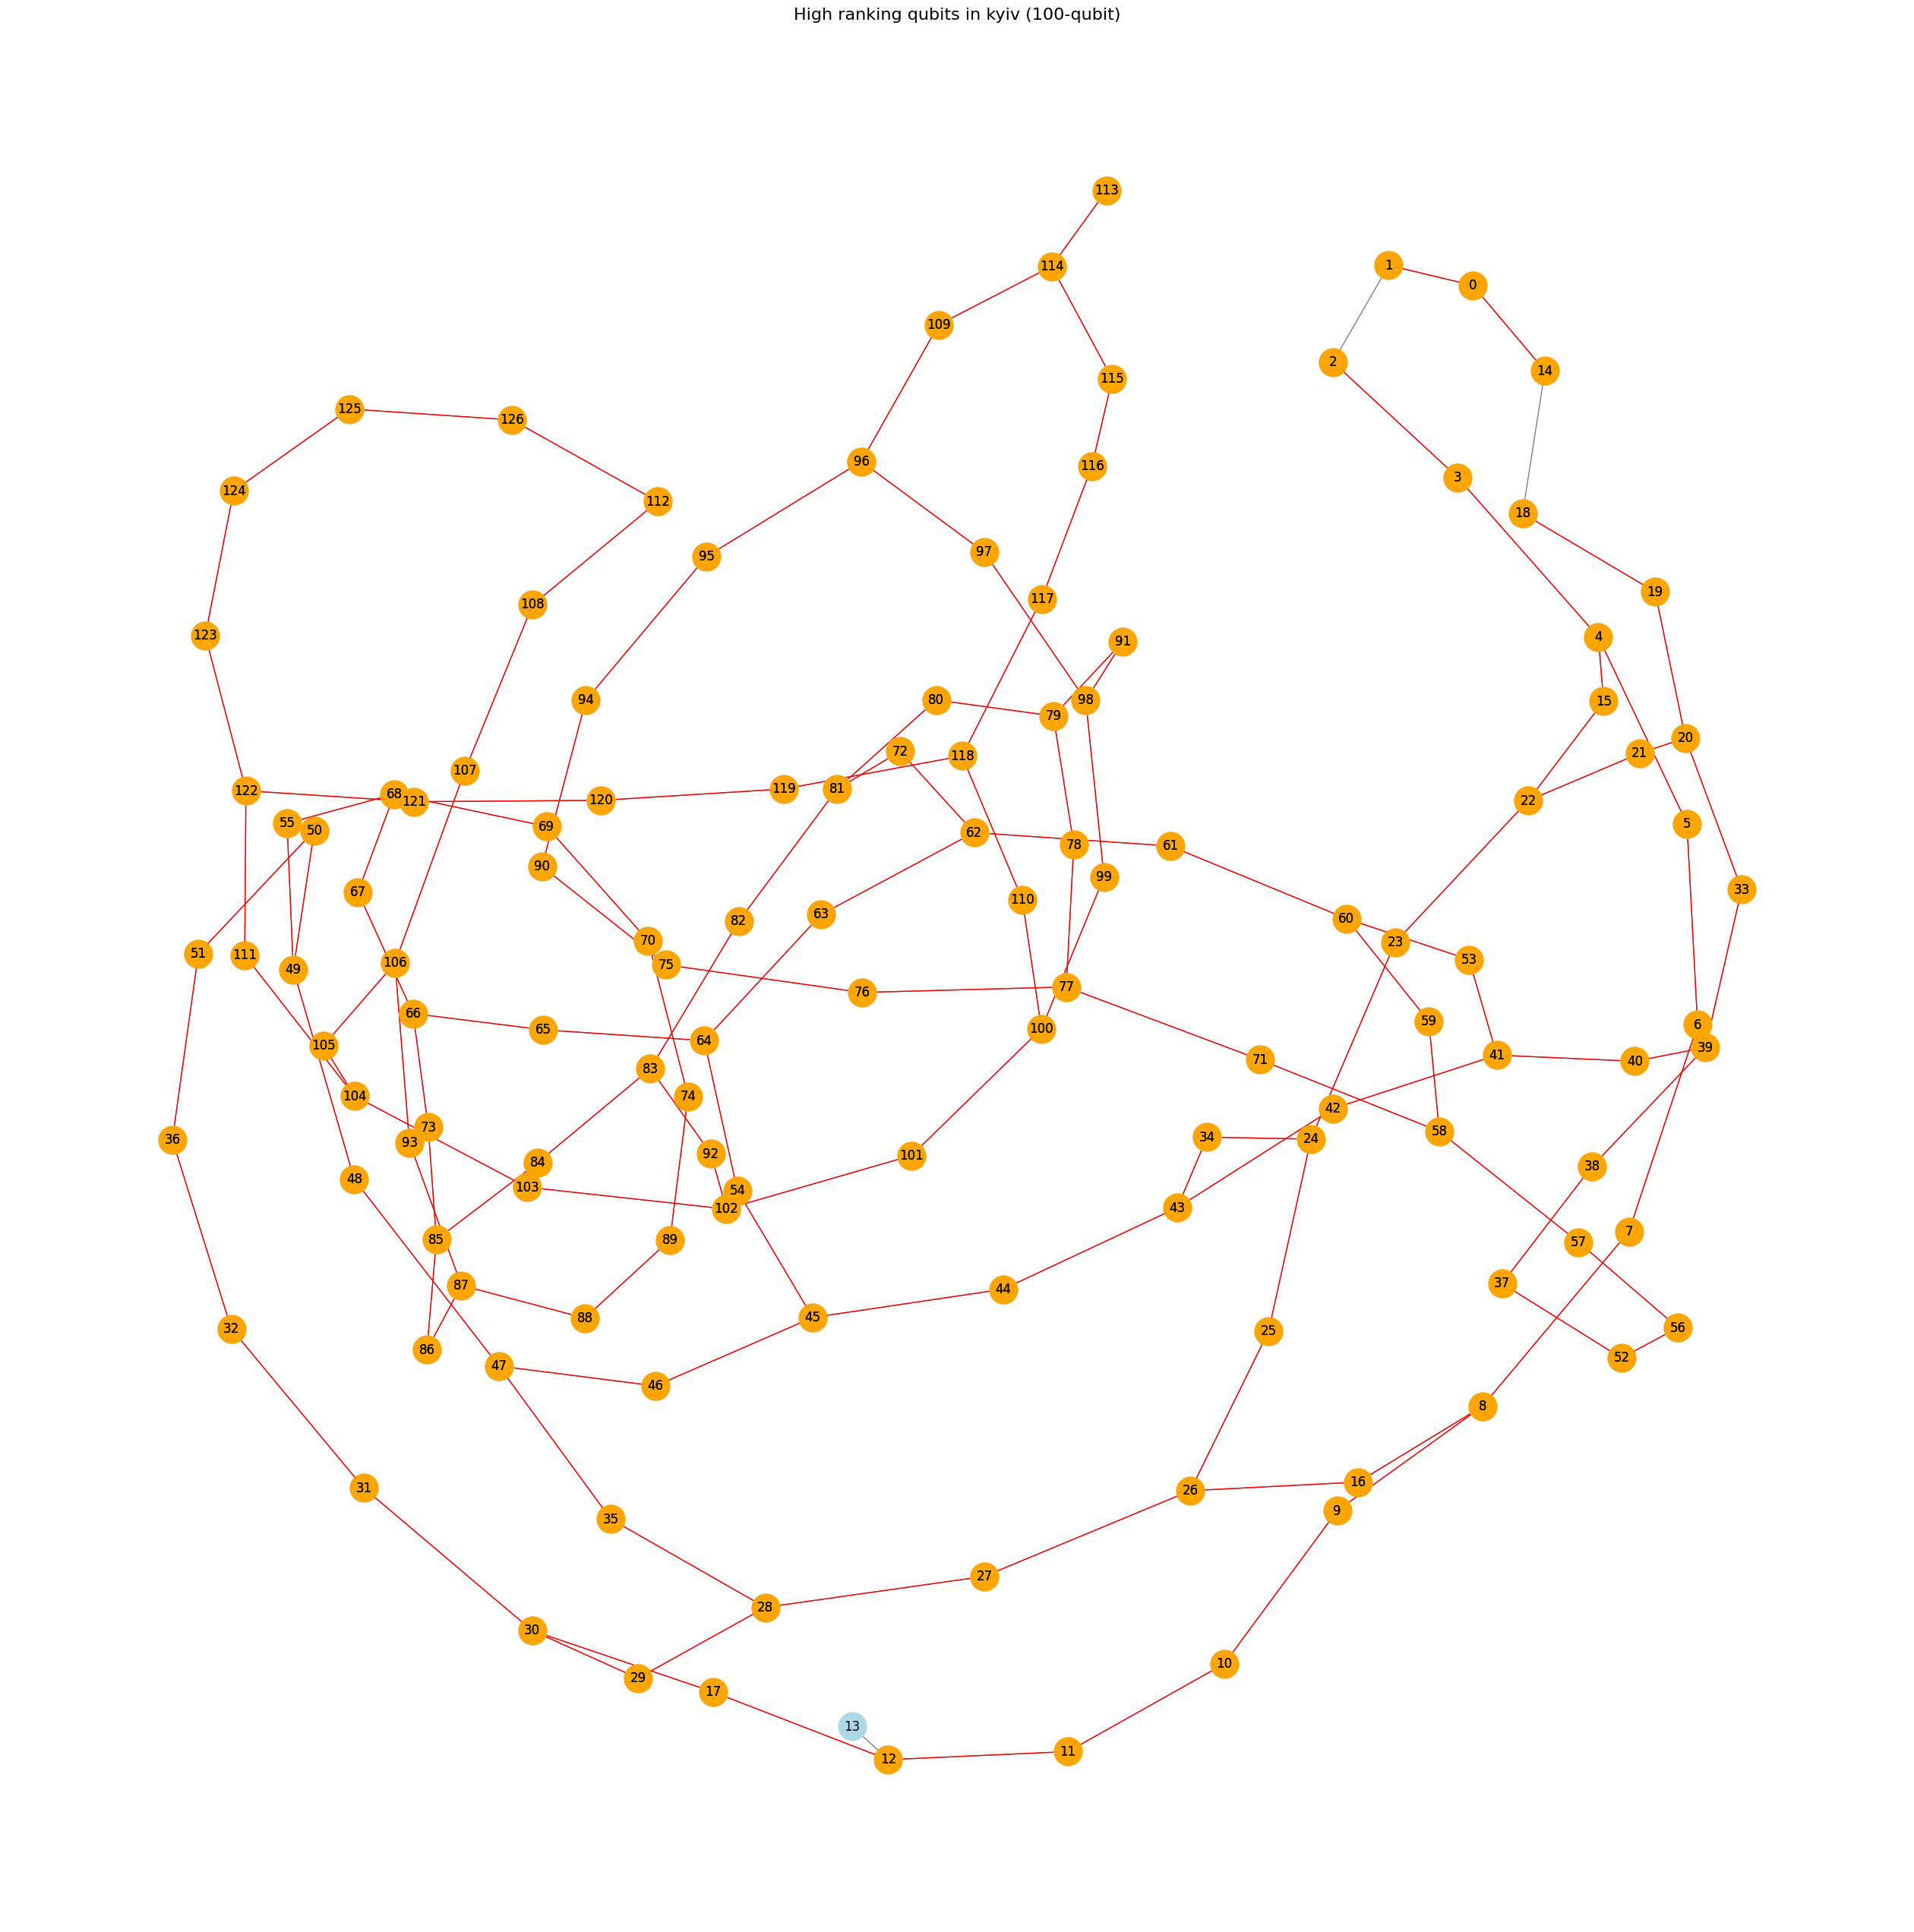

In [79]:
import networkx as nx
import matplotlib.pyplot as plt

# Define two coupling maps as lists of tuples (edges)
# Replace these with your actual coupling maps
# layout = backend.configuration().qubit_coordinates
combined_coupling_map = set()
for cmap in coupling_maps:
    combined_coupling_map |= set(cmap)  
# Create graphs
G_a = nx.Graph()
G_a.add_edges_from(coupling_map)

G_b = nx.Graph()
G_b.add_edges_from(combined_coupling_map)
# def hexagonal_layout(G, spacing=1.5):
#     """Create a hexagonal grid layout for the given graph."""
#     pos = {}
#     rows = int(np.ceil(np.sqrt(len(G.nodes()))))  # Estimate grid size
#     i = 0
#     for y in range(rows):
#         for x in range(rows):
#             if i < len(G.nodes()):
#                 # Offset every other row for hexagonal shape
#                 x_offset = (x + 0.5 * (y % 2)) * spacing
#                 y_offset = y * (np.sqrt(3)/2) * spacing
#                 pos[i] = (x_offset, y_offset)
#                 i += 1
#     return pos

# # Apply hexagonal layout
# pos_a = hexagonal_layout(G_a, spacing=1.5)
# pos_b = {node: pos_a[node] for node in G_b.nodes()}
# pos_a = {qubit: (coord[0], coord[1]) for qubit, coord in layout.items()}

# Get positions for both graphs
pos_a = nx.spring_layout(G_a, k=0.3, iterations=100)  # Adjust k and iterations as needed
pos_b = pos_a  # Use the same layout for consistency

plt.figure(figsize=(25, 25))

# Draw the larger graph (G_a)
nx.draw(G_a, pos_a, with_labels=True, node_color='lightblue', node_size=700, edge_color='gray', font_size=12)

# Draw the subgraph (G_b) with a different color
nx.draw(G_b, pos_b, with_labels=True, node_color='orange', node_size=700, edge_color='red', font_size=12)

# Title and display
plt.title('High ranking qubits in kyiv (100-qubit)', fontsize=16)
plt.axis('off')
plt.show()


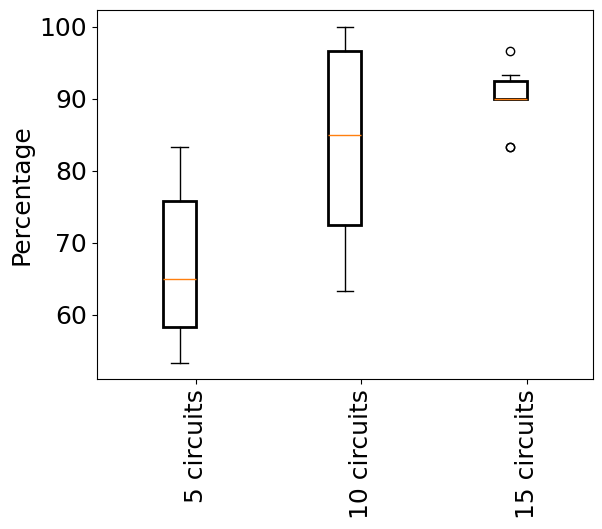

In [28]:
import matplotlib.pyplot as plt
import numpy as np
circuit_5 = np.array([17/30, 19/30, 20/30,17/30, 16/30,19/30,25/30,24/30,22/30, 23/30])
circuit_10 = np.array([24/30,29/30,29/30,30/30,30/30,19/30,20/30,26/30,25/30, 21/30])
circuit_15 = np.array([29/30,27/30,28/30,28/30,27/30,25/30,25/30,27/30,27/30,27/30])

circuits = []
circuits = [circuit_5, circuit_10, circuit_15]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

custom_labels = ['5 circuits','10 circuits','15 circuits']
positions = np.arange(1,4)
box_plot= plt.boxplot(circuits, widths=0.2, patch_artist=True, boxprops=dict(linewidth=2))
plt.setp(box_plot['means'], linewidth=2)

    # Customize box colors
#box_plot.set_facecolor('grey')
    # box_plot_noisy['boxes'][0].set_facecolor('grey')
for box in box_plot['boxes']:
    box.set_facecolor('white')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x * 100)))

# Set x-axis ticks and labels
plt.xticks(positions + 0.1, custom_labels,fontsize=18, rotation=90)
plt.yticks(fontsize=18)
#plt.xlabel('Circuits',fontsize=18)
plt.ylabel('Percentage',fontsize=18)
# plt.title('Percentage of backend predicted using circuit pools of varying sizes  ',fontsize=18) 

# Add legend
#plt.legend([box_plot_correct['boxes'][0], box_plot_noisy['boxes'][0]], ['Untouched', 'Infected'],loc='upper right', fontsize=20)

plt.show()



In [21]:
import pandas as pd

# Load the CSV file
file_path = r"C:\Users\rupsh\Downloads\ibm_sherbrooke_calibrations_2025-05-03T15_51_47Z.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Clean column names by stripping spaces
df.columns = df.columns.str.strip()

# Extract and rank ECR edges based on error rates
edge_errors = []

# Iterate through the "ECR error" column
for ecr_data in df["ECR error"].dropna():
    pairs = ecr_data.split(";")  # Split multiple entries
    for pair in pairs:
        qubits, error = pair.split(":")
        edge_errors.append((qubits, float(error)))

# Convert to DataFrame and sort by error rate
edge_errors_df = pd.DataFrame(edge_errors, columns=["Qubit Pair", "ECR Error"])
edge_errors_df = edge_errors_df.sort_values(by="ECR Error", ascending=True)
edge_errors_df["Rank"] = range(1, len(edge_errors_df) + 1)

pd.set_option("display.max_rows", None)  # Show all rows

# Display the ranked edges
print(edge_errors_df)



    Qubit Pair  ECR Error  Rank
54       47_46   0.002448     1
53       47_48   0.003168     2
12       11_12   0.003783     3
130    114_109   0.003908     4
94       82_83   0.004235     5
17       17_12   0.004309     6
13       12_13   0.004406     7
96       85_84   0.004543     8
132    116_115   0.004544     9
68       61_62   0.004633    10
11       10_11   0.004653    11
20       19_20   0.004796    12
46       41_53   0.004807    13
50       43_44   0.004848    14
95       83_84   0.005081    15
137    120_121   0.005087    16
129    113_114   0.005090    17
123     109_96   0.005214    18
69       63_62   0.005323    19
77       69_68   0.005327    20
72       64_65   0.005381    21
40       35_47   0.005421    22
70       63_64   0.005439    23
71       64_54   0.005440    24
73       66_65   0.005454    25
51       45_46   0.005512    26
106     93_106   0.005513    27
141    124_123   0.005548    28
44       40_39   0.005610    29
125    110_100   0.005734    30
85      

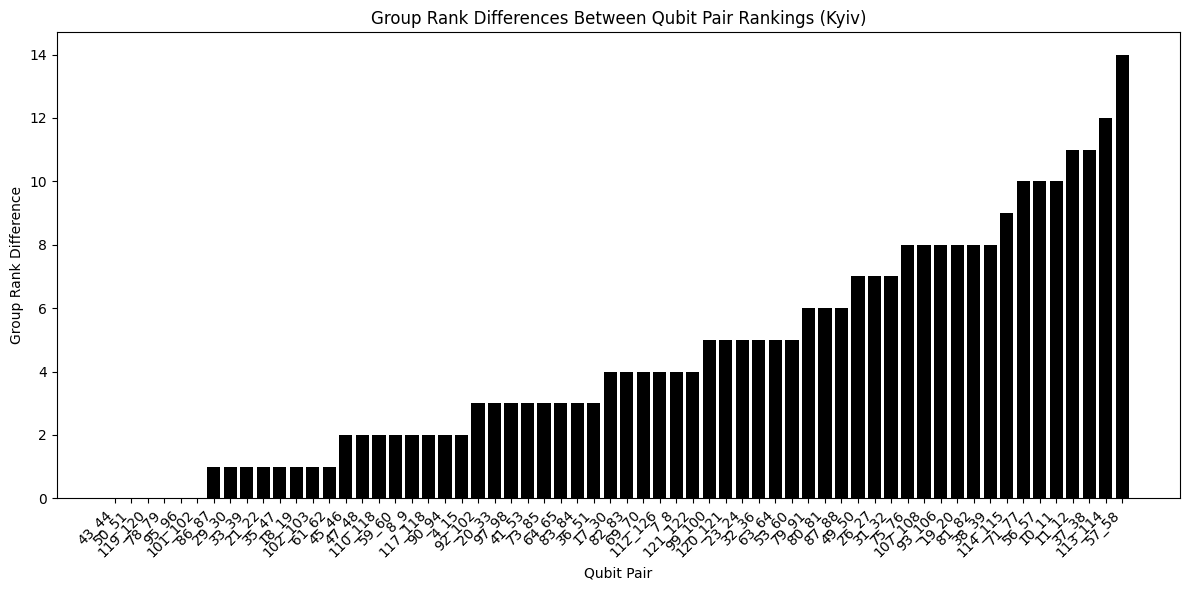

In [ ]:
import pandas as pd

# Load the CSV file
file_path = r"C:\Users\rupsh\Downloads\ibm_sherbrooke_calibrations_2025-05-03T15_51_47Z.csv"  # Replace with your actual file path
df_errors = pd.read_csv(file_path)

# Clean column names by stripping spaces
df_errors.columns = df_errors.columns.str.strip()
# Extract and rank ECR edges based on error rates
edge_errors = []

for ecr_data in df_errors["ECR error"].dropna():
    pairs = ecr_data.split(";")  # Split multiple entries
    for pair in pairs:
        qubits, error = pair.split(":")
        edge_errors.append((qubits.strip(), float(error)))

# Convert to DataFrame and sort by error rate
df_errors = pd.DataFrame(edge_errors, columns=["Qubit Pair", "ECR Error"])
df_errors = df_errors.sort_values(by="ECR Error", ascending=True).reset_index(drop=True)

# Assign group ranks: group of 10 edges per rank group
group_size = 10
df_errors["Group_Rank_ECR"] = (df_errors.index // group_size) + 1
# df_errors = df_errors.sort_values(by="ECR Error", ascending=True)
# df_errors["Rank_ECR"] = range(1, len(df_errors) + 1)
df_counts = df[["Qubit Pair", "Rank"]].rename(columns={"Rank": "Rank_Counts"}).copy()
df_counts = df_counts.sort_values(by="Rank_Counts").reset_index(drop=True)
df_counts["Group_Rank_Counts"] = (df_counts.index // group_size) + 1

# Merge on "Qubit Pair"
df_comparison = pd.merge(
    df_counts[["Qubit Pair", "Group_Rank_Counts"]],
    df_errors[["Qubit Pair", "Group_Rank_ECR"]],
    on="Qubit Pair",
    how="inner"
)

# Compute the absolute group rank difference
df_comparison["Rank Difference"] = abs(df_comparison["Group_Rank_Counts"] - df_comparison["Group_Rank_ECR"])

# Sort and plot
df_comparison_sorted = df_comparison.sort_values(by="Rank Difference", ascending=True)

plt.figure(figsize=(12, 6))
plt.bar(df_comparison_sorted["Qubit Pair"], df_comparison_sorted["Rank Difference"], color="black")
plt.xlabel("Qubit Pair")
plt.ylabel("Group Rank Difference")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Group Rank Differences Between Qubit Pair Rankings (Kyiv)")
plt.tight_layout()
plt.show()
